# Этап 2.


- сравнить графики сходимости со стадией 1;
- реализовать подстановку в исходной системе;
- учесть, что после подстановки максимальный порядок производной равен 2;
- добавить граничные условия для `v`;
- сравнить 3 варианта архитектуры:
  1. одна сеть с двумя выходами `[u, v]`;
  2. две отдельные сети;
  3. общие слои + раздельные головы.


In [1]:
import platform
print(platform.processor())

Intel64 Family 6 Model 141 Stepping 1, GenuineIntel


In [2]:
import json
import math
import re
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True


## 1. Общие настройки

In [3]:
PREFER_ACCELERATOR = True
DTYPE = 'float32'
TF_DTYPE = tf.dtypes.as_dtype(DTYPE)
AUTOTUNE = tf.data.AUTOTUNE


def detect_training_device():
    gpu_devices = tf.config.list_physical_devices('GPU')
    if gpu_devices:
        for device in gpu_devices:
            try:
                tf.config.experimental.set_memory_growth(device, True)
            except Exception:
                pass
        return '/GPU:0', 'GPU', gpu_devices

    xpu_devices = tf.config.list_physical_devices('XPU')
    if xpu_devices:
        return '/XPU:0', 'XPU', xpu_devices

    return '/CPU:0', 'CPU', tf.config.list_physical_devices('CPU')


TRAINING_DEVICE, DEVICE_KIND, AVAILABLE_DEVICES = detect_training_device()
tf.keras.backend.set_floatx(DTYPE)

try:
    tf.keras.mixed_precision.set_global_policy('float32')
except Exception:
    pass

SEED = 1234
tf.random.set_seed(SEED)
np.random.seed(SEED)

device_names = [device.name for device in AVAILABLE_DEVICES]
print('training device:', TRAINING_DEVICE)
print('device kind:', DEVICE_KIND)
print('visible devices:', device_names)
print('float type:', tf.keras.backend.floatx())
print('seed:', SEED)
if DEVICE_KIND == 'CPU':
    print('note: TensorFlow did not detect a GPU. For native Windows GPU support use TensorFlow 2.10.x; newer versions require WSL2.')


training device: /CPU:0
device kind: CPU
visible devices: ['/physical_device:CPU:0']
float type: float32
seed: 1234
note: TensorFlow did not detect a GPU. For native Windows GPU support use TensorFlow 2.10.x; newer versions require WSL2.


## 2. Параметры задачи

In [4]:
tmin, tmax = 0.0, 4.0
xmin, xmax = -30.0, 30.0

# Размеры выборок
N_0 = 300
N_r = 20000
N_b = 2000

# На RTX 3050 Ti 4 GB безопаснее начинать с 1024.
# Если при вычислении вторых производных всё ещё будет OOM, уменьшите до 512.
RESIDUAL_BATCH_SIZE = 1024

b = tf.constant(5.0, dtype=TF_DTYPE)
k = tf.constant(0.5 * np.sqrt(11.0 / 19.0), dtype=TF_DTYPE)
c = tf.constant((15.0 / 19.0) * np.sqrt(11.0 / 19.0), dtype=TF_DTYPE)
x0 = tf.constant(-12.0, dtype=TF_DTYPE)
us = tf.constant(10.0, dtype=TF_DTYPE)


NUM_HIDDEN_LAYERS = 4
NUM_SHARED_LAYERS = 4
HIDDEN_DIM = 64
NUM_FOURIER = 16
ACTIVATION = 'tanh'
LEARNING_RATE = 2e-4
NUM_STEPS = 13000
PRINT_EVERY = 100
PLOT_EVERY = 1000
PLOT_NUM_X = 256


lambda_r = tf.constant(1.0, dtype=TF_DTYPE)
lambda_b = tf.constant(1.0, dtype=TF_DTYPE)
lambda_0 = tf.constant(1.0, dtype=TF_DTYPE)

lb = tf.constant([tmin, xmin], dtype=TF_DTYPE)
ub = tf.constant([tmax, xmax], dtype=TF_DTYPE)

SHUFFLE_BUFFER_R = min(N_r, 8192)
RESIDUAL_STEPS_PER_EPOCH = int(math.ceil(N_r / RESIDUAL_BATCH_SIZE))

print('Residual batch size:', RESIDUAL_BATCH_SIZE)
print('Approx. residual batches per epoch:', RESIDUAL_STEPS_PER_EPOCH)


Residual batch size: 1024
Approx. residual batches per epoch: 20


## 3. Точное решение и подстановка


In [5]:
def u_exact(t, x):
    t = tf.cast(t, TF_DTYPE)
    x = tf.cast(x, TF_DTYPE)
    z = k * (x - b * t - x0)
    th = tf.tanh(z)
    return (b + c * (-9.0 * th + 11.0 * th**3)) / us


def v_exact(t, x):
    t = tf.cast(t, TF_DTYPE)
    x = tf.cast(x, TF_DTYPE)

    with tf.GradientTape(watch_accessed_variables=False) as outer_tape:
        outer_tape.watch(x)
        with tf.GradientTape(watch_accessed_variables=False) as inner_tape:
            inner_tape.watch(x)
            u = u_exact(t, x)
        u_x = inner_tape.gradient(u, x)

    v = outer_tape.gradient(u_x, x)
    return v


def u0(x):
    return u_exact(tf.zeros_like(x, dtype=TF_DTYPE), x)


def v0(x):
    return v_exact(tf.zeros_like(x, dtype=TF_DTYPE), x)


## 4. Генерация обучающих точек

In [6]:
t_0 = tf.zeros((N_0, 1), dtype=TF_DTYPE)
x_0 = tf.random.uniform((N_0, 1), lb[1], ub[1], dtype=TF_DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)

u_0 = u0(x_0)
v_0 = v0(x_0)

t_r = tf.random.uniform((N_r, 1), lb[0] + tf.constant(1e-6, dtype=TF_DTYPE), ub[0], dtype=TF_DTYPE)
x_r = tf.random.uniform((N_r, 1), lb[1], ub[1], dtype=TF_DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)

t_b = tf.random.uniform((N_b, 1), lb[0], ub[0], dtype=TF_DTYPE)
x_lb = tf.ones((N_b, 1), dtype=TF_DTYPE) * lb[1]
x_ub = tf.ones((N_b, 1), dtype=TF_DTYPE) * ub[1]
X_lb = tf.concat([t_b, x_lb], axis=1)
X_ub = tf.concat([t_b, x_ub], axis=1)

u_lb = u_exact(t_b, x_lb)
u_ub = u_exact(t_b, x_ub)
v_lb = v_exact(t_b, x_lb)
v_ub = v_exact(t_b, x_ub)

print('X_0:', X_0.shape, 'u_0:', u_0.shape, 'v_0:', v_0.shape)
print('X_r:', X_r.shape)
print('X_lb:', X_lb.shape, 'X_ub:', X_ub.shape)
print('u_lb:', u_lb.shape, 'u_ub:', u_ub.shape)


X_0: (300, 2) u_0: (300, 1) v_0: (300, 1)
X_r: (20000, 2)
X_lb: (2000, 2) X_ub: (2000, 2)
u_lb: (2000, 1) u_ub: (2000, 1)


## 5. Вспомогательные функции

Эти функции общие 

Фурие

In [7]:
try:
    from tf_fourier_features import FourierFeatureProjection as ExternalFourierFeatureProjection
    FOURIER_BACKEND = "tf_fourier_features"
except Exception as exc:
    ExternalFourierFeatureProjection = None
    FOURIER_BACKEND = "fallback"
    print("tf_fourier_features is not available.")
    print("Install with: pip install tf-fourier-features")
    print(f"Using fallback Fourier features. Import error: {exc}")


class FallbackFourierFeatureProjection(tf.keras.layers.Layer):
    def __init__(self, gaussian_projection=16, gaussian_scale=1.0, seed=42, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.gaussian_projection = int(gaussian_projection)
        self.gaussian_scale = float(gaussian_scale)
        self.seed = int(seed)
        self.trainable_projection = bool(trainable)

    def build(self, input_shape):
        self.B = self.add_weight(
            name="B",
            shape=(1, self.gaussian_projection),
            initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=self.gaussian_scale,
                seed=self.seed,
            ),
            trainable=self.trainable_projection,
            dtype=self.dtype,
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, self.compute_dtype)
        projection = 2.0 * math.pi * tf.matmul(x, self.B)
        return tf.concat([tf.sin(projection), tf.cos(projection)], axis=-1)

tf_fourier_features is not available.
Install with: pip install tf-fourier-features
Using fallback Fourier features. Import error: No module named 'tf_fourier_features'


In [8]:
def stack_tx(t, x):
    t = tf.cast(t, TF_DTYPE)
    x = tf.cast(x, TF_DTYPE)
    return tf.concat([t, x], axis=1)


def split_tx(X):
    X = tf.cast(X, TF_DTYPE)
    return X[:, 0:1], X[:, 1:2]


def split_uv(y):
    u = y[:, 0:1]
    v = y[:, 1:2]
    return u, v


def mse(x):
    x = tf.cast(x, TF_DTYPE)
    return tf.reduce_mean(tf.square(x))


def make_hidden_layers(num_hidden_layers=4, hidden_dim=64, activation='tanh'):
    return [
        tf.keras.layers.Dense(hidden_dim, activation=activation, dtype=DTYPE)
        for _ in range(num_hidden_layers)
    ]


def make_fourier_projection(gaussian_projection, gaussian_scale, seed):
    if ExternalFourierFeatureProjection is not None:
        return ExternalFourierFeatureProjection(
            gaussian_projection=gaussian_projection,
            gaussian_scale=gaussian_scale,
        )
    return FallbackFourierFeatureProjection(
        gaussian_projection=gaussian_projection,
        gaussian_scale=gaussian_scale,
        seed=seed,
    )


def make_residual_dataset(X_r, batch_size=RESIDUAL_BATCH_SIZE, seed=SEED):
    X_r = tf.cast(X_r, TF_DTYPE)
    shuffle_buffer = min(int(X_r.shape[0]), SHUFFLE_BUFFER_R)

    dataset = tf.data.Dataset.from_tensor_slices(X_r)
    if shuffle_buffer > 1:
        dataset = dataset.shuffle(shuffle_buffer, seed=seed, reshuffle_each_iteration=True)

    dataset = dataset.batch(batch_size, drop_remainder=False)
    return dataset.prefetch(AUTOTUNE).repeat()


## 6. Вариант 1: одна сеть с двумя выходами

In [9]:
class TwoOutputPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )
        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)
        self.output_layer = tf.keras.layers.Dense(2, activation='linear', dtype=DTYPE)

    def call(self, inputs, training=False):
        inputs = tf.cast(inputs, TF_DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), TF_DTYPE)
        x_features = tf.cast(self.x_proj(x), TF_DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        h = features
        for layer in self.hidden_layers:
            h = layer(h)
        return self.output_layer(h)


## 7. Вариант 2: две отдельные сети

In [10]:
class SingleOutputPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, activation='tanh', name='single_output_pinn'):
        super().__init__(name=name)

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)
        self.output_layer = tf.keras.layers.Dense(1, activation='linear', dtype=DTYPE)

    def call(self, inputs, training=False):
        inputs = tf.cast(inputs, TF_DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), TF_DTYPE)
        x_features = tf.cast(self.x_proj(x), TF_DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        h = features
        for layer in self.hidden_layers:
            h = layer(h)
        return self.output_layer(h)


## 8. Вариант 3: общая trunk-часть и две головы

In [11]:
class SharedTrunkPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=34, num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)
        self.u_hidden = tf.keras.layers.Dense(hidden_dim, activation=activation, dtype=DTYPE)
        self.u_output = tf.keras.layers.Dense(1, activation='linear', dtype=DTYPE)
        self.v_hidden = tf.keras.layers.Dense(hidden_dim, activation=activation, dtype=DTYPE)
        self.v_output = tf.keras.layers.Dense(1, activation='linear', dtype=DTYPE)

    def call(self, inputs, training=False):
        inputs = tf.cast(inputs, TF_DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), TF_DTYPE)
        x_features = tf.cast(self.x_proj(x), TF_DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        h = features
        for layer in self.hidden_layers:
            h = layer(h)

        h_u = self.u_hidden(h)
        u = self.u_output(h_u)

        h_v = self.v_hidden(h)
        v = self.v_output(h_v)

        return tf.concat([u, v], axis=1)


## 9. Автодифференцирование до второго порядка

После подстановки у вас система второго порядка, поэтому обычно достаточно `u_t`, `u_x`, `u_xx`, `v_t`, `v_x`, `v_xx`.

In [12]:
def _forward_u_v(model_like, variant_name, t, x, training=False):
    X = stack_tx(t, x)
    if variant_name == 'two_models':
        u = model_like['u'](X, training=training)
        v = model_like['v'](X, training=training)
    else:
        y = model_like(X, training=training)
        u, v = split_uv(y)
    return u, v


def compute_fields(model_like, variant_name, X, training=False):
    t, x = split_tx(X)

    with tf.GradientTape(persistent=True, watch_accessed_variables=False) as second_tape:
        second_tape.watch((t, x))
        with tf.GradientTape(persistent=True, watch_accessed_variables=False) as first_tape:
            first_tape.watch((t, x))
            u, v = _forward_u_v(model_like, variant_name, t, x, training=training)

        u_t = first_tape.gradient(u, t)
        u_x = first_tape.gradient(u, x)
        v_t = first_tape.gradient(v, t)
        v_x = first_tape.gradient(v, x)

    u_xx = second_tape.gradient(u_x, x)
    v_xx = second_tape.gradient(v_x, x)

    del first_tape
    del second_tape

    return {
        't': t,
        'x': x,
        'u': u,
        'v': v,
        'u_t': u_t,
        'u_x': u_x,
        'u_xx': u_xx,
        'v_t': v_t,
        'v_x': v_x,
        'v_xx': v_xx,
    }


def derivatives_two_output_model(model, X, training=False):
    return compute_fields(model, 'two_output', X, training=training)


def derivatives_two_models(model_u, model_v, X, training=False):
    model_like = {'u': model_u, 'v': model_v}
    return compute_fields(model_like, 'two_models', X, training=training)


## 10. Невязки системы после подстановки

Это главный блок, который вам нужно заполнить по вашей постановке.

Подсказка: удобно вернуть словарь с невязками, например `{'r_u': ..., 'r_v': ...}`.

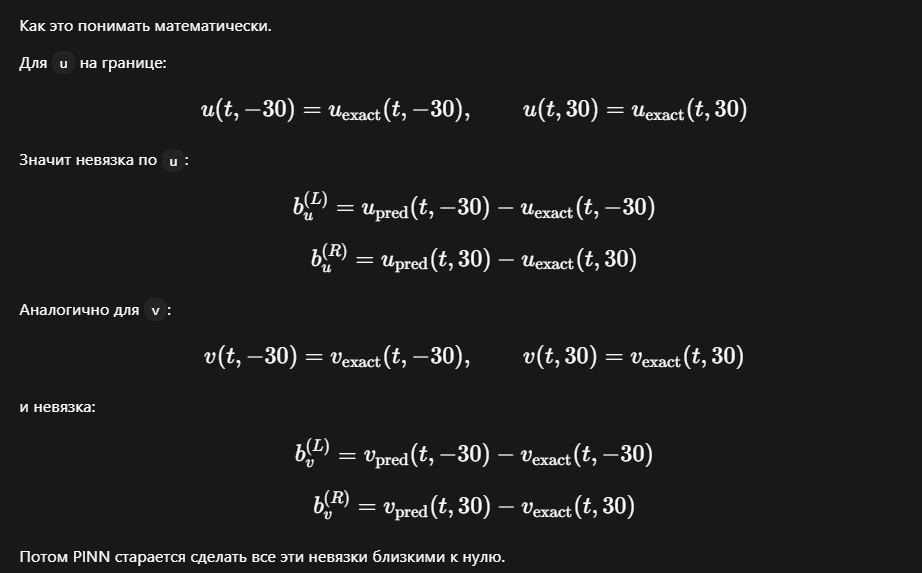

In [13]:
def residuals_from_fields(fields):
    """
    fields keys:
    u, v, u_t, u_x, u_xx, v_t, v_x, v_xx
    """

    r_u = fields['u_t'] + us * fields['u'] * fields['u_x'] + fields['v'] + fields['v_xx']
    r_v = fields['v'] - fields['u_xx']

    return {
        'r_u': r_u,
        'r_v': r_v,
    }


def predict_uv(model_like, variant_name, X, training=False):
    t, x = split_tx(X)
    return _forward_u_v(model_like, variant_name, t, x, training=training)


def build_plot_grid(plot_times=None, num_x=PLOT_NUM_X):
    if plot_times is None:
        plot_times = [tmin, 0.5 * (tmin + tmax), tmax]

    x_plot = tf.reshape(
        tf.linspace(tf.cast(xmin, TF_DTYPE), tf.cast(xmax, TF_DTYPE), num_x),
        (-1, 1),
    )
    x_np = x_plot.numpy().squeeze()

    return [float(t) for t in plot_times], x_plot, x_np


def make_snapshot_metrics(metrics):
    if metrics is None:
        return None

    return {
        'total': float(metrics['total']),
        'phi_r': float(metrics['phi_r']),
        'phi_b': float(metrics['phi_b']),
        'phi_0': float(metrics['phi_0']),
    }


def format_snapshot_metrics(metrics):
    if metrics is None:
        return None

    return (
        f"total={metrics['total']:.2e}, "
        f"phi_r={metrics['phi_r']:.2e}, "
        f"phi_b={metrics['phi_b']:.2e}, "
        f"phi_0={metrics['phi_0']:.2e}"
    )


def collect_training_snapshot(model_like, variant_name, step, plot_times=None, num_x=PLOT_NUM_X, metrics=None):
    plot_times, x_plot, x_np = build_plot_grid(plot_times=plot_times, num_x=num_x)
    snapshot = {
        'step': int(step),
        'plot_times': plot_times,
        'x': x_np,
        'u_pred': [],
        'v_pred': [],
        'u_true': [],
        'v_true': [],
        'metrics': make_snapshot_metrics(metrics),
    }

    for t_scalar in plot_times:
        t_plot = tf.fill((num_x, 1), tf.cast(t_scalar, TF_DTYPE))
        X_plot = stack_tx(t_plot, x_plot)

        u_pred, v_pred = predict_uv(model_like, variant_name, X_plot, training=False)
        u_true = u_exact(t_plot, x_plot)
        v_true = v_exact(t_plot, x_plot)

        snapshot['u_pred'].append(u_pred.numpy().squeeze())
        snapshot['v_pred'].append(v_pred.numpy().squeeze())
        snapshot['u_true'].append(u_true.numpy().squeeze())
        snapshot['v_true'].append(v_true.numpy().squeeze())

    return snapshot


def plot_training_snapshot(model_like=None, variant_name=None, step=None, plot_times=None, num_x=PLOT_NUM_X, metrics=None, snapshot=None):
    if snapshot is None:
        if model_like is None or variant_name is None or step is None:
            raise ValueError('model_like, variant_name and step are required when snapshot is not provided.')

        snapshot = collect_training_snapshot(
            model_like,
            variant_name,
            step,
            plot_times=plot_times,
            num_x=num_x,
            metrics=metrics,
        )
    elif variant_name is None:
        raise ValueError('variant_name is required.')

    x_np = np.asarray(snapshot['x'])
    plot_times = snapshot['plot_times']
    fig, axes = plt.subplots(2, len(plot_times), figsize=(5 * len(plot_times), 7), sharex=True, squeeze=False)

    title = f"{variant_name}: approximation at step {snapshot['step']}"
    metrics_text = format_snapshot_metrics(snapshot.get('metrics'))
    if metrics_text is not None:
        title = title + "\n" + metrics_text
    fig.suptitle(title, fontsize=14)

    for col, t_scalar in enumerate(plot_times):
        u_true_np = np.asarray(snapshot['u_true'][col])
        v_true_np = np.asarray(snapshot['v_true'][col])
        u_pred_np = np.asarray(snapshot['u_pred'][col])
        v_pred_np = np.asarray(snapshot['v_pred'][col])

        axes[0, col].plot(x_np, u_true_np, label='exact', lw=2)
        axes[0, col].plot(x_np, u_pred_np, '--', label='pred', lw=2)
        axes[0, col].set_title(f't = {t_scalar:.2f}')
        axes[0, col].set_ylabel('u(t, x)')
        axes[0, col].grid(True, alpha=0.3)

        axes[1, col].plot(x_np, v_true_np, label='exact', lw=2)
        axes[1, col].plot(x_np, v_pred_np, '--', label='pred', lw=2)
        axes[1, col].set_title(f't = {t_scalar:.2f}')
        axes[1, col].set_xlabel('x')
        axes[1, col].set_ylabel('v(t, x)')
        axes[1, col].grid(True, alpha=0.3)

    axes[0, 0].legend()
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

    return snapshot


def select_snapshots_for_plot(snapshots, max_snapshots=None):
    if not snapshots:
        return []

    snapshots = [snapshot for snapshot in snapshots if snapshot['step'] != 0]
    if not snapshots:
        raise ValueError('history contains only the initialization snapshot.')

    if max_snapshots is None or len(snapshots) <= max_snapshots:
        return list(snapshots)

    idx = np.linspace(0, len(snapshots) - 1, max_snapshots)
    idx = np.unique(np.round(idx).astype(int))
    return [snapshots[i] for i in idx]


def plot_approximation_evolution(history, variant_name, max_snapshots=None):
    snapshots = history.get('snapshots', [])
    if not snapshots:
        raise ValueError('history does not contain snapshots. Run training with plot_every > 0.')

    snapshots_to_plot = select_snapshots_for_plot(snapshots, max_snapshots=max_snapshots)
    reference_snapshot = snapshots_to_plot[-1]
    x_np = np.asarray(reference_snapshot['x'])
    plot_times = reference_snapshot['plot_times']

    fig, axes = plt.subplots(2, len(plot_times), figsize=(5 * len(plot_times), 7), sharex=True, squeeze=False)
    fig.suptitle(f'{variant_name}: approximation evolution during training', fontsize=14)

    for row, field_name in enumerate(('u', 'v')):
        exact_key = f'{field_name}_true'
        pred_key = f'{field_name}_pred'

        for col, t_scalar in enumerate(plot_times):
            ax = axes[row, col]
            ax.plot(x_np, np.asarray(reference_snapshot[exact_key][col]), color='black', lw=2.5, label='exact')

            for snapshot in snapshots_to_plot:
                ax.plot(
                    x_np,
                    np.asarray(snapshot[pred_key][col]),
                    lw=1.4,
                    alpha=0.85,
                    label=f"step {snapshot['step']}",
                )

            ax.set_title(f't = {t_scalar:.2f}')
            ax.grid(True, alpha=0.3)
            if row == 1:
                ax.set_xlabel('x')
            if col == 0:
                ax.set_ylabel(f'{field_name}(t, x)')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=min(len(labels), 4), bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=(0, 0.08, 1, 0.93))
    plt.show()


## 11. Функция потерь для каждого варианта

In [14]:
def select_fields(model_like, variant_name, X, training=False):
    if variant_name == 'two_models':
        return derivatives_two_models(model_like['u'], model_like['v'], X, training=training)
    if variant_name in ('two_output', 'shared_trunk'):
        return derivatives_two_output_model(model_like, X, training=training)
    raise ValueError(f'Unknown variant_name: {variant_name}')


def initial_condition_loss(model_like, variant_name, X_0, u_0, v_0, training=False):
    u_pred, v_pred = predict_uv(model_like, variant_name, X_0, training=training)
    phi_0_u = mse(u_pred - u_0)
    phi_0_v = mse(v_pred - v_0)
    return {
        'phi_0_u': phi_0_u,
        'phi_0_v': phi_0_v,
        'phi_0': phi_0_u + phi_0_v,
    }


def boundary_condition_loss(model_like, variant_name, X_lb, u_lb, v_lb, X_ub, u_ub, v_ub, training=False):
    u_lb_pred, v_lb_pred = predict_uv(model_like, variant_name, X_lb, training=training)
    u_ub_pred, v_ub_pred = predict_uv(model_like, variant_name, X_ub, training=training)

    phi_b_u = 0.5 * (mse(u_lb_pred - u_lb) + mse(u_ub_pred - u_ub))
    phi_b_v = 0.5 * (mse(v_lb_pred - v_lb) + mse(v_ub_pred - v_ub))
    return {
        'phi_b_u': phi_b_u,
        'phi_b_v': phi_b_v,
        'phi_b': phi_b_u + phi_b_v,
    }


def compute_total_loss(model_like, variant_name, X_r, X_0, u_0, v_0, X_lb, u_lb, v_lb, X_ub, u_ub, v_ub, training=False):
    fields_r = select_fields(model_like, variant_name, X_r, training=training)
    residuals = residuals_from_fields(fields_r)
    bc = boundary_condition_loss(model_like, variant_name, X_lb, u_lb, v_lb, X_ub, u_ub, v_ub, training=training)
    ic = initial_condition_loss(model_like, variant_name, X_0, u_0, v_0, training=training)

    phi_r = tf.add_n([mse(val) for val in residuals.values()])
    phi_b = bc['phi_b']
    phi_0 = ic['phi_0']

    total_loss = lambda_r * phi_r + lambda_b * phi_b + lambda_0 * phi_0

    metrics = {
        'total': total_loss,
        'phi_r': phi_r,
        'phi_b': phi_b,
        'phi_0': phi_0,
        'phi_b_u': bc['phi_b_u'],
        'phi_b_v': bc['phi_b_v'],
        'phi_0_u': ic['phi_0_u'],
        'phi_0_v': ic['phi_0_v'],
    }
    return total_loss, metrics


## 12. Шаг обучения и цикл тренировки

In [15]:
def trainable_variables_for_variant(model_like, variant_name):
    if variant_name == 'two_models':
        return model_like['u'].trainable_variables + model_like['v'].trainable_variables
    return model_like.trainable_variables


def build_variant_for_training(model_like, optimizer, variant_name):
    dummy_X = tf.zeros((1, 2), dtype=TF_DTYPE)

    if variant_name == 'two_models':
        model_like['u'](dummy_X, training=False)
        model_like['v'](dummy_X, training=False)
    else:
        model_like(dummy_X, training=False)

    variables = list(trainable_variables_for_variant(model_like, variant_name))
    if hasattr(optimizer, 'build'):
        optimizer.build(variables)
    return variables


def make_train_step(model_like, optimizer, variant_name, X_0, u_0, v_0, X_lb, u_lb, v_lb, X_ub, u_ub, v_ub):
    variables = tuple(build_variant_for_training(model_like, optimizer, variant_name))

    X_0 = tf.cast(X_0, TF_DTYPE)
    u_0 = tf.cast(u_0, TF_DTYPE)
    v_0 = tf.cast(v_0, TF_DTYPE)
    X_lb = tf.cast(X_lb, TF_DTYPE)
    u_lb = tf.cast(u_lb, TF_DTYPE)
    v_lb = tf.cast(v_lb, TF_DTYPE)
    X_ub = tf.cast(X_ub, TF_DTYPE)
    u_ub = tf.cast(u_ub, TF_DTYPE)
    v_ub = tf.cast(v_ub, TF_DTYPE)

    @tf.function(reduce_retracing=True)
    def train_step_fn(X_r_batch):
        X_r_batch = tf.cast(X_r_batch, TF_DTYPE)

        with tf.device(TRAINING_DEVICE):
            with tf.GradientTape() as tape:
                total_loss, metrics = compute_total_loss(
                    model_like,
                    variant_name,
                    X_r_batch,
                    X_0,
                    u_0,
                    v_0,
                    X_lb,
                    u_lb,
                    v_lb,
                    X_ub,
                    u_ub,
                    v_ub,
                    training=True,
                )

            grads = tape.gradient(total_loss, variables)
            grads_and_vars = [(grad, var) for grad, var in zip(grads, variables) if grad is not None]
            if grads_and_vars:
                optimizer.apply_gradients(grads_and_vars)
        return metrics

    return train_step_fn


def run_training(model_like, optimizer, variant_name, X_r, X_0, u_0, v_0, X_lb, u_lb, v_lb, X_ub, u_ub, v_ub, num_steps=NUM_STEPS, residual_batch_size=RESIDUAL_BATCH_SIZE, print_every=PRINT_EVERY, plot_every=PLOT_EVERY, plot_times=None, plot_num_x=PLOT_NUM_X):
    residual_batches_per_epoch = int(math.ceil(int(X_r.shape[0]) / residual_batch_size))
    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
        'snapshots': [],
        'residual_batch_size': int(residual_batch_size),
        'residual_batches_per_epoch': residual_batches_per_epoch,
    }

    print(f'[{variant_name}] training device: {TRAINING_DEVICE}')
    print(f'[{variant_name}] residual batch size: {residual_batch_size}, batches/epoch ~= {residual_batches_per_epoch}')

    train_step_fn = make_train_step(model_like, optimizer, variant_name, X_0, u_0, v_0, X_lb, u_lb, v_lb, X_ub, u_ub, v_ub)
    residual_iter = iter(make_residual_dataset(X_r, batch_size=residual_batch_size))

    t0 = time()
    for step in range(num_steps + 1):
        X_r_batch = next(residual_iter)
        metrics = train_step_fn(X_r_batch)

        history['step'].append(step)
        history['total'].append(float(metrics['total']))
        history['phi_r'].append(float(metrics['phi_r']))
        history['phi_b'].append(float(metrics['phi_b']))
        history['phi_0'].append(float(metrics['phi_0']))

        if step % print_every == 0:
            approx_epoch = (step + 1) / max(1, residual_batches_per_epoch)
            print(
                f"[{variant_name}] step={step:05d} "
                f"total={float(metrics['total']):.6e} "
                f"(~{approx_epoch:.1f} residual epochs)"
            )

        if plot_every and step % plot_every == 0:
            snapshot = collect_training_snapshot(
                model_like,
                variant_name,
                step,
                plot_times=plot_times,
                num_x=plot_num_x,
                metrics=metrics,
            )
            history['snapshots'].append(snapshot)
            plot_training_snapshot(variant_name=variant_name, snapshot=snapshot)

    print(f'[{variant_name}] elapsed: {time() - t0:.2f} sec')
    return history


## 13. Инициализация трех подходов

In [16]:
with tf.device(TRAINING_DEVICE):
    two_output_model = TwoOutputPINN(
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
    )
    two_output_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    two_models = {
        'u': SingleOutputPINN(
            num_hidden_layers=NUM_HIDDEN_LAYERS,
            hidden_dim=HIDDEN_DIM,
            num_fourier=NUM_FOURIER,
            activation=ACTIVATION,
            name='model_u',
        ),
        'v': SingleOutputPINN(
            num_hidden_layers=NUM_HIDDEN_LAYERS,
            hidden_dim=HIDDEN_DIM,
            num_fourier=NUM_FOURIER,
            activation=ACTIVATION,
            name='model_v',
        ),
    }
    two_models_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    shared_trunk_model = SharedTrunkPINN(
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
    )
    shared_trunk_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)


## 14. Запуск экспериментов



[two_output] training device: /CPU:0
[two_output] residual batch size: 1024, batches/epoch ~= 20
[two_output] step=00000 total=3.217431e+00 (~0.1 residual epochs)


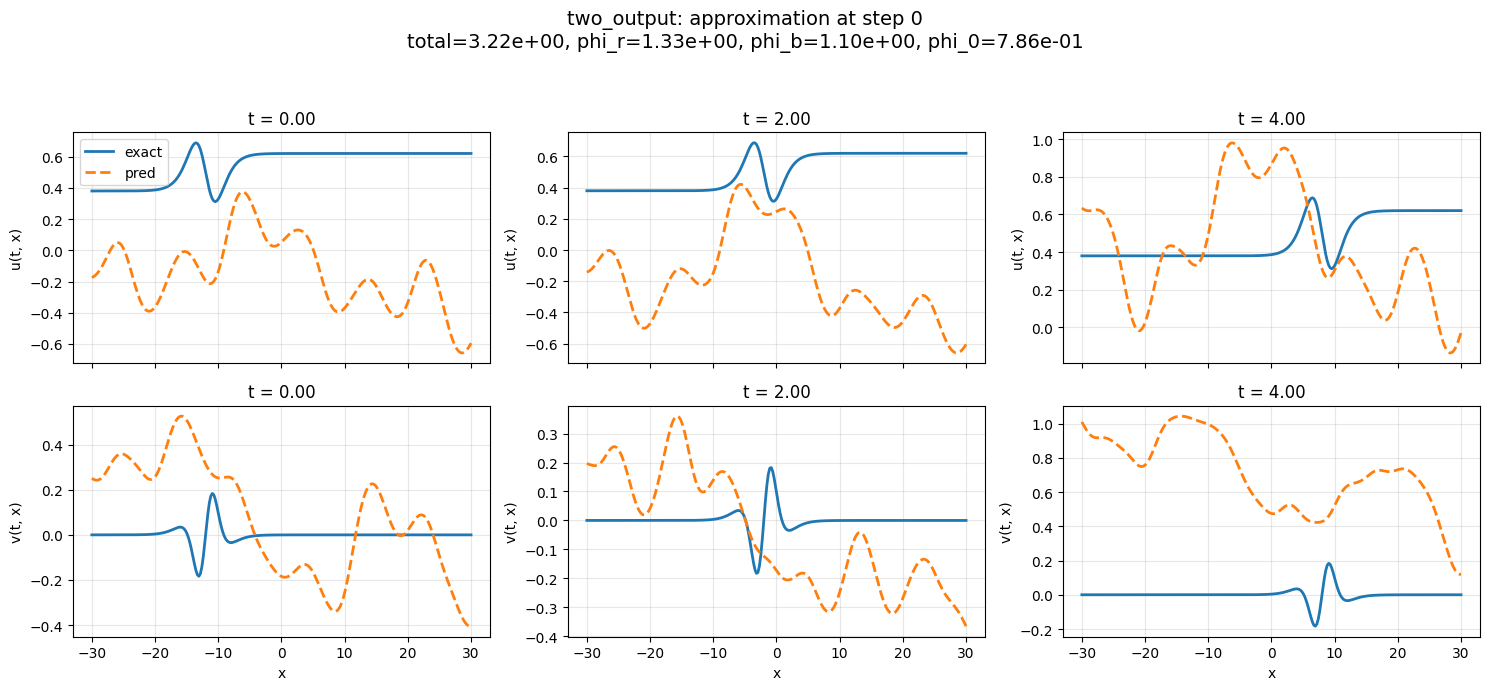

[two_output] step=00100 total=2.927618e-02 (~5.0 residual epochs)
[two_output] step=00200 total=1.479810e-02 (~10.1 residual epochs)
[two_output] step=00300 total=1.064098e-02 (~15.1 residual epochs)
[two_output] step=00400 total=8.266088e-03 (~20.1 residual epochs)
[two_output] step=00500 total=7.079350e-03 (~25.1 residual epochs)
[two_output] step=00600 total=5.950848e-03 (~30.1 residual epochs)
[two_output] step=00700 total=5.484652e-03 (~35.0 residual epochs)
[two_output] step=00800 total=4.861844e-03 (~40.0 residual epochs)
[two_output] step=00900 total=4.411129e-03 (~45.0 residual epochs)
[two_output] step=01000 total=4.185296e-03 (~50.0 residual epochs)


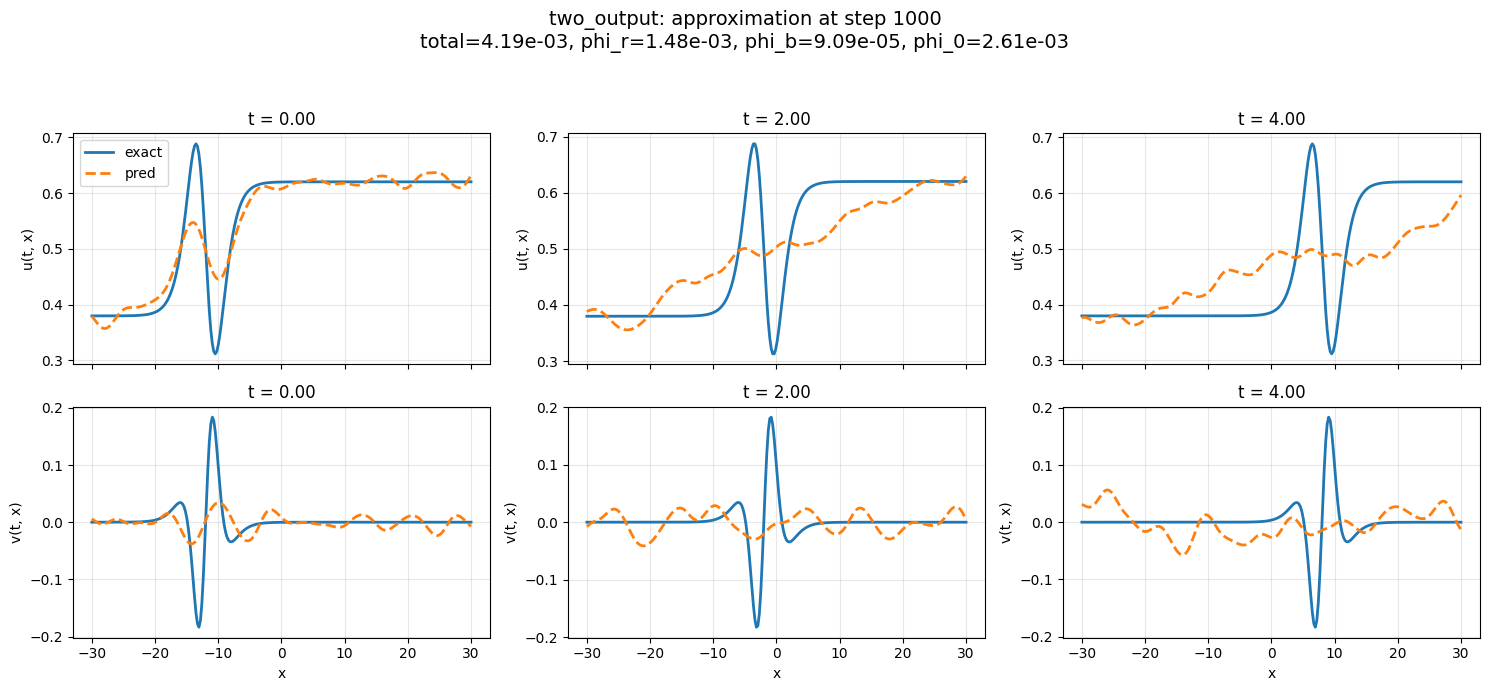

[two_output] step=01100 total=3.906954e-03 (~55.0 residual epochs)
[two_output] step=01200 total=3.658488e-03 (~60.0 residual epochs)
[two_output] step=01300 total=3.446094e-03 (~65.0 residual epochs)
[two_output] step=01400 total=3.322748e-03 (~70.0 residual epochs)
[two_output] step=01500 total=3.229811e-03 (~75.0 residual epochs)
[two_output] step=01600 total=2.993094e-03 (~80.0 residual epochs)
[two_output] step=01700 total=2.953892e-03 (~85.0 residual epochs)
[two_output] step=01800 total=2.766087e-03 (~90.0 residual epochs)
[two_output] step=01900 total=2.622234e-03 (~95.0 residual epochs)
[two_output] step=02000 total=2.596530e-03 (~100.0 residual epochs)


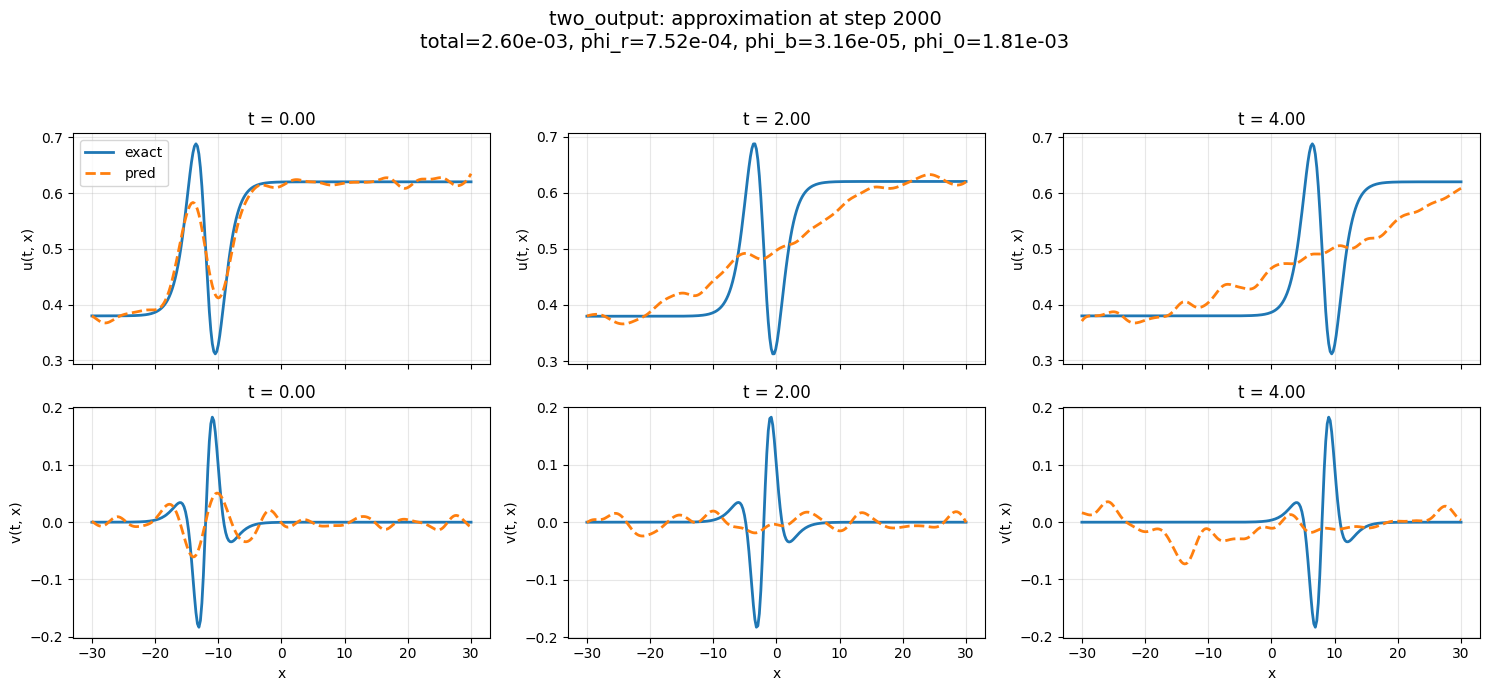

[two_output] step=02100 total=2.440652e-03 (~105.0 residual epochs)
[two_output] step=02200 total=2.321748e-03 (~110.0 residual epochs)
[two_output] step=02300 total=2.220071e-03 (~115.0 residual epochs)
[two_output] step=02400 total=2.143697e-03 (~120.0 residual epochs)
[two_output] step=02500 total=2.164660e-03 (~125.0 residual epochs)
[two_output] step=02600 total=1.973901e-03 (~130.1 residual epochs)
[two_output] step=02700 total=1.853800e-03 (~135.1 residual epochs)
[two_output] step=02800 total=1.901565e-03 (~140.1 residual epochs)
[two_output] step=02900 total=1.716285e-03 (~145.1 residual epochs)
[two_output] step=03000 total=1.671354e-03 (~150.1 residual epochs)


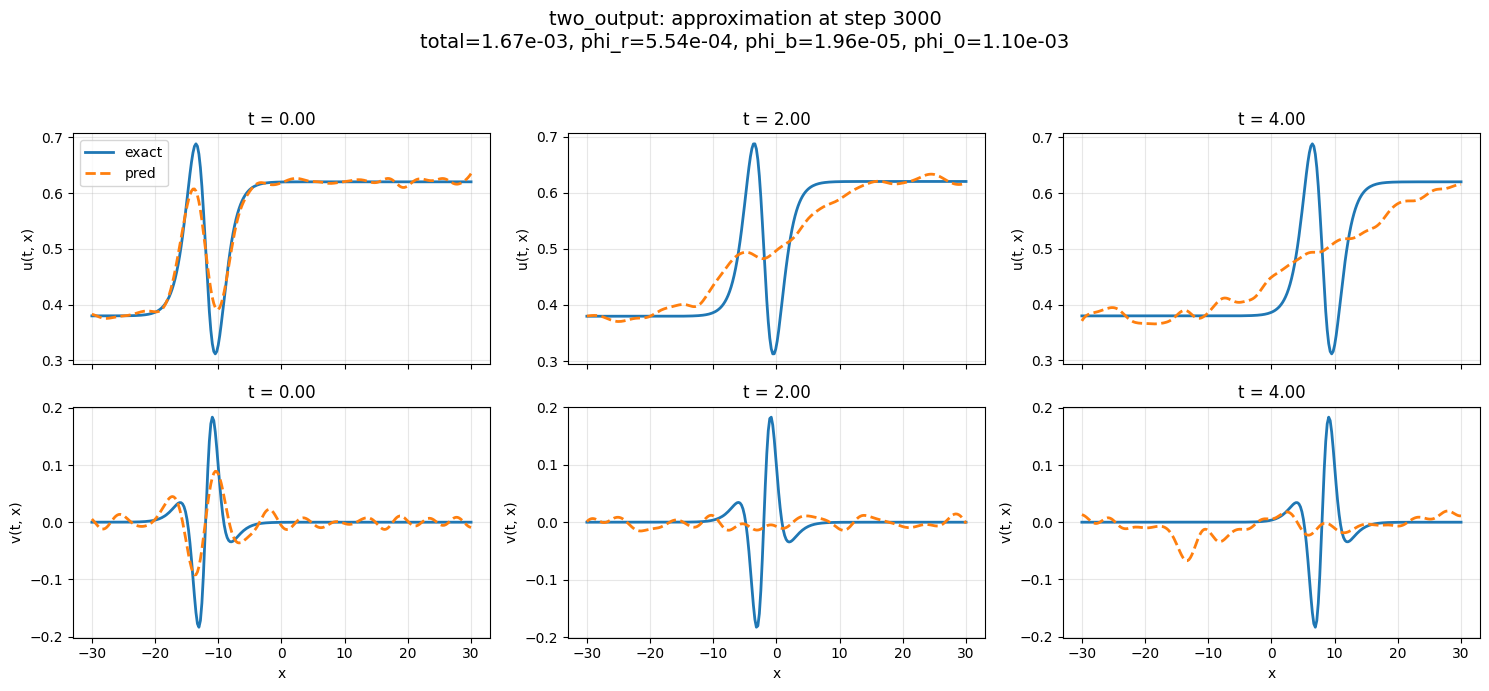

[two_output] step=03100 total=1.545335e-03 (~155.1 residual epochs)
[two_output] step=03200 total=1.522114e-03 (~160.1 residual epochs)
[two_output] step=03300 total=1.351655e-03 (~165.1 residual epochs)
[two_output] step=03400 total=1.366576e-03 (~170.1 residual epochs)
[two_output] step=03500 total=1.320834e-03 (~175.1 residual epochs)
[two_output] step=03600 total=1.243239e-03 (~180.1 residual epochs)
[two_output] step=03700 total=1.092681e-03 (~185.1 residual epochs)
[two_output] step=03800 total=1.122049e-03 (~190.1 residual epochs)
[two_output] step=03900 total=1.019713e-03 (~195.1 residual epochs)
[two_output] step=04000 total=9.531060e-04 (~200.1 residual epochs)


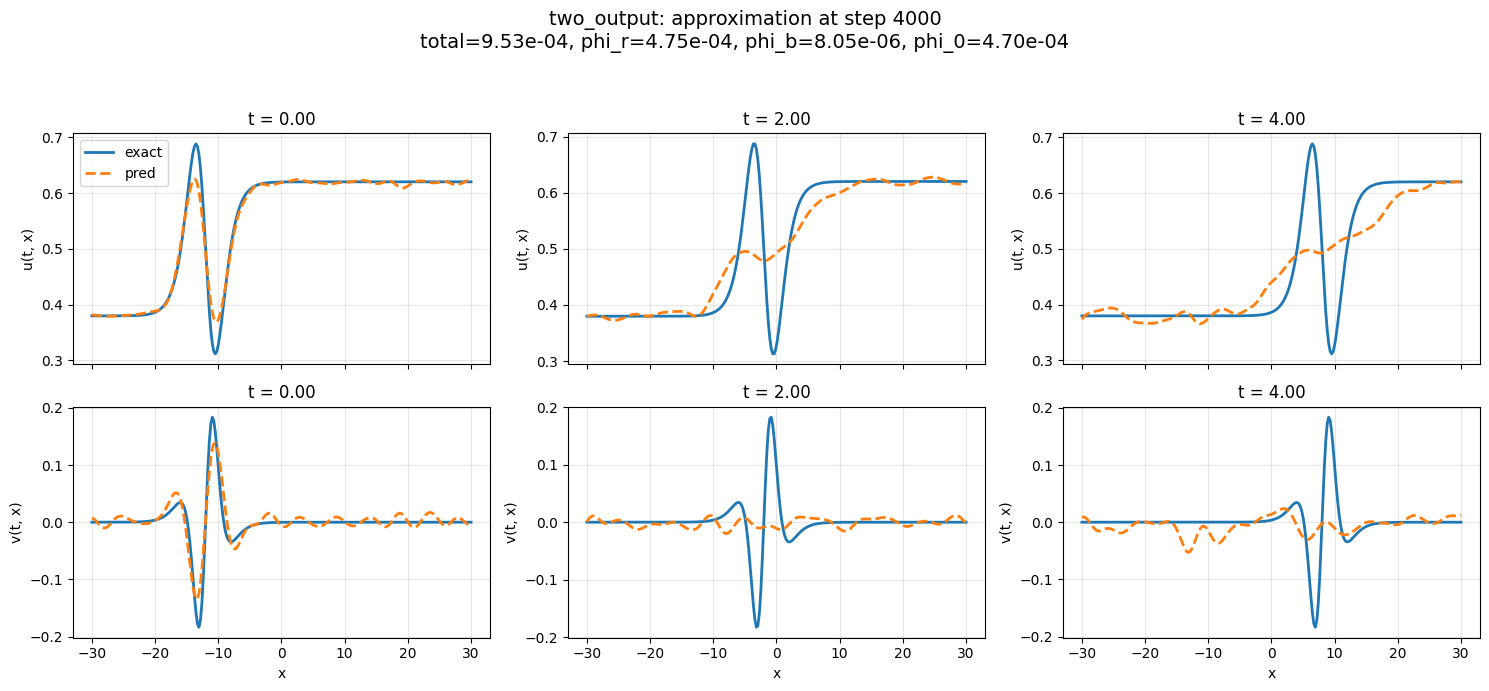

[two_output] step=04100 total=9.187178e-04 (~205.1 residual epochs)
[two_output] step=04200 total=9.568611e-04 (~210.1 residual epochs)
[two_output] step=04300 total=8.223386e-04 (~215.1 residual epochs)
[two_output] step=04400 total=8.890112e-04 (~220.1 residual epochs)
[two_output] step=04500 total=7.935902e-04 (~225.1 residual epochs)
[two_output] step=04600 total=7.627322e-04 (~230.1 residual epochs)
[two_output] step=04700 total=6.830692e-04 (~235.1 residual epochs)
[two_output] step=04800 total=6.251518e-04 (~240.1 residual epochs)
[two_output] step=04900 total=6.750916e-04 (~245.1 residual epochs)
[two_output] step=05000 total=6.545195e-04 (~250.1 residual epochs)


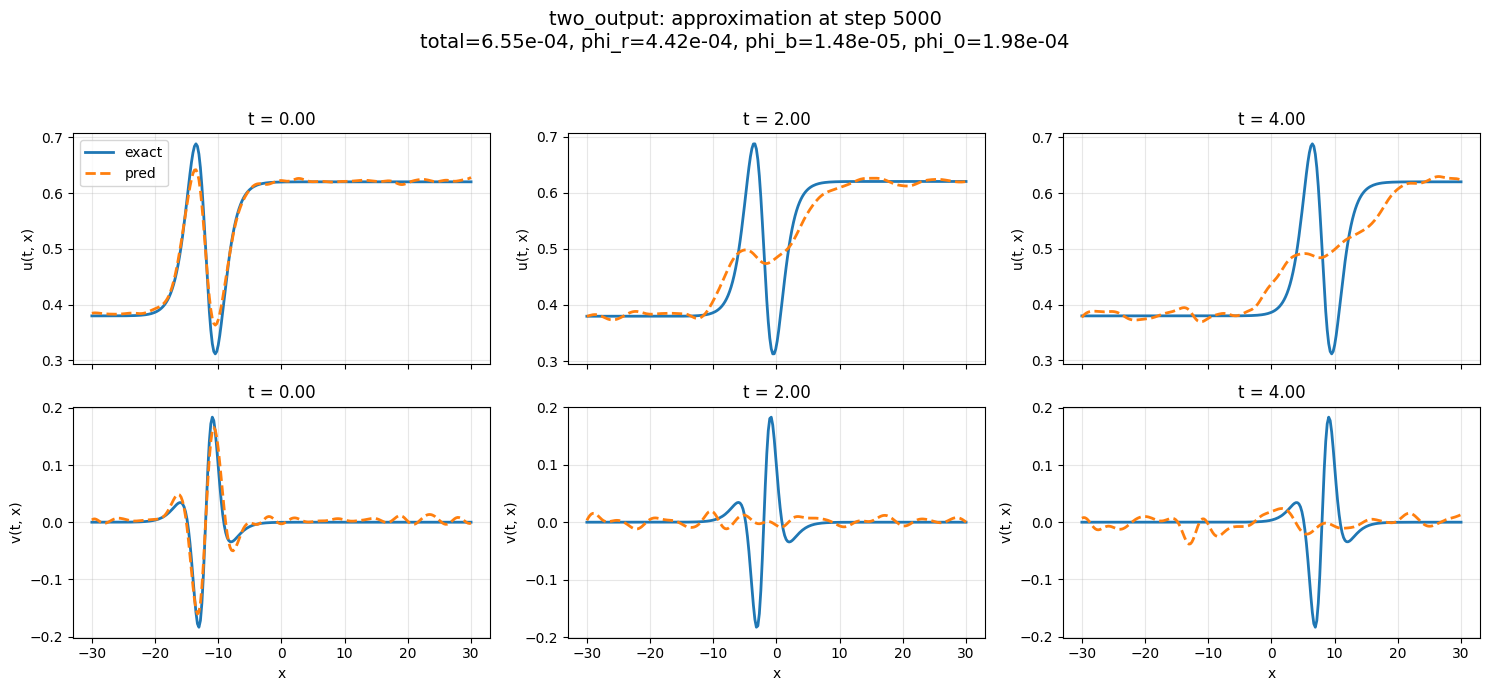

[two_output] step=05100 total=6.900135e-04 (~255.1 residual epochs)
[two_output] step=05200 total=5.519901e-04 (~260.1 residual epochs)
[two_output] step=05300 total=6.635283e-04 (~265.1 residual epochs)
[two_output] step=05400 total=5.106595e-04 (~270.1 residual epochs)
[two_output] step=05500 total=4.603222e-04 (~275.1 residual epochs)
[two_output] step=05600 total=5.769452e-04 (~280.1 residual epochs)
[two_output] step=05700 total=4.739544e-04 (~285.1 residual epochs)
[two_output] step=05800 total=5.246543e-04 (~290.1 residual epochs)
[two_output] step=05900 total=5.667774e-04 (~295.1 residual epochs)
[two_output] step=06000 total=4.221622e-04 (~300.1 residual epochs)


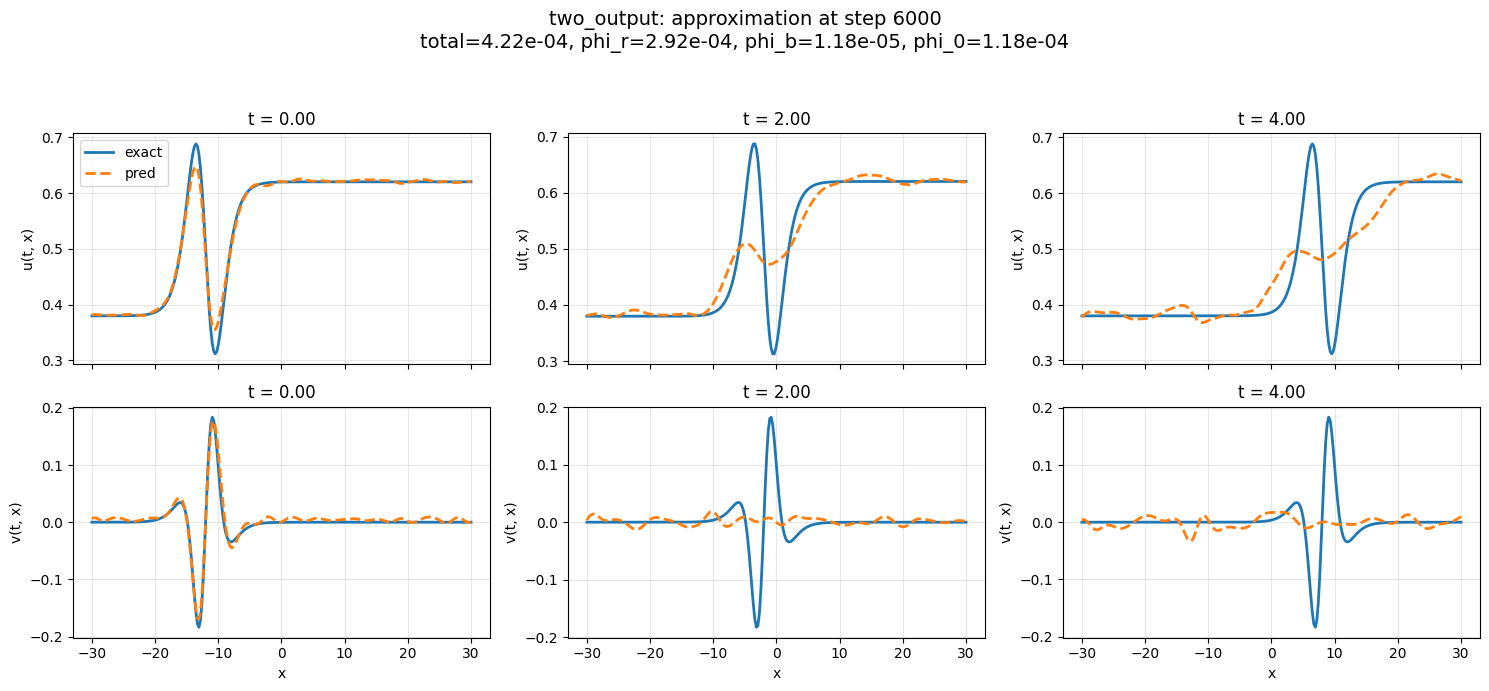

[two_output] step=06100 total=5.533746e-04 (~305.1 residual epochs)
[two_output] step=06200 total=4.173049e-04 (~310.1 residual epochs)
[two_output] step=06300 total=3.903011e-04 (~315.1 residual epochs)
[two_output] step=06400 total=4.018957e-04 (~320.1 residual epochs)
[two_output] step=06500 total=4.149411e-04 (~325.1 residual epochs)
[two_output] step=06600 total=4.437574e-04 (~330.1 residual epochs)
[two_output] step=06700 total=3.836953e-04 (~335.1 residual epochs)
[two_output] step=06800 total=4.137628e-04 (~340.1 residual epochs)
[two_output] step=06900 total=4.202337e-04 (~345.1 residual epochs)
[two_output] step=07000 total=3.679520e-04 (~350.1 residual epochs)


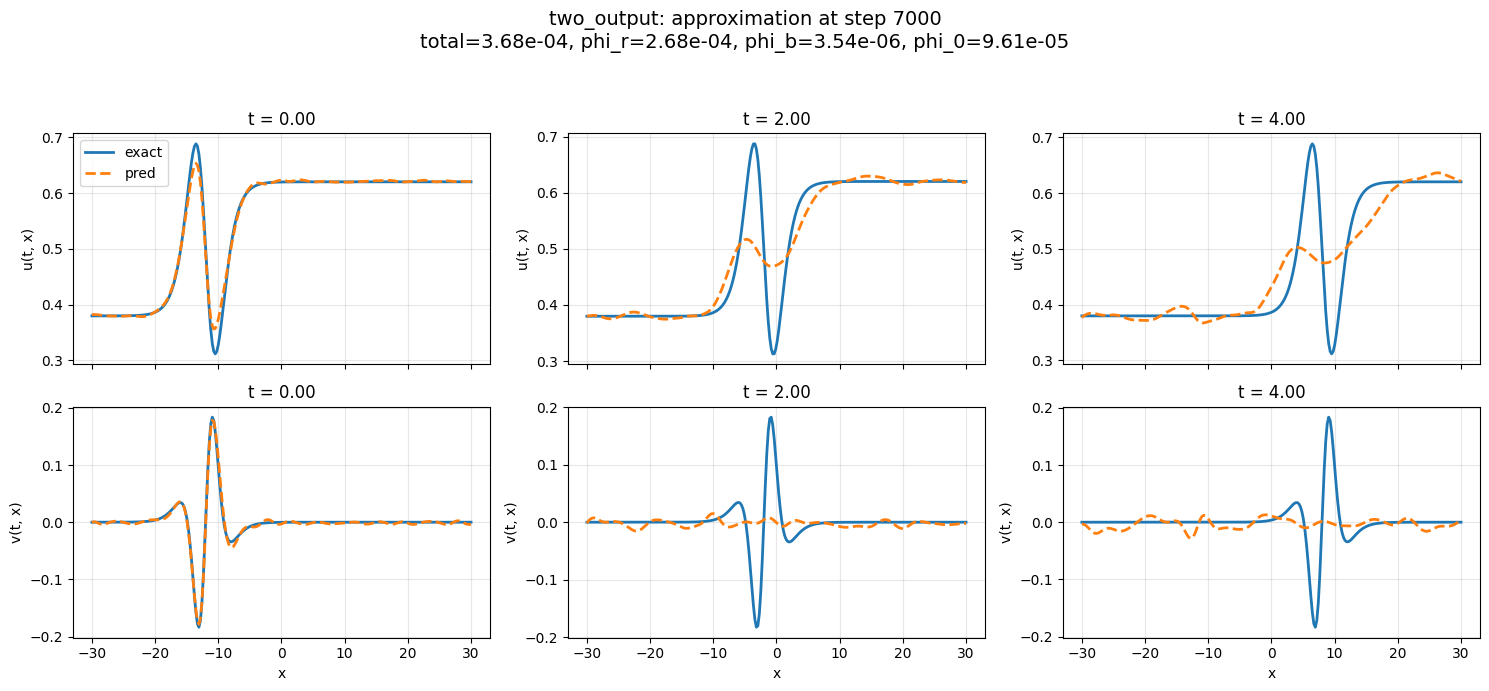

[two_output] step=07100 total=3.810592e-04 (~355.1 residual epochs)
[two_output] step=07200 total=3.803636e-04 (~360.1 residual epochs)
[two_output] step=07300 total=3.641954e-04 (~365.1 residual epochs)
[two_output] step=07400 total=3.704744e-04 (~370.1 residual epochs)
[two_output] step=07500 total=3.374404e-04 (~375.1 residual epochs)
[two_output] step=07600 total=4.247147e-04 (~380.1 residual epochs)
[two_output] step=07700 total=3.149439e-04 (~385.1 residual epochs)
[two_output] step=07800 total=3.355091e-04 (~390.1 residual epochs)
[two_output] step=07900 total=3.084663e-04 (~395.1 residual epochs)
[two_output] step=08000 total=3.451543e-04 (~400.1 residual epochs)


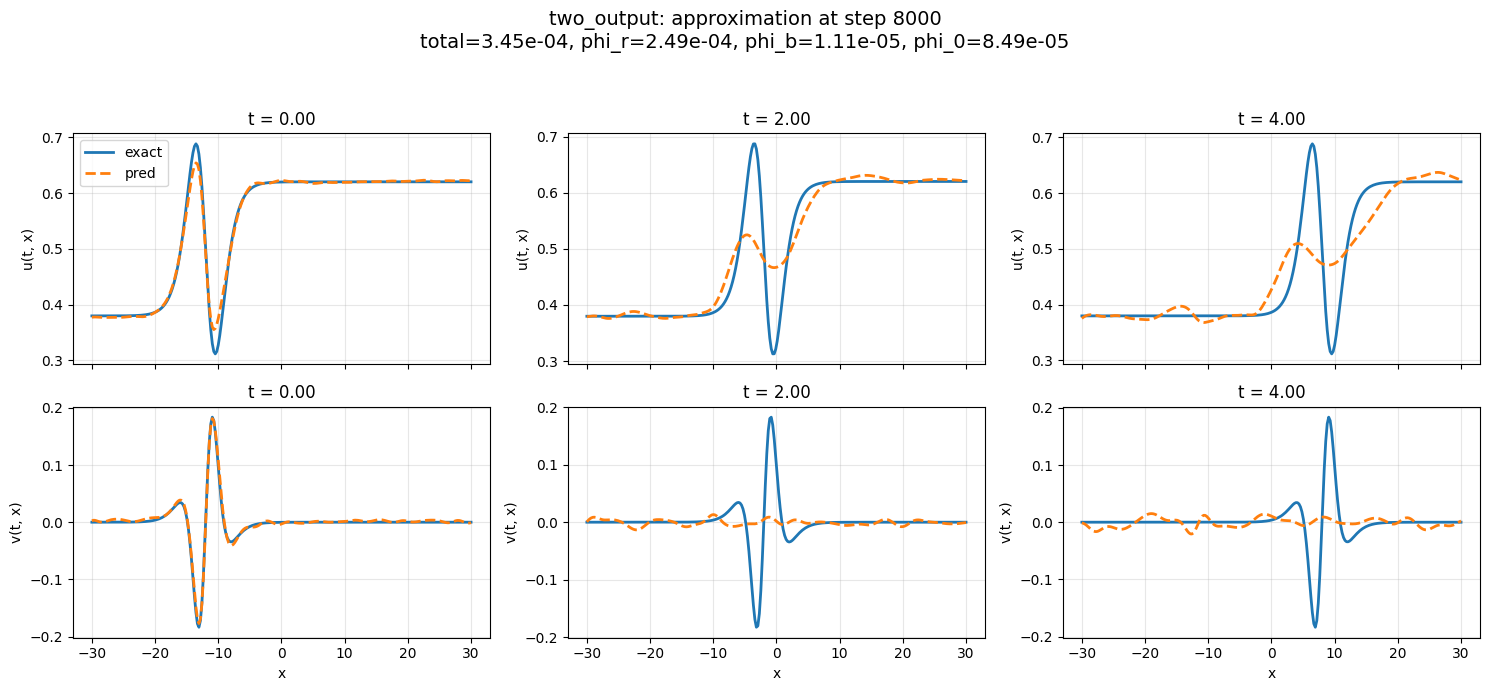

[two_output] step=08100 total=3.140463e-04 (~405.1 residual epochs)
[two_output] step=08200 total=3.179192e-04 (~410.1 residual epochs)
[two_output] step=08300 total=3.522665e-04 (~415.1 residual epochs)
[two_output] step=08400 total=3.870948e-04 (~420.1 residual epochs)
[two_output] step=08500 total=3.314694e-04 (~425.1 residual epochs)
[two_output] step=08600 total=3.178297e-04 (~430.1 residual epochs)
[two_output] step=08700 total=3.078553e-04 (~435.1 residual epochs)
[two_output] step=08800 total=3.612421e-04 (~440.1 residual epochs)
[two_output] step=08900 total=3.327657e-04 (~445.1 residual epochs)
[two_output] step=09000 total=3.553437e-04 (~450.1 residual epochs)


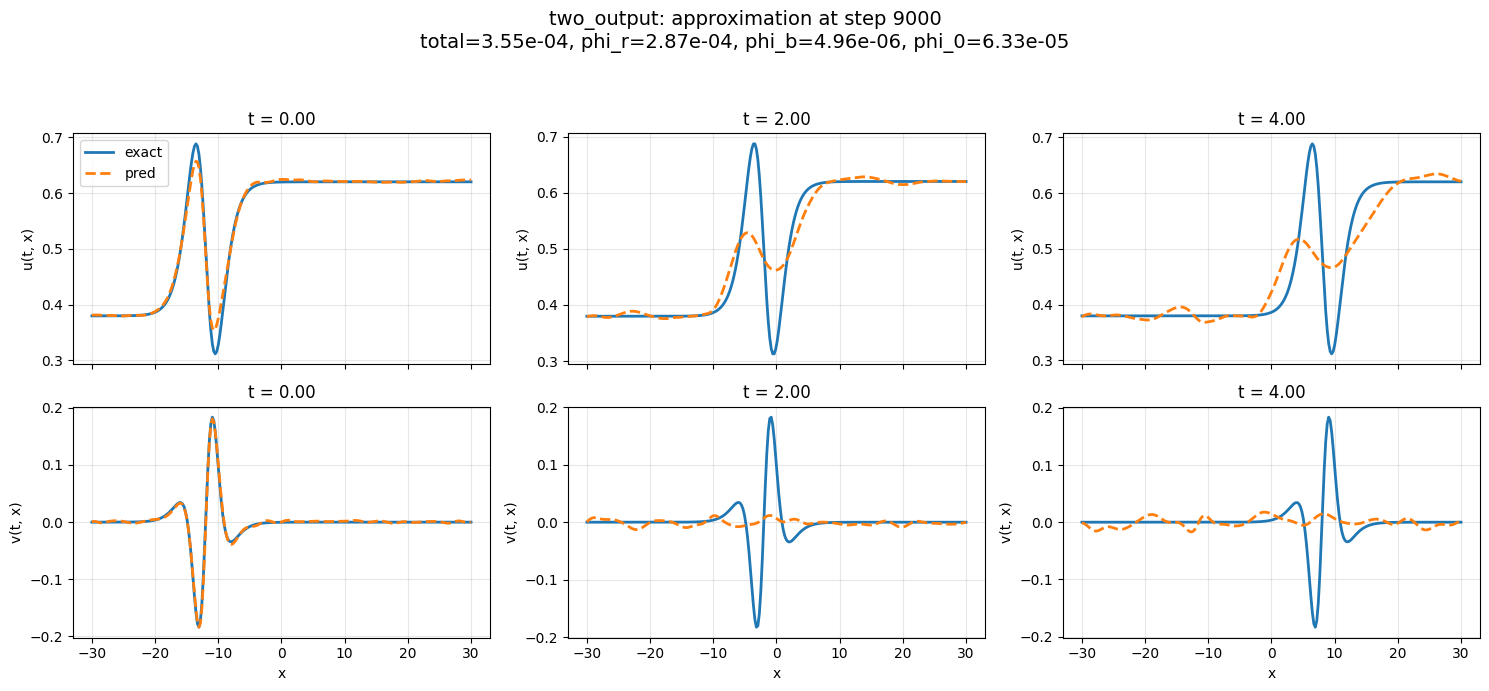

[two_output] step=09100 total=3.719373e-04 (~455.1 residual epochs)
[two_output] step=09200 total=2.968171e-04 (~460.1 residual epochs)
[two_output] step=09300 total=3.345324e-04 (~465.1 residual epochs)
[two_output] step=09400 total=3.775966e-04 (~470.1 residual epochs)
[two_output] step=09500 total=3.153511e-04 (~475.1 residual epochs)
[two_output] step=09600 total=3.296323e-04 (~480.1 residual epochs)
[two_output] step=09700 total=2.837319e-04 (~485.1 residual epochs)
[two_output] step=09800 total=3.935409e-04 (~490.1 residual epochs)
[two_output] step=09900 total=3.367484e-04 (~495.1 residual epochs)
[two_output] step=10000 total=2.639793e-04 (~500.1 residual epochs)


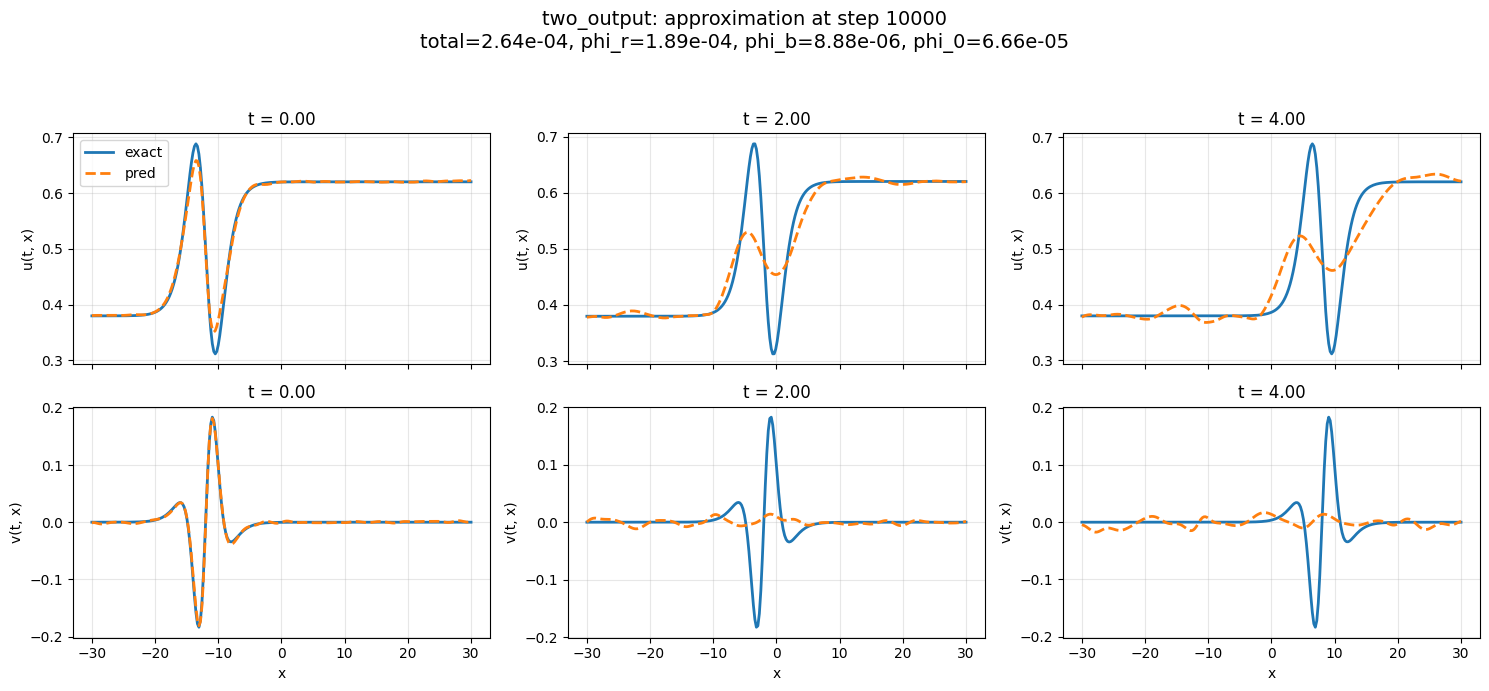

[two_output] step=10100 total=2.693032e-04 (~505.1 residual epochs)
[two_output] step=10200 total=2.969854e-04 (~510.1 residual epochs)
[two_output] step=10300 total=3.211903e-04 (~515.0 residual epochs)
[two_output] step=10400 total=2.544040e-04 (~520.0 residual epochs)
[two_output] step=10500 total=3.491078e-04 (~525.0 residual epochs)
[two_output] step=10600 total=2.938933e-04 (~530.0 residual epochs)
[two_output] step=10700 total=2.884567e-04 (~535.0 residual epochs)
[two_output] step=10800 total=2.555999e-04 (~540.0 residual epochs)
[two_output] step=10900 total=3.732532e-04 (~545.0 residual epochs)
[two_output] step=11000 total=3.430466e-04 (~550.0 residual epochs)


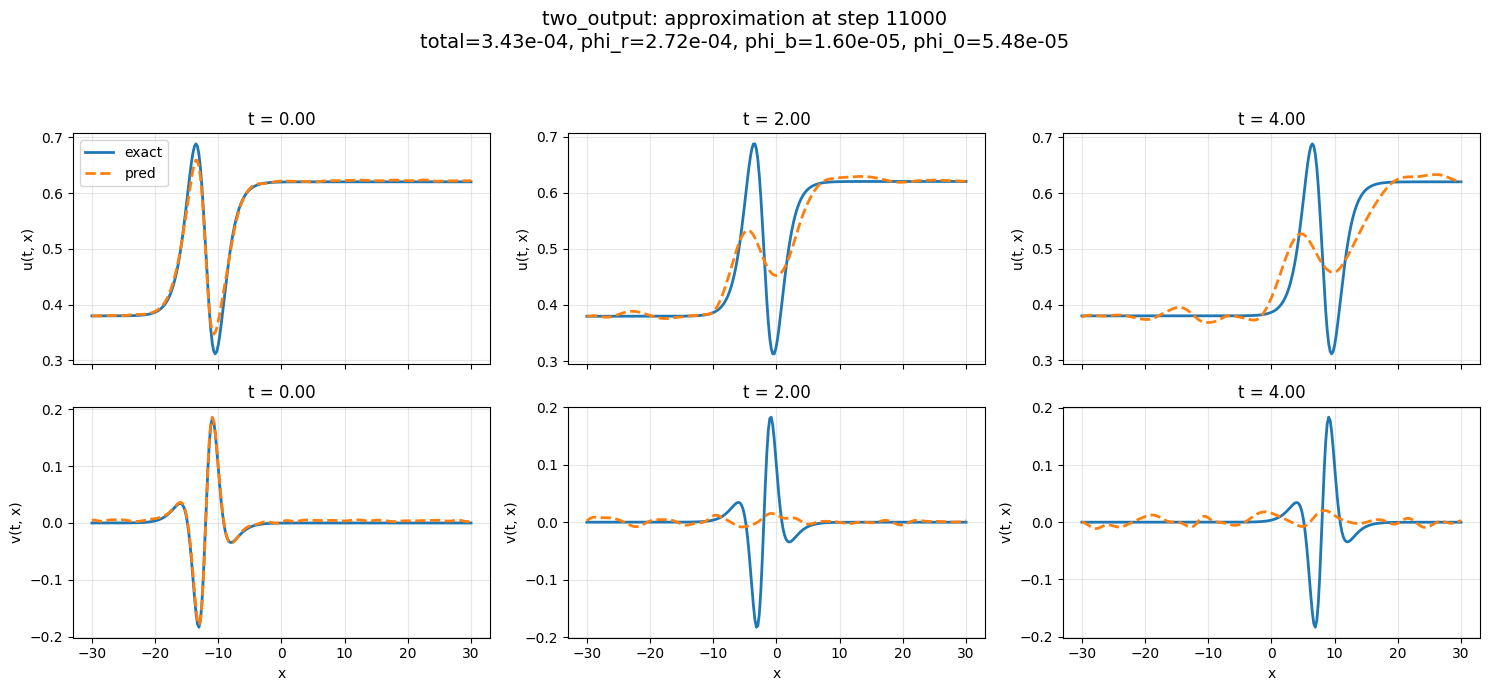

[two_output] step=11100 total=3.859283e-04 (~555.0 residual epochs)
[two_output] step=11200 total=3.094962e-04 (~560.0 residual epochs)
[two_output] step=11300 total=3.766608e-04 (~565.0 residual epochs)
[two_output] step=11400 total=2.754194e-04 (~570.0 residual epochs)
[two_output] step=11500 total=3.142415e-04 (~575.0 residual epochs)
[two_output] step=11600 total=2.880979e-04 (~580.0 residual epochs)
[two_output] step=11700 total=2.601354e-04 (~585.0 residual epochs)
[two_output] step=11800 total=2.408090e-04 (~590.0 residual epochs)
[two_output] step=11900 total=2.941790e-04 (~595.0 residual epochs)
[two_output] step=12000 total=2.762448e-04 (~600.0 residual epochs)


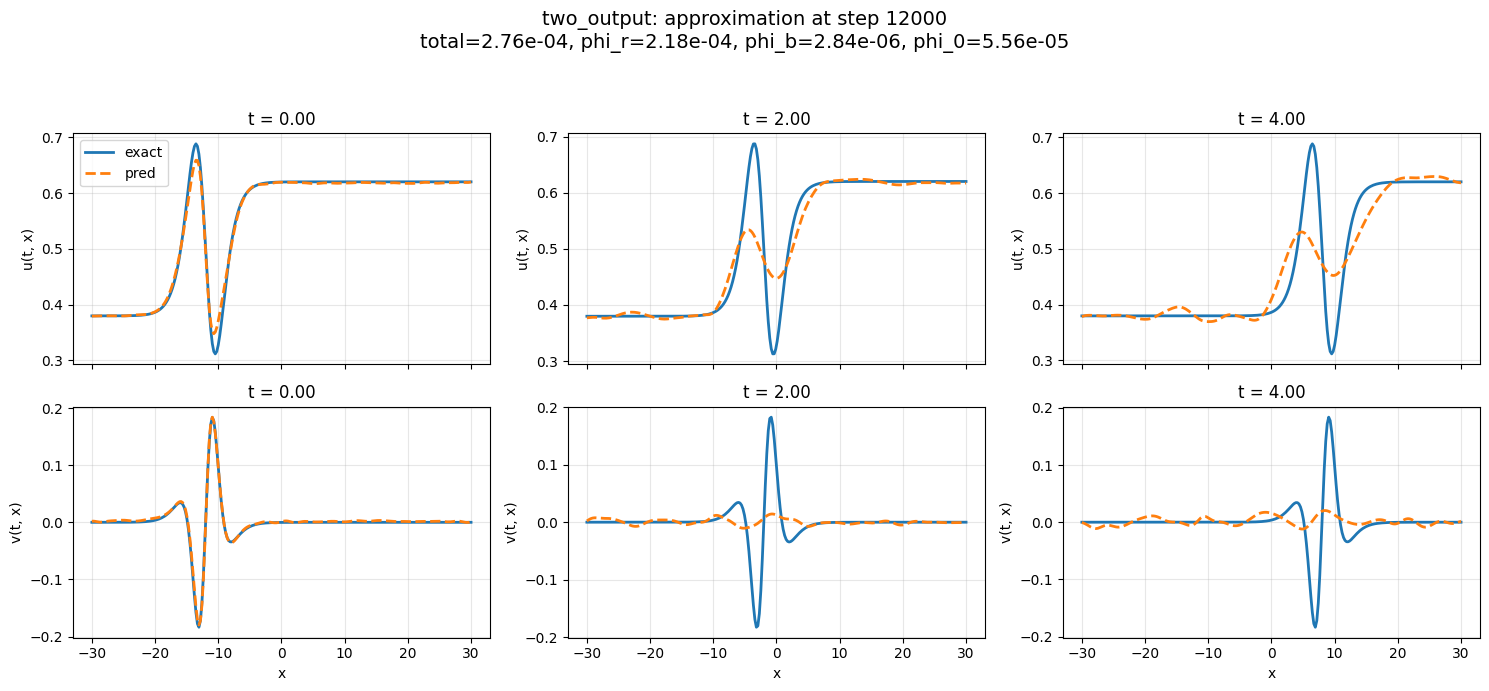

[two_output] step=12100 total=2.640361e-04 (~605.0 residual epochs)
[two_output] step=12200 total=3.064403e-04 (~610.0 residual epochs)
[two_output] step=12300 total=2.169345e-04 (~615.0 residual epochs)
[two_output] step=12400 total=2.702008e-04 (~620.0 residual epochs)
[two_output] step=12500 total=2.560163e-04 (~625.0 residual epochs)
[two_output] step=12600 total=3.312868e-04 (~630.0 residual epochs)
[two_output] step=12700 total=2.826326e-04 (~635.0 residual epochs)
[two_output] step=12800 total=2.653261e-04 (~640.0 residual epochs)
[two_output] step=12900 total=2.936341e-04 (~645.0 residual epochs)
[two_output] step=13000 total=2.488827e-04 (~650.0 residual epochs)


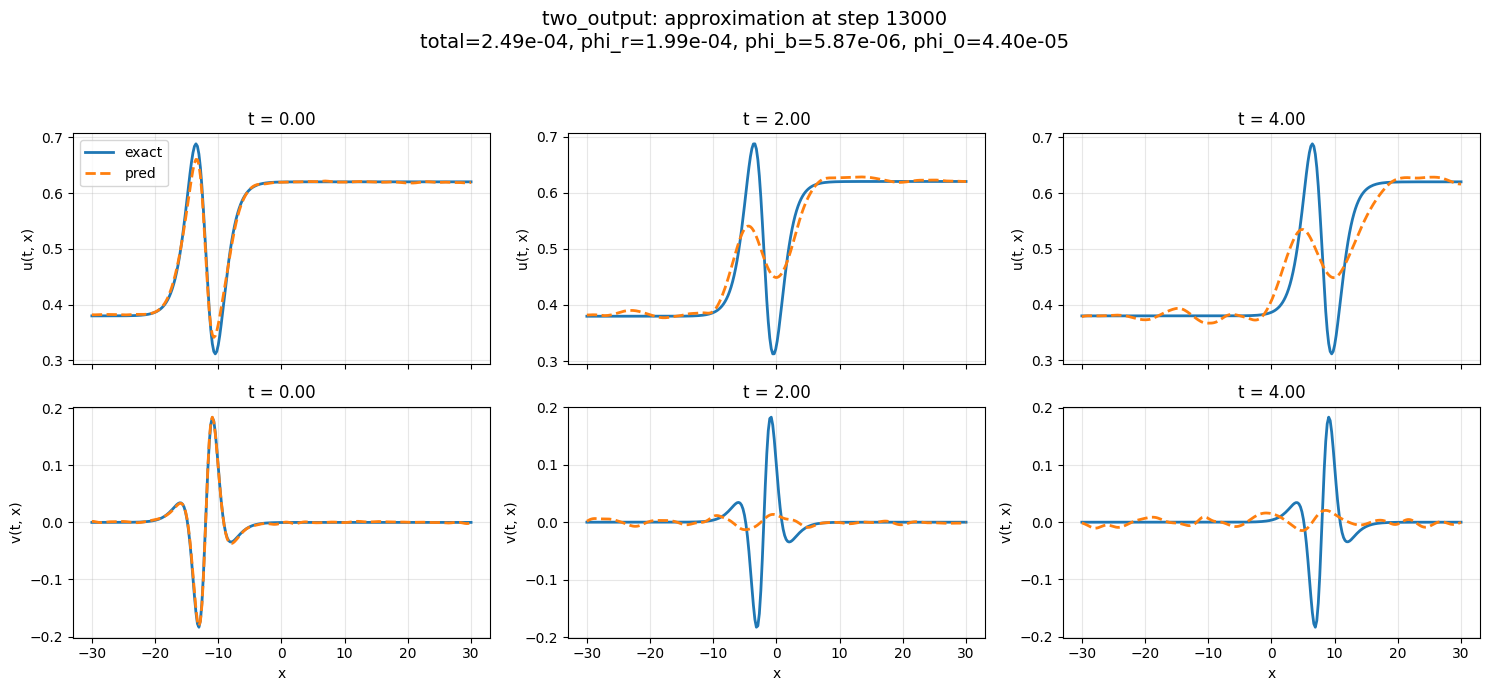

[two_output] elapsed: 140.26 sec
[two_models] training device: /CPU:0
[two_models] residual batch size: 1024, batches/epoch ~= 20
[two_models] step=00000 total=2.393185e+00 (~0.1 residual epochs)


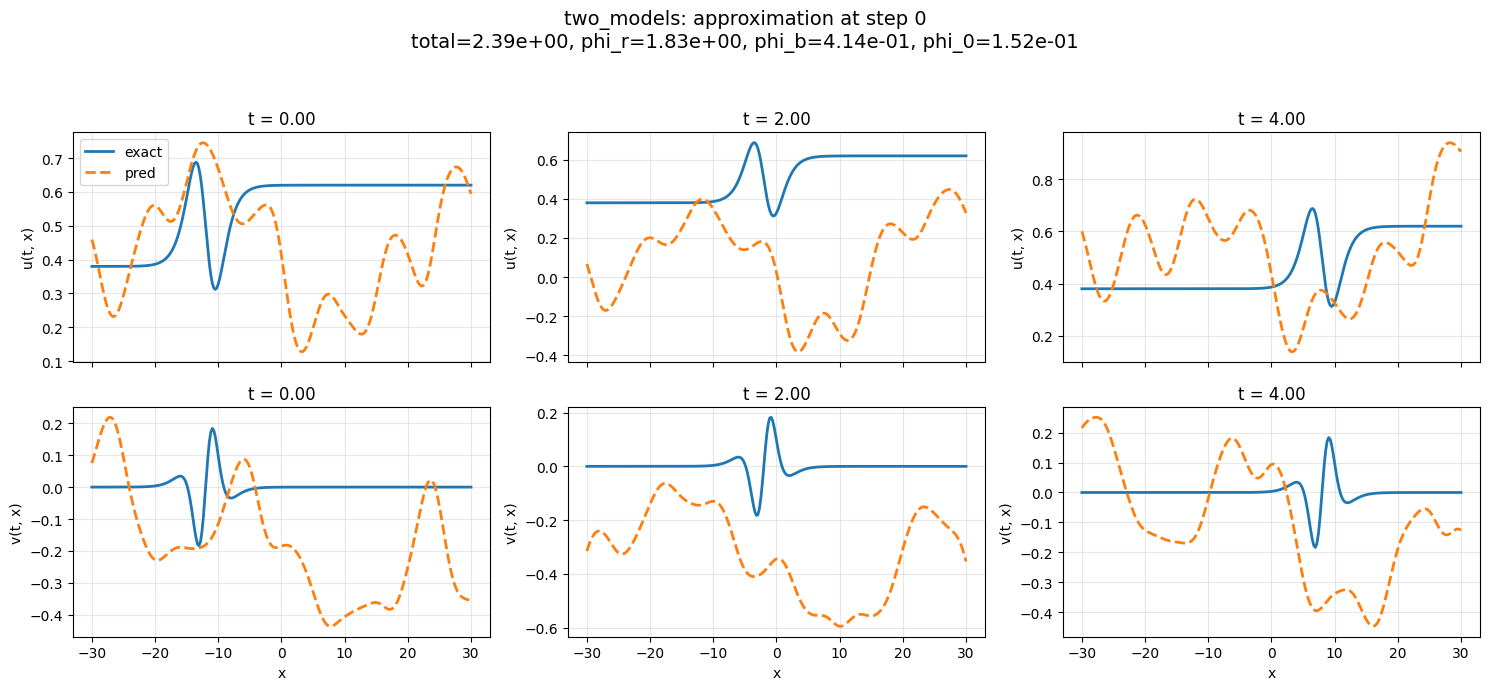

[two_models] step=00100 total=1.967037e-02 (~5.0 residual epochs)
[two_models] step=00200 total=1.039297e-02 (~10.1 residual epochs)
[two_models] step=00300 total=7.280153e-03 (~15.1 residual epochs)
[two_models] step=00400 total=5.772032e-03 (~20.1 residual epochs)
[two_models] step=00500 total=5.014449e-03 (~25.1 residual epochs)
[two_models] step=00600 total=4.237728e-03 (~30.1 residual epochs)
[two_models] step=00700 total=3.842387e-03 (~35.0 residual epochs)
[two_models] step=00800 total=3.510174e-03 (~40.0 residual epochs)
[two_models] step=00900 total=3.118355e-03 (~45.0 residual epochs)
[two_models] step=01000 total=2.947500e-03 (~50.0 residual epochs)


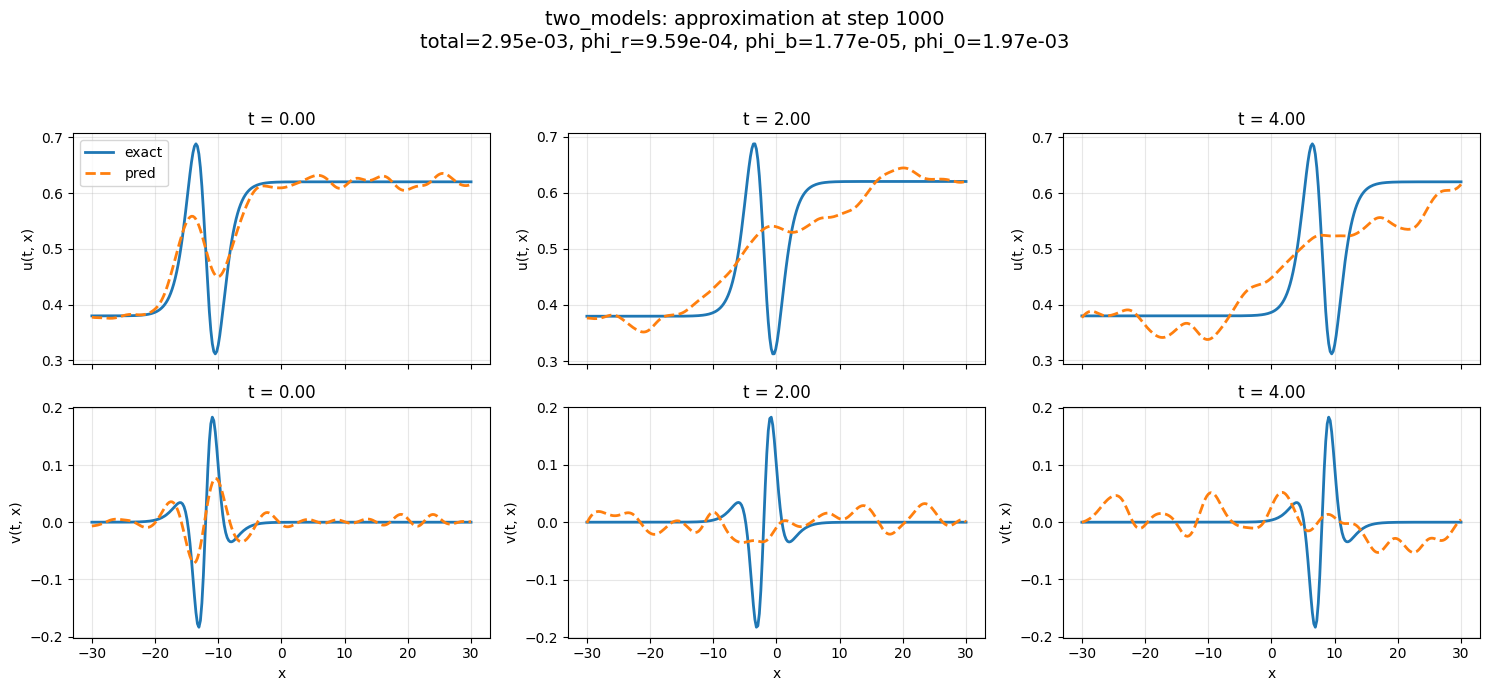

[two_models] step=01100 total=2.663913e-03 (~55.0 residual epochs)
[two_models] step=01200 total=2.581192e-03 (~60.0 residual epochs)
[two_models] step=01300 total=2.399517e-03 (~65.0 residual epochs)
[two_models] step=01400 total=2.231558e-03 (~70.0 residual epochs)
[two_models] step=01500 total=2.300084e-03 (~75.0 residual epochs)
[two_models] step=01600 total=1.878944e-03 (~80.0 residual epochs)
[two_models] step=01700 total=1.966900e-03 (~85.0 residual epochs)
[two_models] step=01800 total=1.818372e-03 (~90.0 residual epochs)
[two_models] step=01900 total=1.553059e-03 (~95.0 residual epochs)
[two_models] step=02000 total=1.601482e-03 (~100.0 residual epochs)


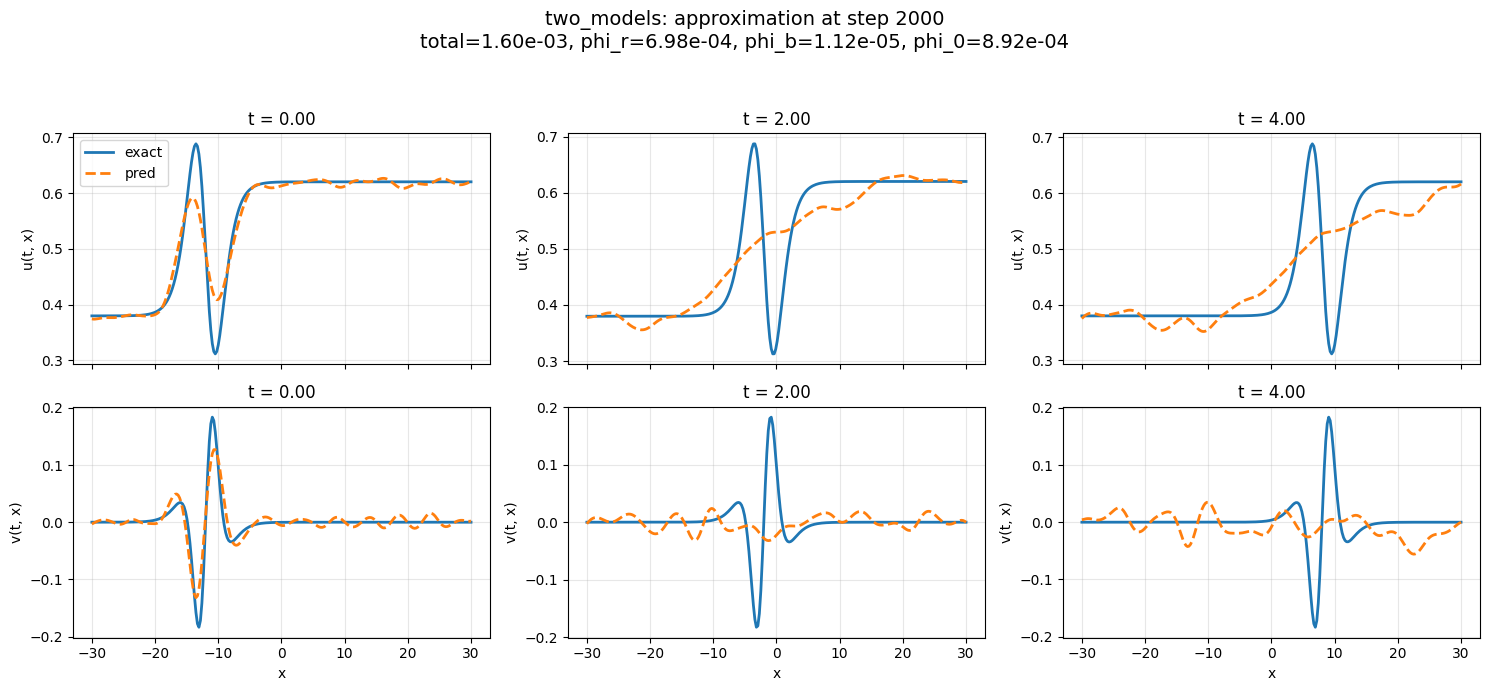

[two_models] step=02100 total=1.403995e-03 (~105.0 residual epochs)
[two_models] step=02200 total=1.293858e-03 (~110.0 residual epochs)
[two_models] step=02300 total=1.218097e-03 (~115.0 residual epochs)
[two_models] step=02400 total=1.251290e-03 (~120.0 residual epochs)
[two_models] step=02500 total=1.183341e-03 (~125.0 residual epochs)
[two_models] step=02600 total=1.007384e-03 (~130.1 residual epochs)
[two_models] step=02700 total=9.307315e-04 (~135.1 residual epochs)
[two_models] step=02800 total=1.039454e-03 (~140.1 residual epochs)
[two_models] step=02900 total=9.113440e-04 (~145.1 residual epochs)
[two_models] step=03000 total=8.372421e-04 (~150.1 residual epochs)


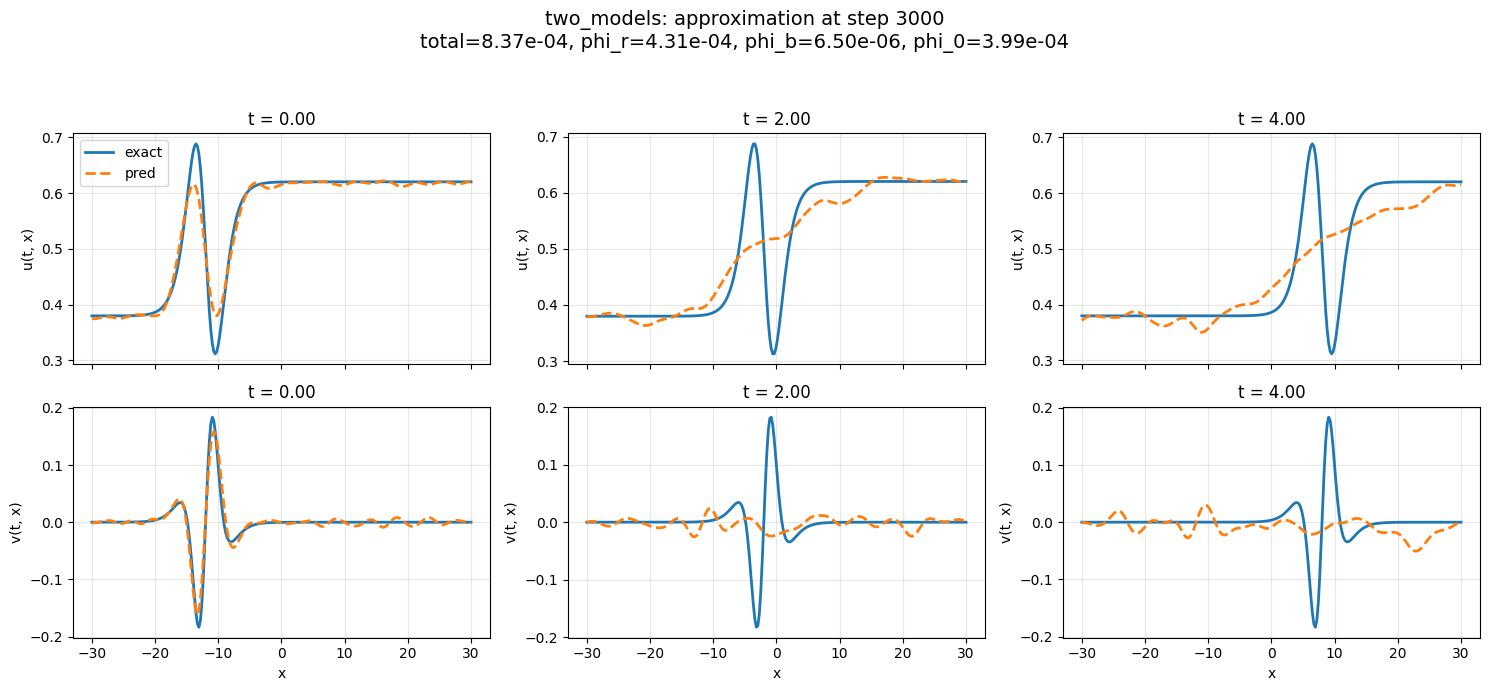

[two_models] step=03100 total=7.905173e-04 (~155.1 residual epochs)
[two_models] step=03200 total=7.489633e-04 (~160.1 residual epochs)
[two_models] step=03300 total=7.177130e-04 (~165.1 residual epochs)
[two_models] step=03400 total=8.008543e-04 (~170.1 residual epochs)
[two_models] step=03500 total=7.184580e-04 (~175.1 residual epochs)
[two_models] step=03600 total=6.775025e-04 (~180.1 residual epochs)
[two_models] step=03700 total=5.769290e-04 (~185.1 residual epochs)
[two_models] step=03800 total=6.590571e-04 (~190.1 residual epochs)
[two_models] step=03900 total=5.351065e-04 (~195.1 residual epochs)
[two_models] step=04000 total=5.744959e-04 (~200.1 residual epochs)


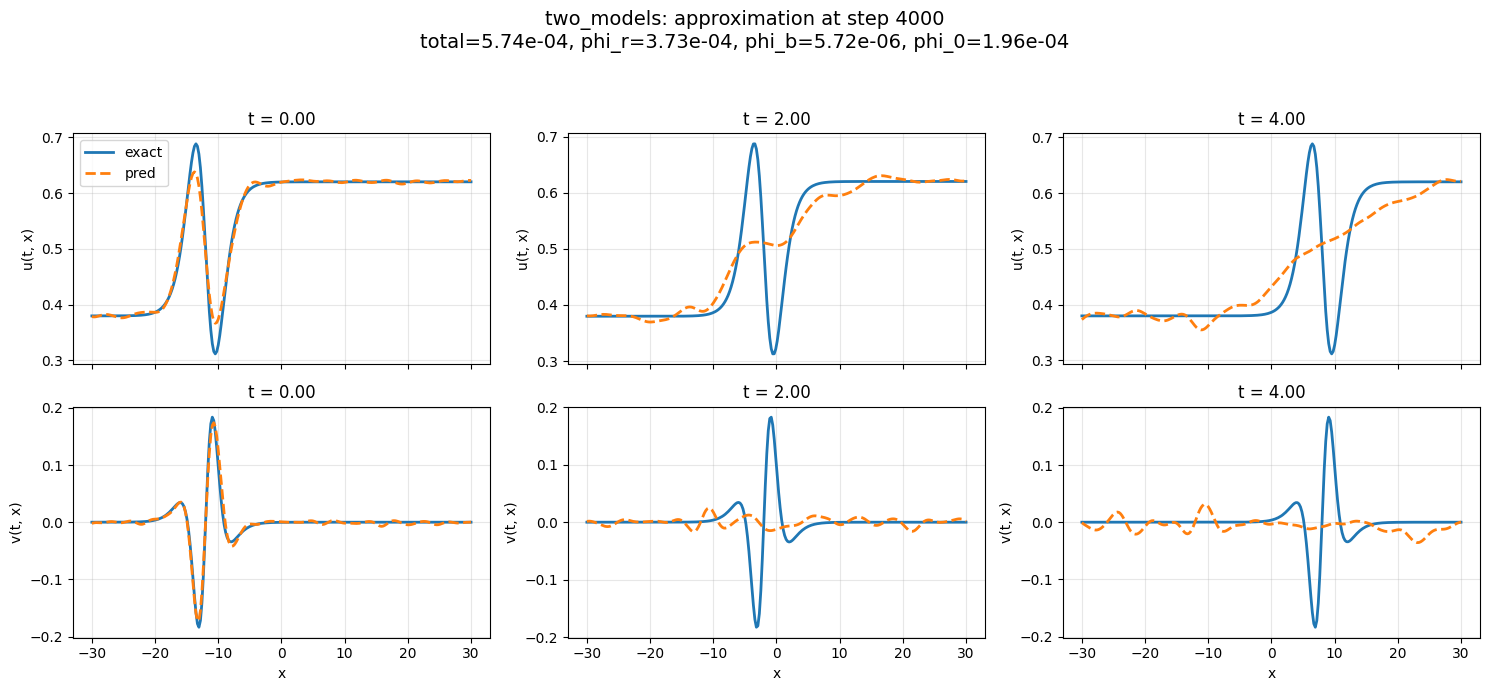

[two_models] step=04100 total=6.011775e-04 (~205.1 residual epochs)
[two_models] step=04200 total=6.362600e-04 (~210.1 residual epochs)
[two_models] step=04300 total=5.532479e-04 (~215.1 residual epochs)
[two_models] step=04400 total=5.546970e-04 (~220.1 residual epochs)
[two_models] step=04500 total=5.318488e-04 (~225.1 residual epochs)
[two_models] step=04600 total=5.518014e-04 (~230.1 residual epochs)
[two_models] step=04700 total=4.809377e-04 (~235.1 residual epochs)
[two_models] step=04800 total=4.079374e-04 (~240.1 residual epochs)
[two_models] step=04900 total=4.948256e-04 (~245.1 residual epochs)
[two_models] step=05000 total=4.364005e-04 (~250.1 residual epochs)


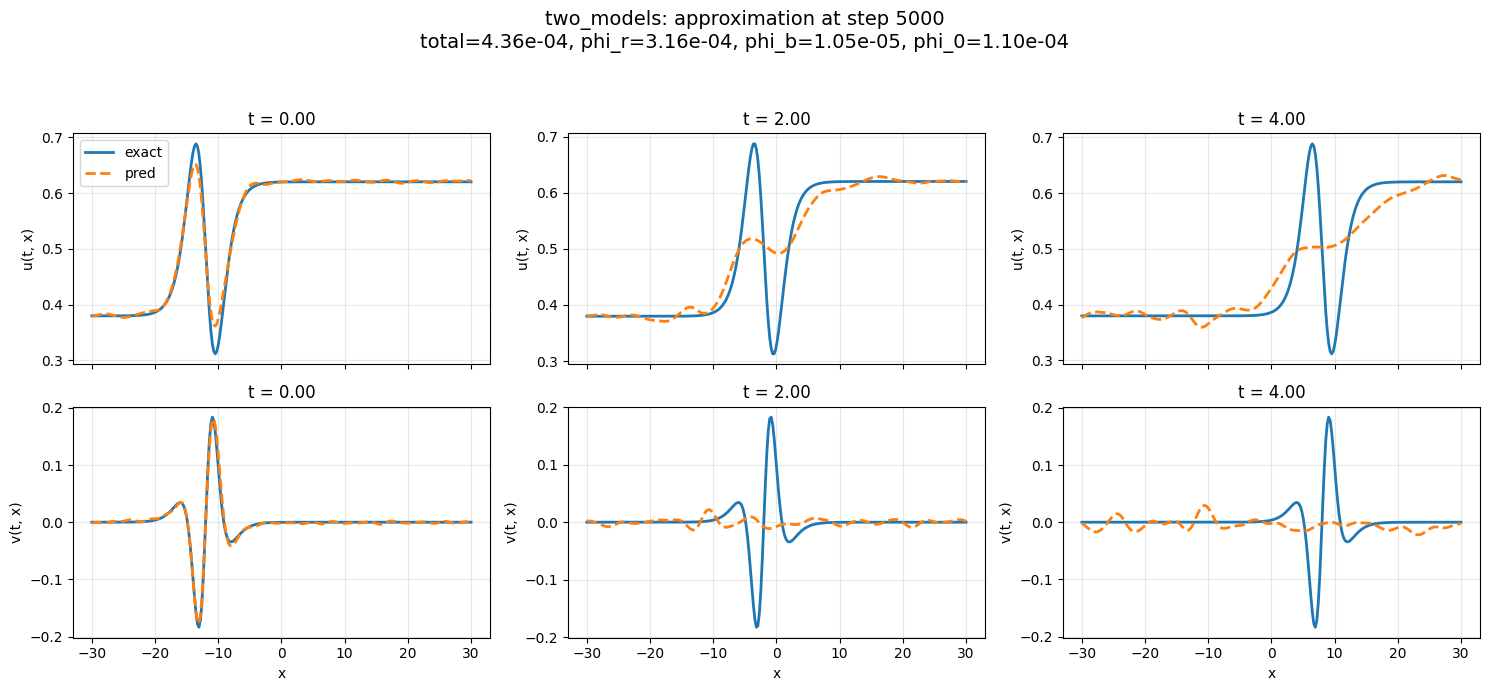

[two_models] step=05100 total=4.685146e-04 (~255.1 residual epochs)
[two_models] step=05200 total=3.885693e-04 (~260.1 residual epochs)
[two_models] step=05300 total=4.658371e-04 (~265.1 residual epochs)
[two_models] step=05400 total=3.825413e-04 (~270.1 residual epochs)
[two_models] step=05500 total=3.244921e-04 (~275.1 residual epochs)
[two_models] step=05600 total=4.152661e-04 (~280.1 residual epochs)
[two_models] step=05700 total=3.274882e-04 (~285.1 residual epochs)
[two_models] step=05800 total=4.149127e-04 (~290.1 residual epochs)
[two_models] step=05900 total=3.993277e-04 (~295.1 residual epochs)
[two_models] step=06000 total=3.051200e-04 (~300.1 residual epochs)


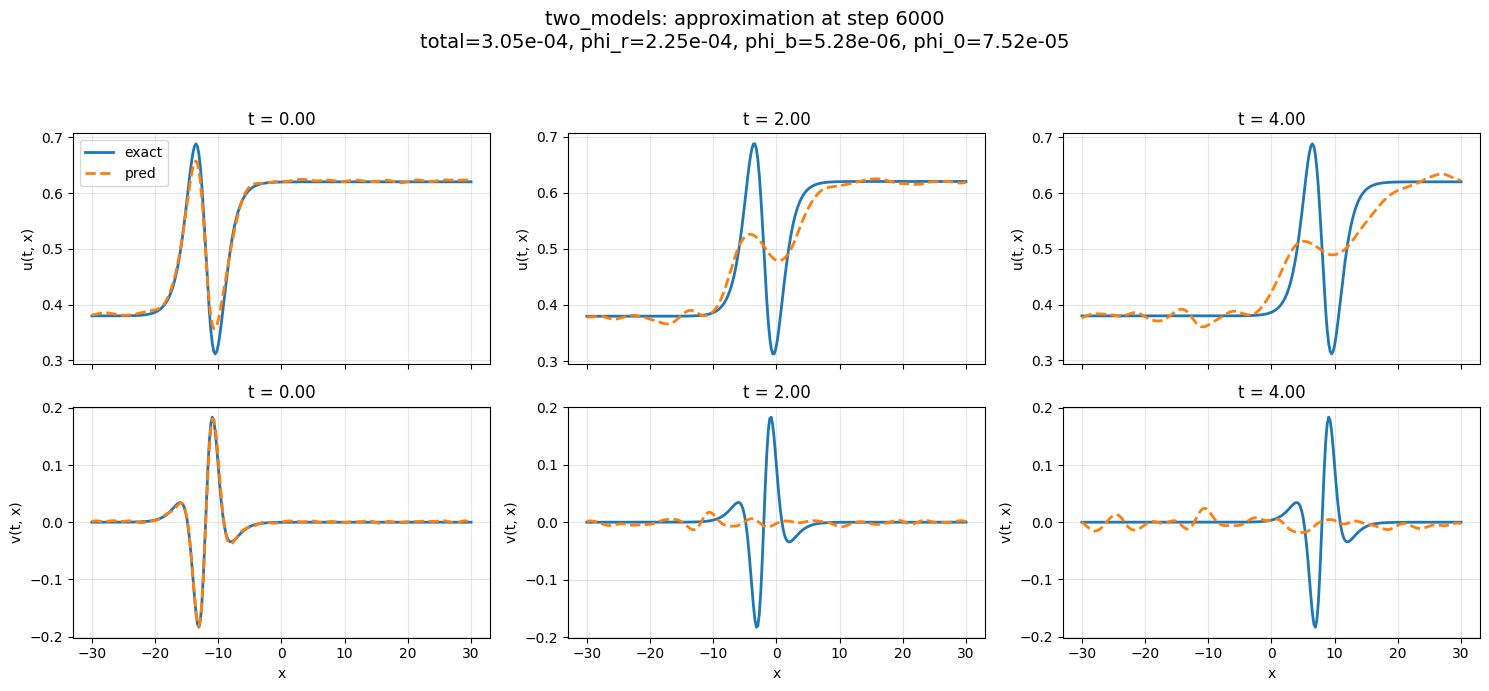

[two_models] step=06100 total=4.548075e-04 (~305.1 residual epochs)
[two_models] step=06200 total=3.008652e-04 (~310.1 residual epochs)
[two_models] step=06300 total=3.021475e-04 (~315.1 residual epochs)
[two_models] step=06400 total=3.182270e-04 (~320.1 residual epochs)
[two_models] step=06500 total=3.298474e-04 (~325.1 residual epochs)
[two_models] step=06600 total=3.595843e-04 (~330.1 residual epochs)
[two_models] step=06700 total=3.078654e-04 (~335.1 residual epochs)
[two_models] step=06800 total=3.172647e-04 (~340.1 residual epochs)
[two_models] step=06900 total=3.266139e-04 (~345.1 residual epochs)
[two_models] step=07000 total=2.825260e-04 (~350.1 residual epochs)


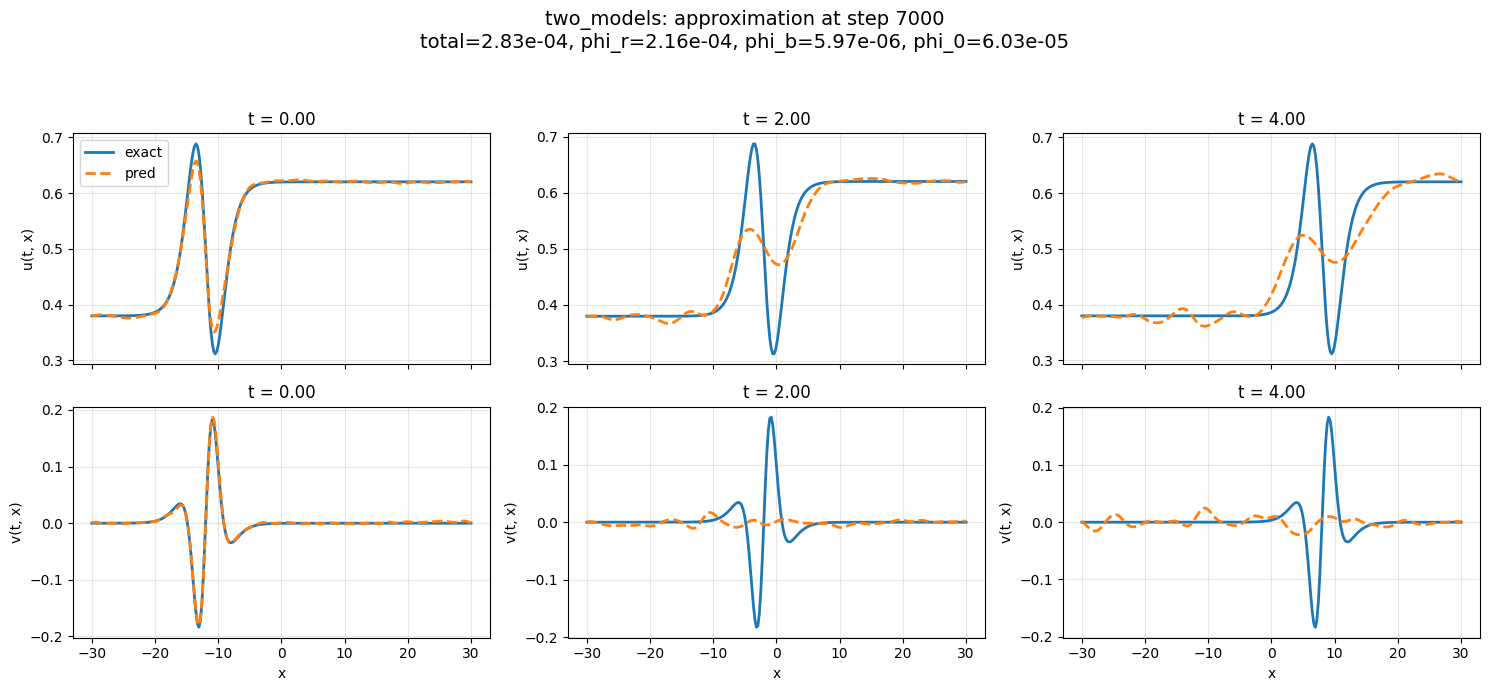

[two_models] step=07100 total=3.278061e-04 (~355.1 residual epochs)
[two_models] step=07200 total=2.834399e-04 (~360.1 residual epochs)
[two_models] step=07300 total=3.129011e-04 (~365.1 residual epochs)
[two_models] step=07400 total=2.924160e-04 (~370.1 residual epochs)
[two_models] step=07500 total=3.036500e-04 (~375.1 residual epochs)
[two_models] step=07600 total=3.114631e-04 (~380.1 residual epochs)
[two_models] step=07700 total=2.487973e-04 (~385.1 residual epochs)
[two_models] step=07800 total=2.595744e-04 (~390.1 residual epochs)
[two_models] step=07900 total=2.996265e-04 (~395.1 residual epochs)
[two_models] step=08000 total=2.631325e-04 (~400.1 residual epochs)


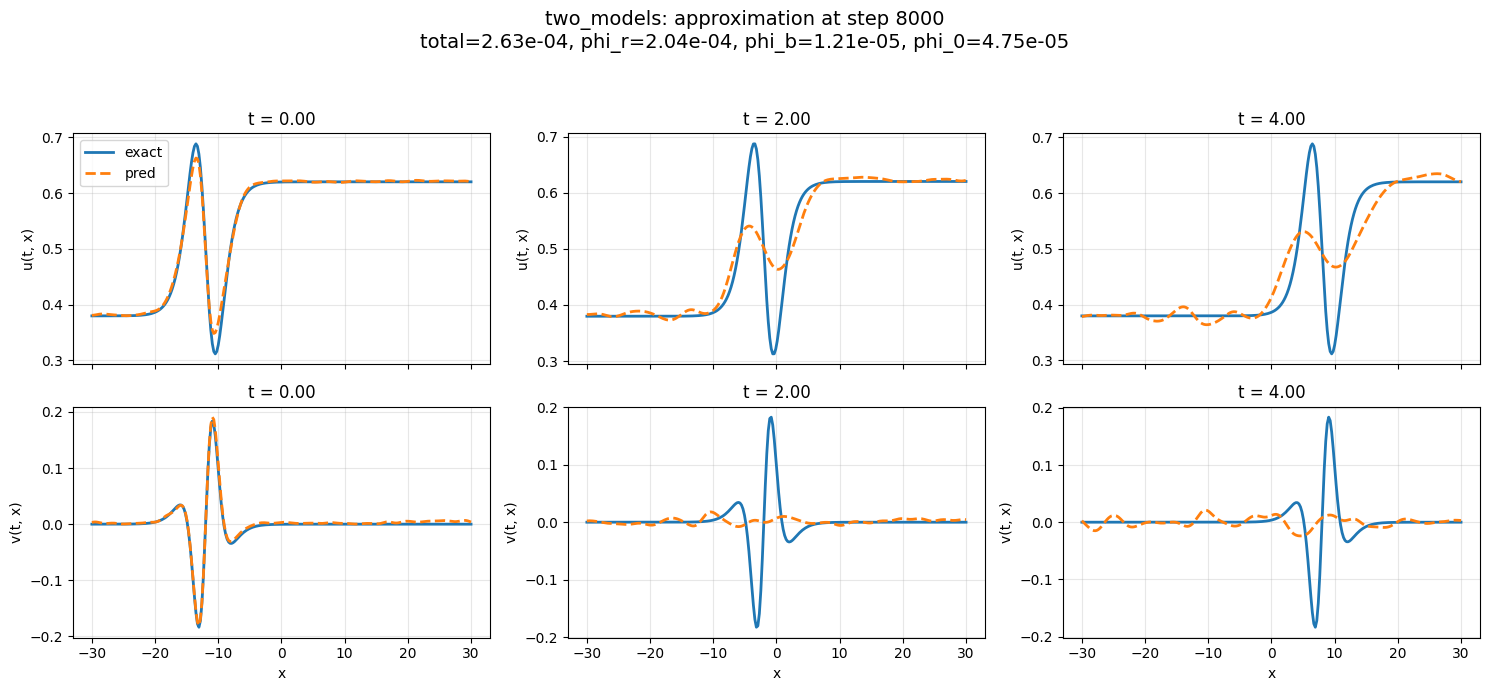

[two_models] step=08100 total=2.603786e-04 (~405.1 residual epochs)
[two_models] step=08200 total=2.469043e-04 (~410.1 residual epochs)
[two_models] step=08300 total=3.171137e-04 (~415.1 residual epochs)
[two_models] step=08400 total=2.972134e-04 (~420.1 residual epochs)
[two_models] step=08500 total=2.553439e-04 (~425.1 residual epochs)
[two_models] step=08600 total=2.384654e-04 (~430.1 residual epochs)
[two_models] step=08700 total=2.787470e-04 (~435.1 residual epochs)
[two_models] step=08800 total=2.829656e-04 (~440.1 residual epochs)
[two_models] step=08900 total=2.468794e-04 (~445.1 residual epochs)
[two_models] step=09000 total=2.758440e-04 (~450.1 residual epochs)


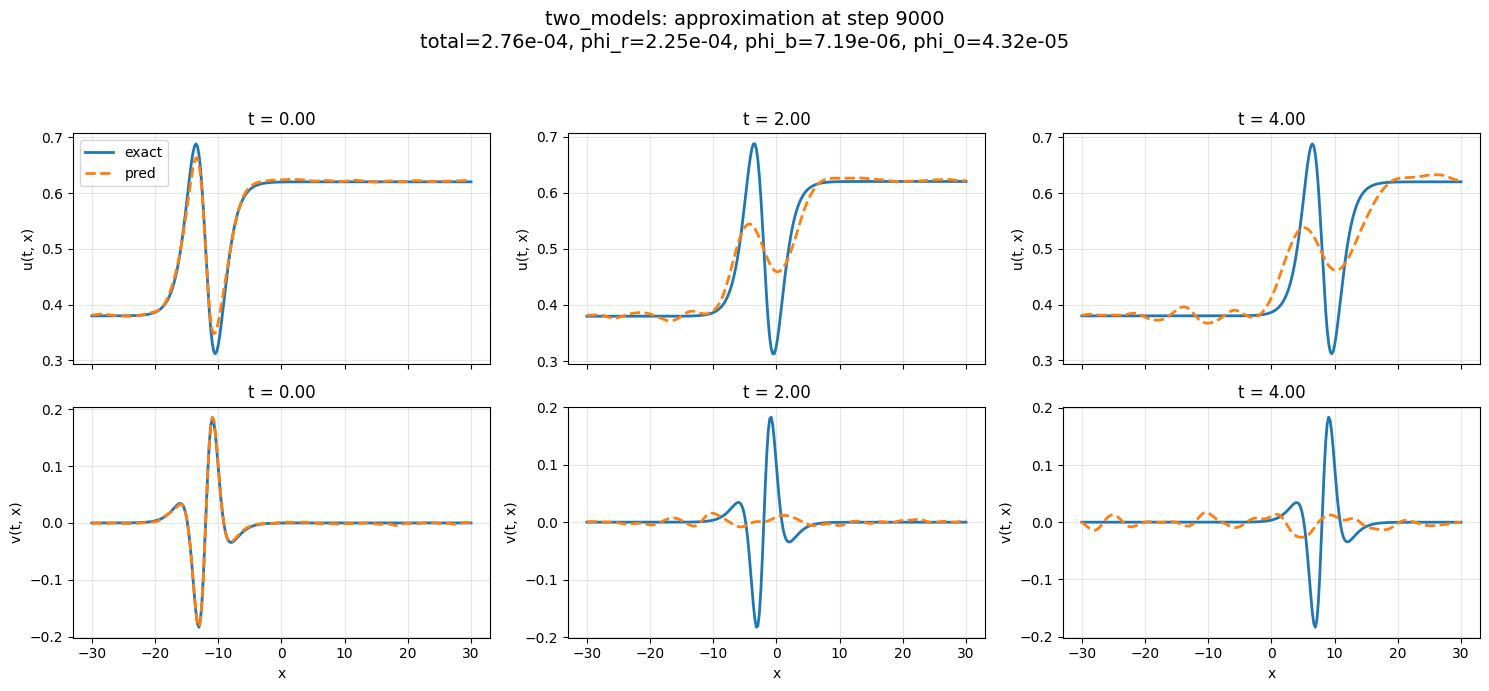

[two_models] step=09100 total=2.858052e-04 (~455.1 residual epochs)
[two_models] step=09200 total=2.246862e-04 (~460.1 residual epochs)
[two_models] step=09300 total=2.616931e-04 (~465.1 residual epochs)
[two_models] step=09400 total=2.871021e-04 (~470.1 residual epochs)
[two_models] step=09500 total=2.148333e-04 (~475.1 residual epochs)
[two_models] step=09600 total=2.848561e-04 (~480.1 residual epochs)
[two_models] step=09700 total=2.260096e-04 (~485.1 residual epochs)
[two_models] step=09800 total=2.932978e-04 (~490.1 residual epochs)
[two_models] step=09900 total=2.688045e-04 (~495.1 residual epochs)
[two_models] step=10000 total=2.079862e-04 (~500.1 residual epochs)


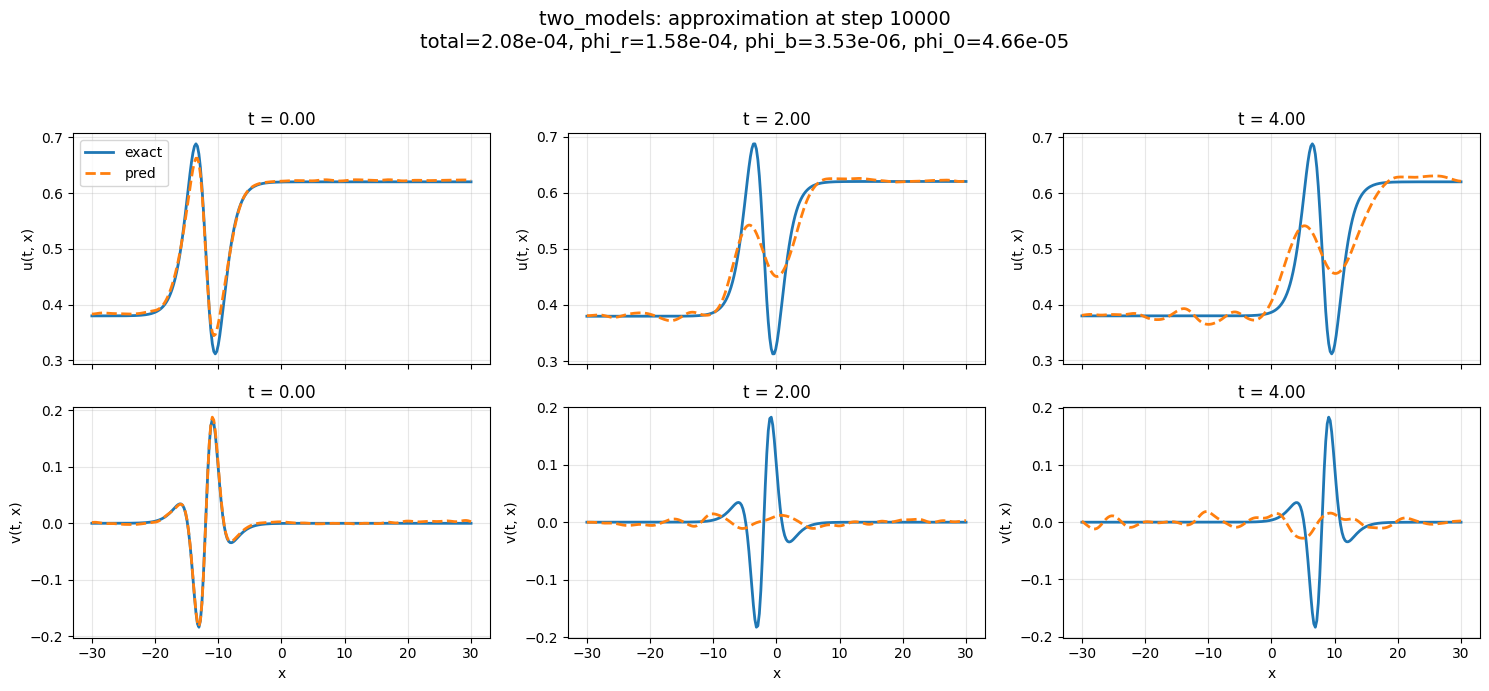

[two_models] step=10100 total=2.092423e-04 (~505.1 residual epochs)
[two_models] step=10200 total=2.366834e-04 (~510.1 residual epochs)
[two_models] step=10300 total=2.403554e-04 (~515.0 residual epochs)
[two_models] step=10400 total=2.011345e-04 (~520.0 residual epochs)
[two_models] step=10500 total=2.832346e-04 (~525.0 residual epochs)
[two_models] step=10600 total=2.489925e-04 (~530.0 residual epochs)
[two_models] step=10700 total=2.431528e-04 (~535.0 residual epochs)
[two_models] step=10800 total=2.667832e-04 (~540.0 residual epochs)
[two_models] step=10900 total=2.444696e-04 (~545.0 residual epochs)
[two_models] step=11000 total=2.508740e-04 (~550.0 residual epochs)


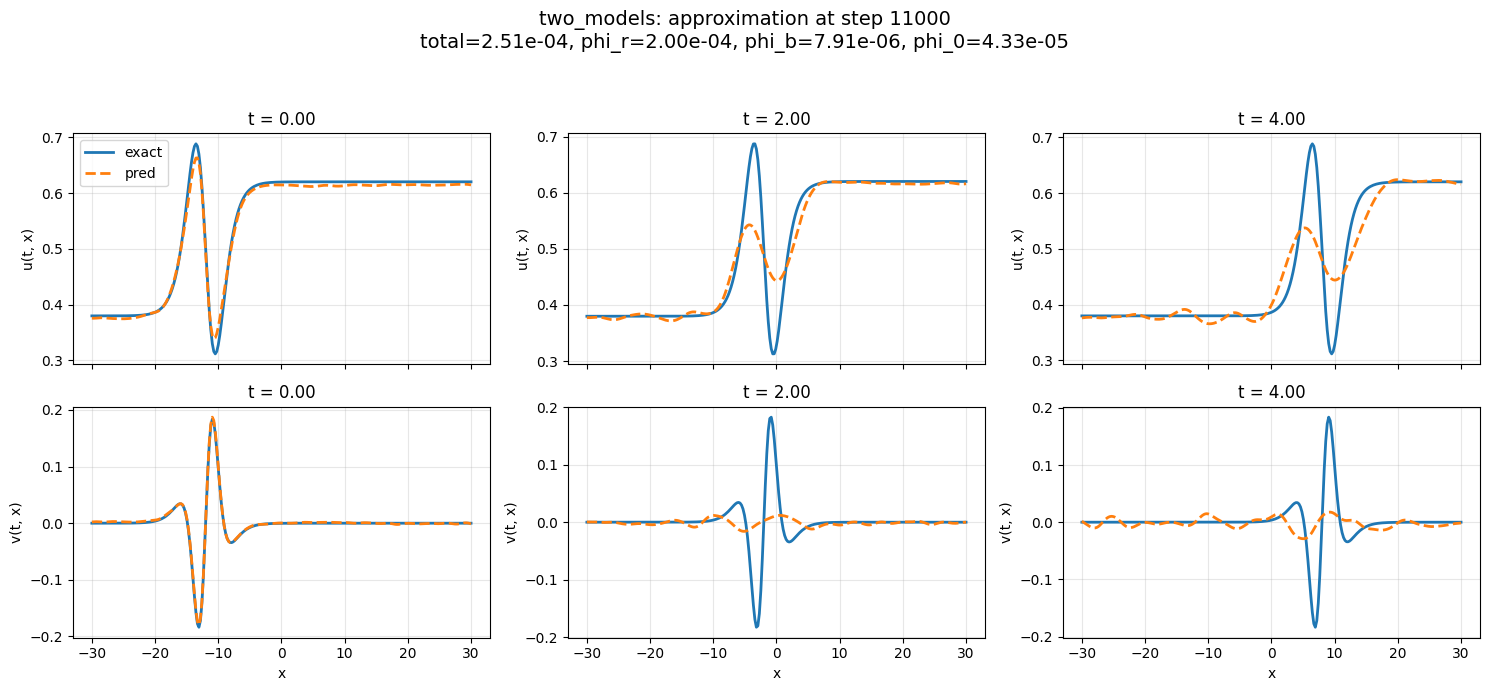

[two_models] step=11100 total=2.884844e-04 (~555.0 residual epochs)
[two_models] step=11200 total=2.254061e-04 (~560.0 residual epochs)
[two_models] step=11300 total=2.706222e-04 (~565.0 residual epochs)
[two_models] step=11400 total=1.826110e-04 (~570.0 residual epochs)
[two_models] step=11500 total=2.202833e-04 (~575.0 residual epochs)
[two_models] step=11600 total=3.076801e-04 (~580.0 residual epochs)
[two_models] step=11700 total=1.839105e-04 (~585.0 residual epochs)
[two_models] step=11800 total=1.955705e-04 (~590.0 residual epochs)
[two_models] step=11900 total=2.307264e-04 (~595.0 residual epochs)
[two_models] step=12000 total=2.391289e-04 (~600.0 residual epochs)


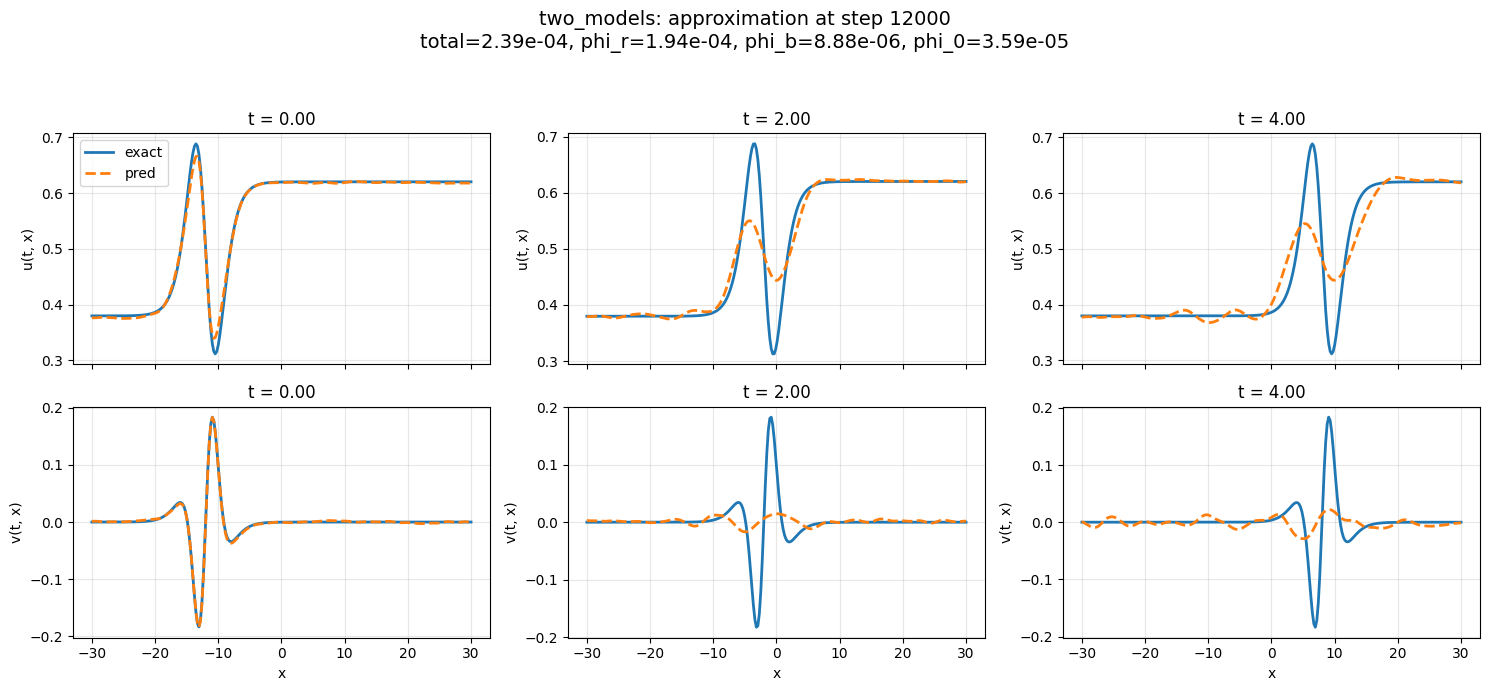

[two_models] step=12100 total=2.064817e-04 (~605.0 residual epochs)
[two_models] step=12200 total=2.168112e-04 (~610.0 residual epochs)
[two_models] step=12300 total=2.069662e-04 (~615.0 residual epochs)
[two_models] step=12400 total=2.172454e-04 (~620.0 residual epochs)
[two_models] step=12500 total=1.847047e-04 (~625.0 residual epochs)
[two_models] step=12600 total=2.685853e-04 (~630.0 residual epochs)
[two_models] step=12700 total=2.564197e-04 (~635.0 residual epochs)
[two_models] step=12800 total=1.973220e-04 (~640.0 residual epochs)
[two_models] step=12900 total=2.285651e-04 (~645.0 residual epochs)
[two_models] step=13000 total=2.134125e-04 (~650.0 residual epochs)


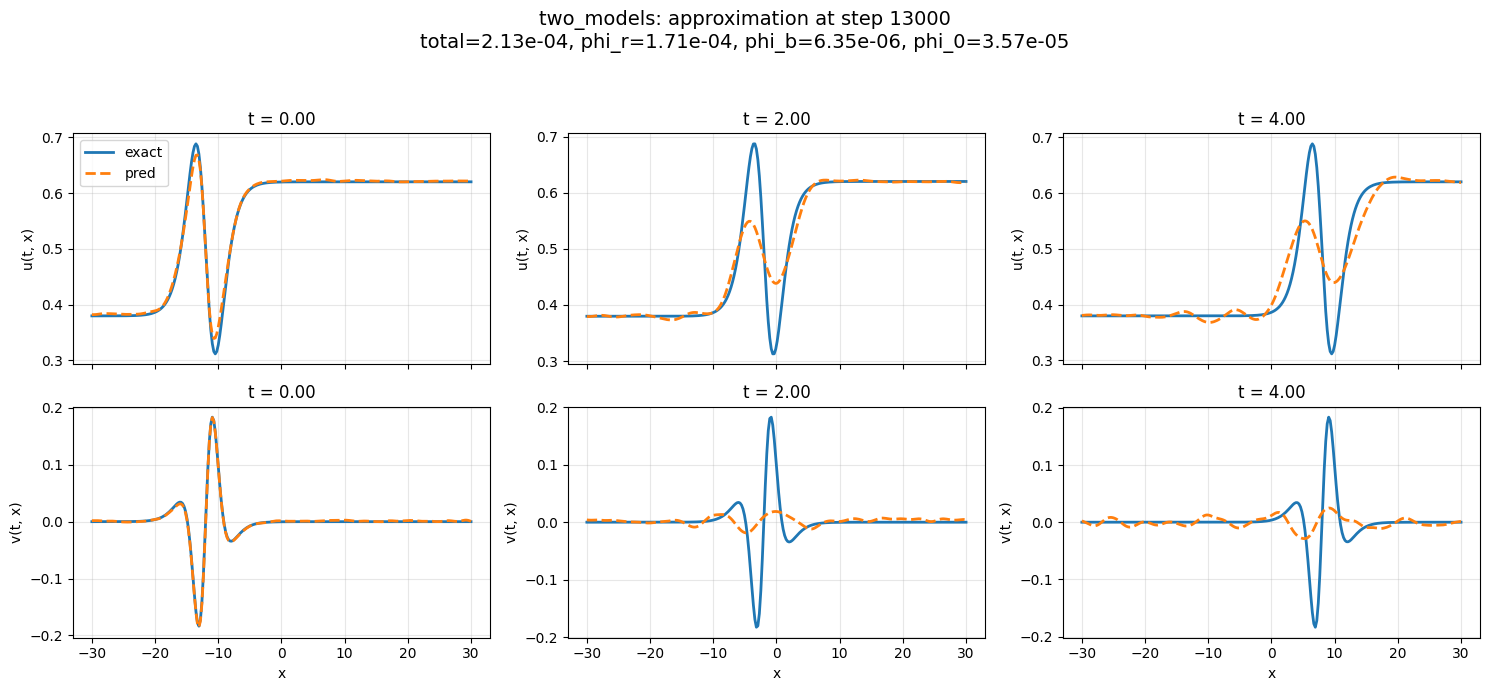

[two_models] elapsed: 168.66 sec
[shared_trunk] training device: /CPU:0
[shared_trunk] residual batch size: 1024, batches/epoch ~= 20
[shared_trunk] step=00000 total=2.112903e+00 (~0.1 residual epochs)


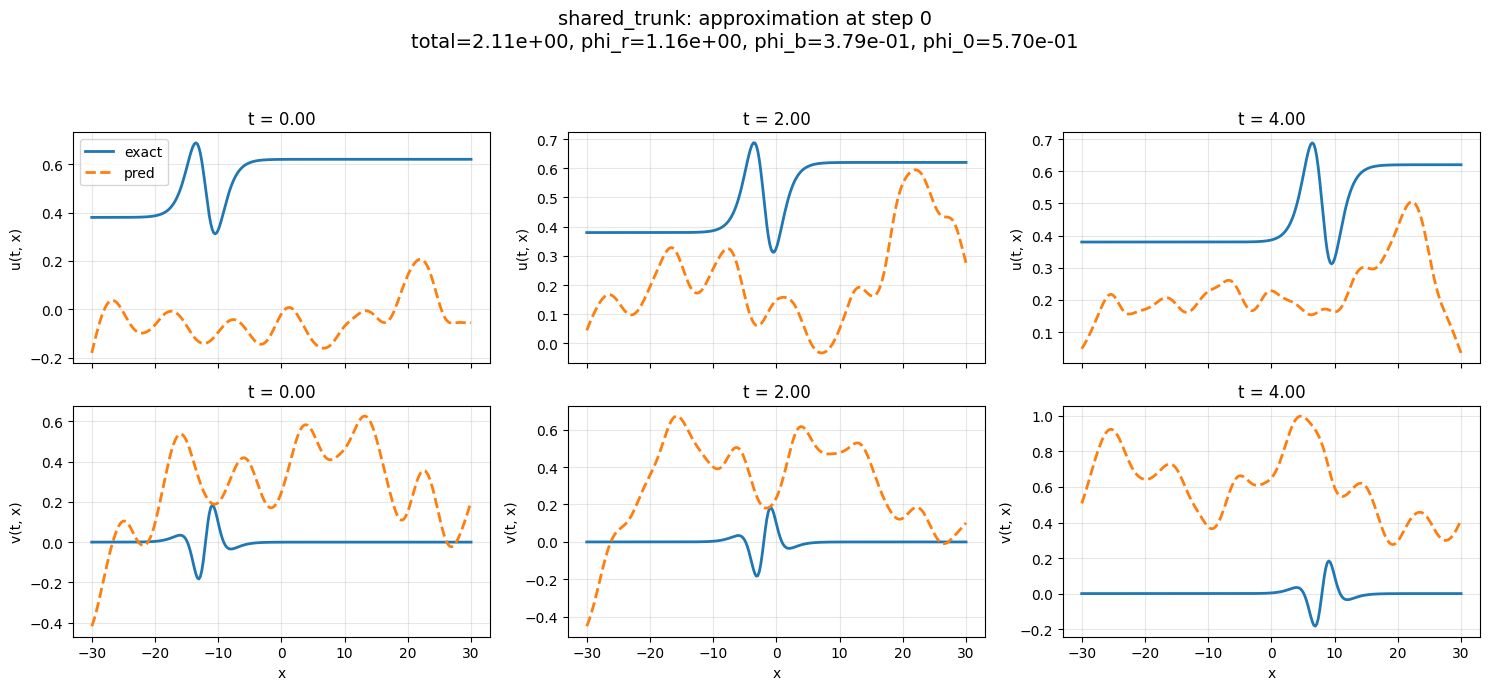

[shared_trunk] step=00100 total=4.013658e-02 (~5.0 residual epochs)
[shared_trunk] step=00200 total=1.937802e-02 (~10.1 residual epochs)
[shared_trunk] step=00300 total=1.206671e-02 (~15.1 residual epochs)
[shared_trunk] step=00400 total=9.244700e-03 (~20.1 residual epochs)
[shared_trunk] step=00500 total=7.776104e-03 (~25.1 residual epochs)
[shared_trunk] step=00600 total=6.756887e-03 (~30.1 residual epochs)
[shared_trunk] step=00700 total=6.137222e-03 (~35.0 residual epochs)
[shared_trunk] step=00800 total=5.588640e-03 (~40.0 residual epochs)
[shared_trunk] step=00900 total=5.328959e-03 (~45.0 residual epochs)
[shared_trunk] step=01000 total=4.947392e-03 (~50.0 residual epochs)


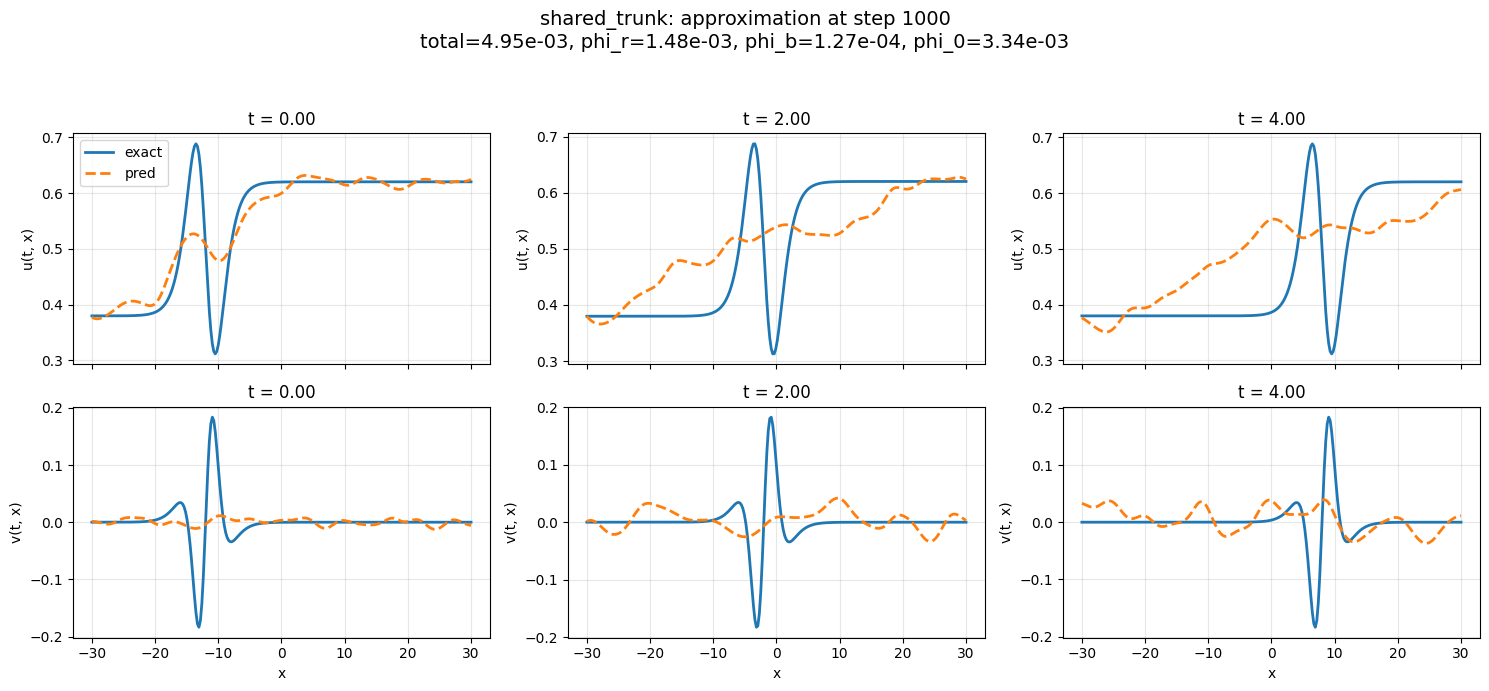

[shared_trunk] step=01100 total=4.686703e-03 (~55.0 residual epochs)
[shared_trunk] step=01200 total=4.521531e-03 (~60.0 residual epochs)
[shared_trunk] step=01300 total=4.357155e-03 (~65.0 residual epochs)
[shared_trunk] step=01400 total=4.130436e-03 (~70.0 residual epochs)
[shared_trunk] step=01500 total=4.033790e-03 (~75.0 residual epochs)
[shared_trunk] step=01600 total=3.959159e-03 (~80.0 residual epochs)
[shared_trunk] step=01700 total=3.839405e-03 (~85.0 residual epochs)
[shared_trunk] step=01800 total=3.718178e-03 (~90.0 residual epochs)
[shared_trunk] step=01900 total=3.557453e-03 (~95.0 residual epochs)
[shared_trunk] step=02000 total=3.495699e-03 (~100.0 residual epochs)


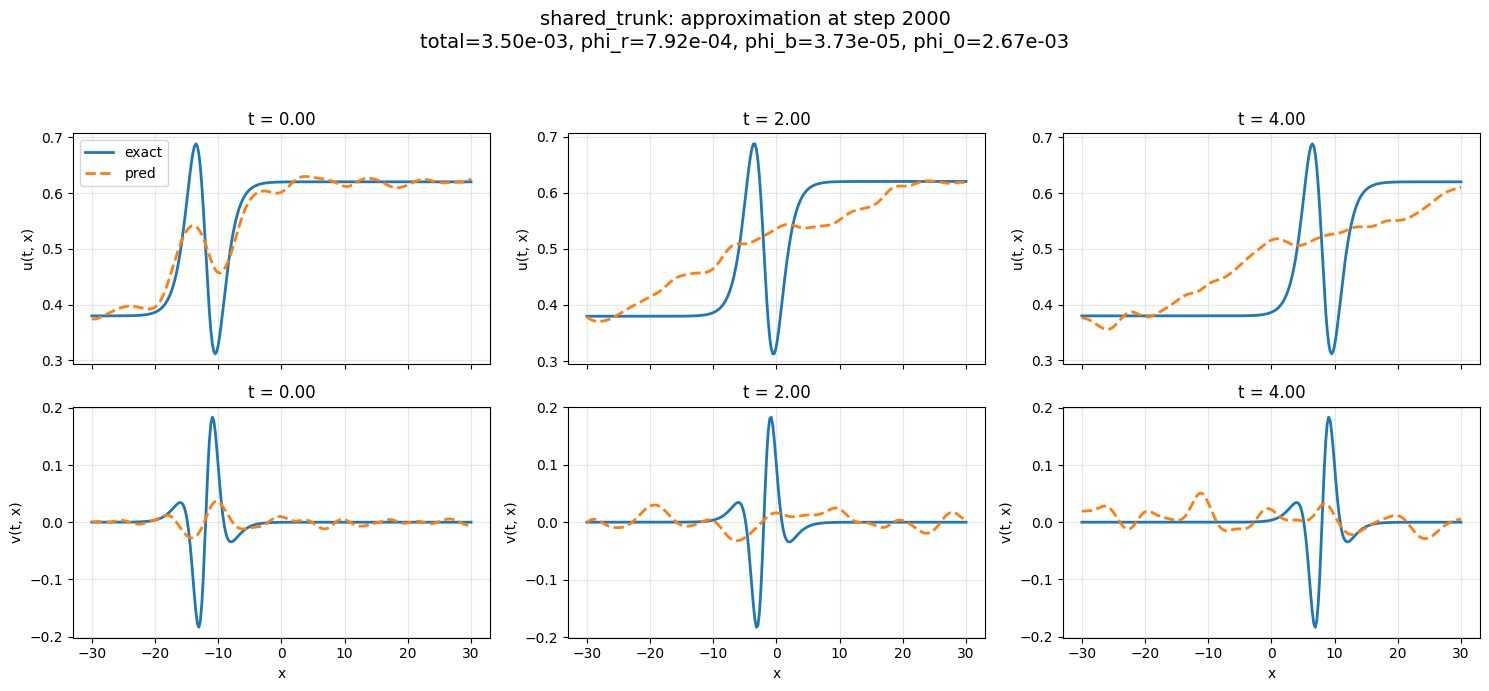

[shared_trunk] step=02100 total=3.361135e-03 (~105.0 residual epochs)
[shared_trunk] step=02200 total=3.275811e-03 (~110.0 residual epochs)
[shared_trunk] step=02300 total=3.199174e-03 (~115.0 residual epochs)
[shared_trunk] step=02400 total=3.123276e-03 (~120.0 residual epochs)
[shared_trunk] step=02500 total=3.031050e-03 (~125.0 residual epochs)
[shared_trunk] step=02600 total=2.919059e-03 (~130.1 residual epochs)
[shared_trunk] step=02700 total=2.735249e-03 (~135.1 residual epochs)
[shared_trunk] step=02800 total=2.796161e-03 (~140.1 residual epochs)
[shared_trunk] step=02900 total=2.578339e-03 (~145.1 residual epochs)
[shared_trunk] step=03000 total=2.461819e-03 (~150.1 residual epochs)


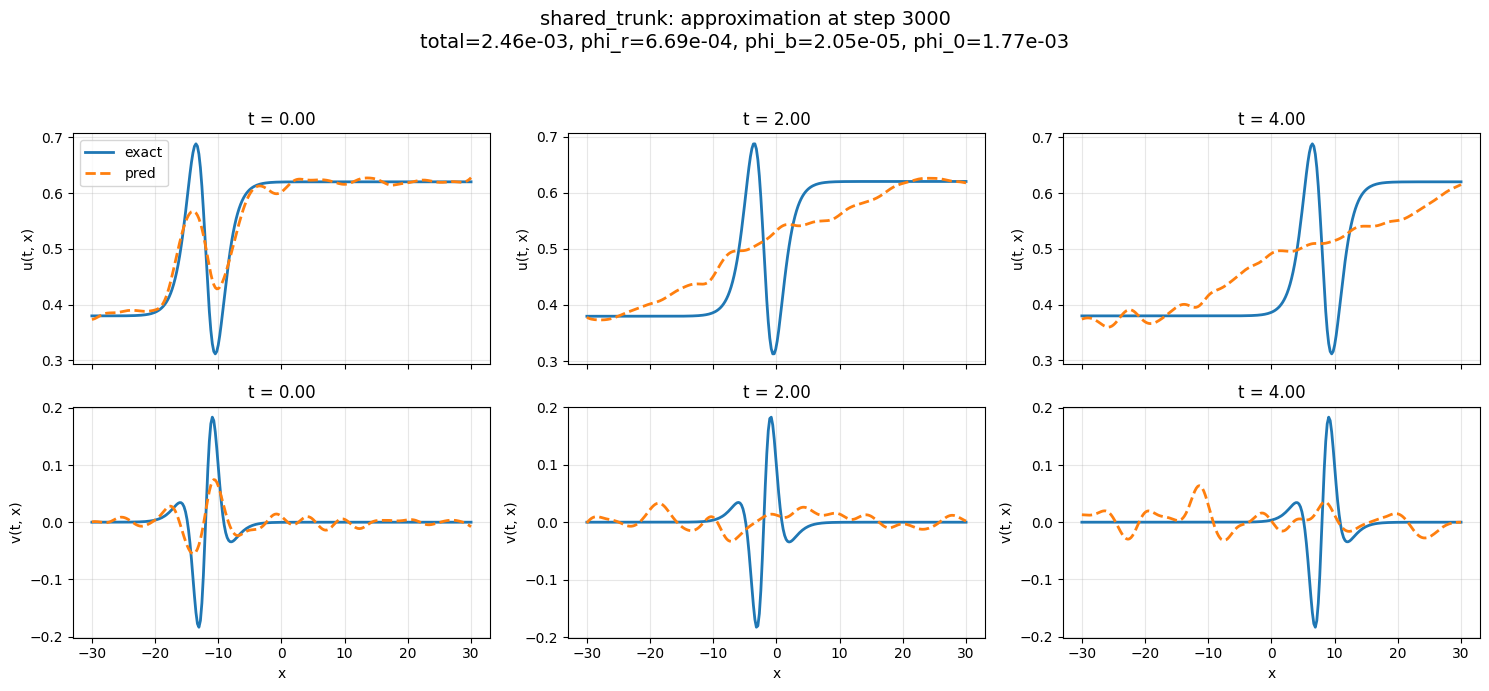

[shared_trunk] step=03100 total=2.392772e-03 (~155.1 residual epochs)
[shared_trunk] step=03200 total=2.188867e-03 (~160.1 residual epochs)
[shared_trunk] step=03300 total=2.074398e-03 (~165.1 residual epochs)
[shared_trunk] step=03400 total=2.130980e-03 (~170.1 residual epochs)
[shared_trunk] step=03500 total=1.994289e-03 (~175.1 residual epochs)
[shared_trunk] step=03600 total=1.816583e-03 (~180.1 residual epochs)
[shared_trunk] step=03700 total=1.712813e-03 (~185.1 residual epochs)
[shared_trunk] step=03800 total=1.617155e-03 (~190.1 residual epochs)
[shared_trunk] step=03900 total=1.486013e-03 (~195.1 residual epochs)
[shared_trunk] step=04000 total=1.411954e-03 (~200.1 residual epochs)


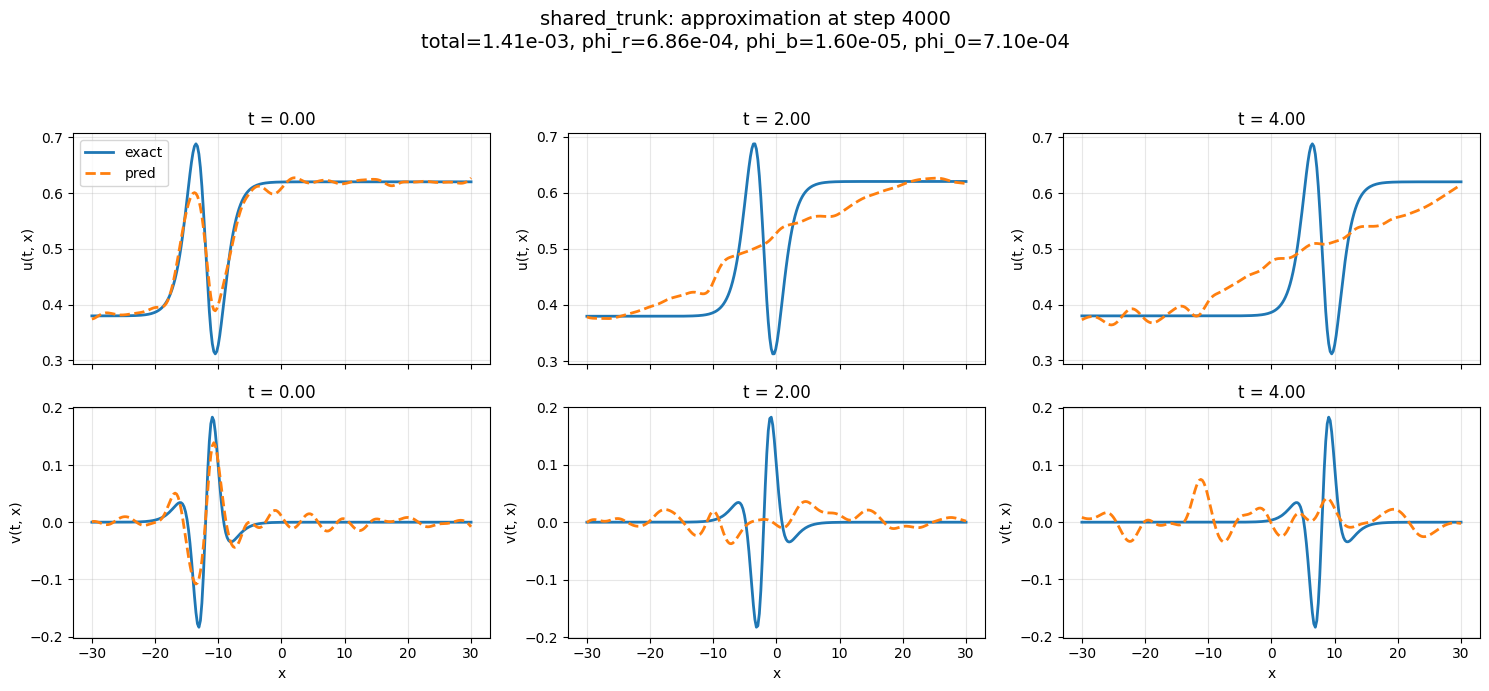

[shared_trunk] step=04100 total=1.389734e-03 (~205.1 residual epochs)
[shared_trunk] step=04200 total=1.353864e-03 (~210.1 residual epochs)
[shared_trunk] step=04300 total=1.212945e-03 (~215.1 residual epochs)
[shared_trunk] step=04400 total=1.232051e-03 (~220.1 residual epochs)
[shared_trunk] step=04500 total=1.100168e-03 (~225.1 residual epochs)
[shared_trunk] step=04600 total=9.915455e-04 (~230.1 residual epochs)
[shared_trunk] step=04700 total=9.458640e-04 (~235.1 residual epochs)
[shared_trunk] step=04800 total=8.677781e-04 (~240.1 residual epochs)
[shared_trunk] step=04900 total=9.677056e-04 (~245.1 residual epochs)
[shared_trunk] step=05000 total=8.963472e-04 (~250.1 residual epochs)


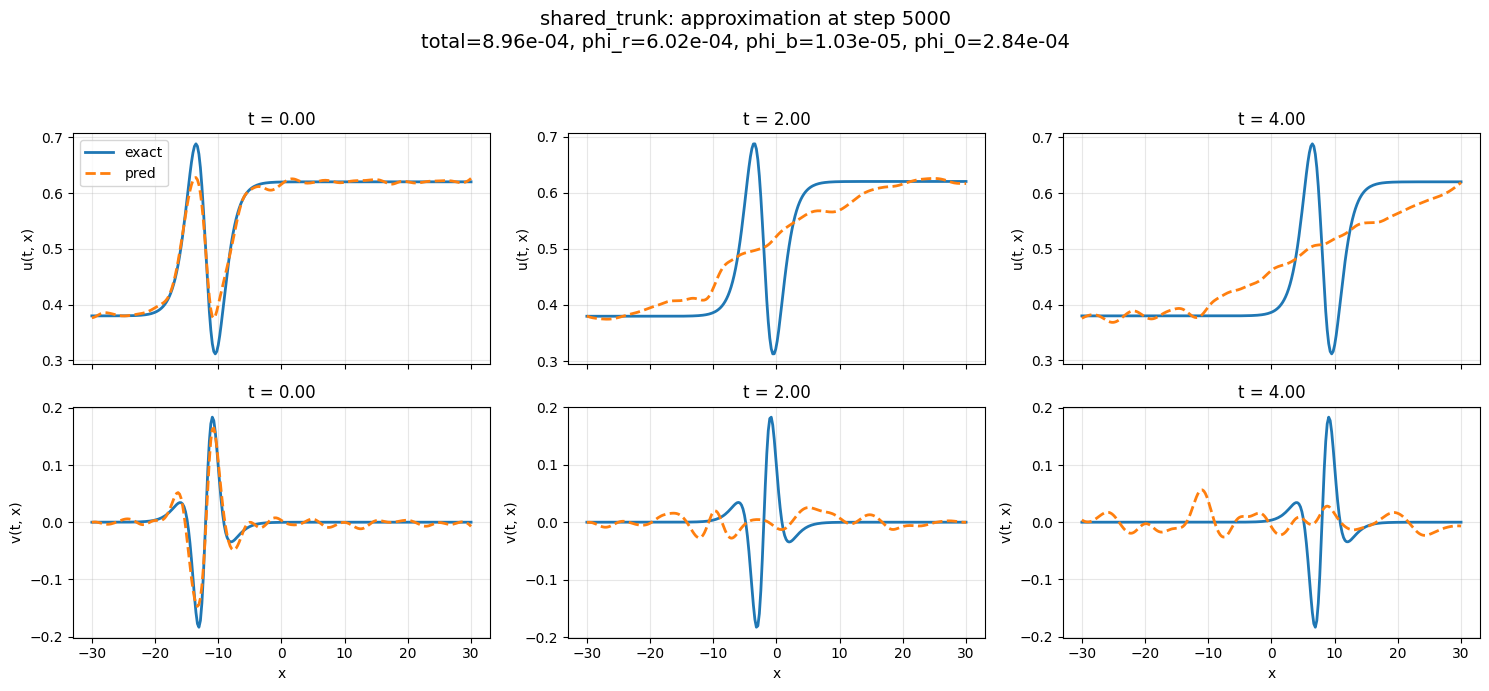

[shared_trunk] step=05100 total=9.219765e-04 (~255.1 residual epochs)
[shared_trunk] step=05200 total=7.521539e-04 (~260.1 residual epochs)
[shared_trunk] step=05300 total=8.235680e-04 (~265.1 residual epochs)
[shared_trunk] step=05400 total=6.794499e-04 (~270.1 residual epochs)
[shared_trunk] step=05500 total=6.752908e-04 (~275.1 residual epochs)
[shared_trunk] step=05600 total=7.458301e-04 (~280.1 residual epochs)
[shared_trunk] step=05700 total=6.452245e-04 (~285.1 residual epochs)
[shared_trunk] step=05800 total=7.049951e-04 (~290.1 residual epochs)
[shared_trunk] step=05900 total=7.237373e-04 (~295.1 residual epochs)
[shared_trunk] step=06000 total=5.423602e-04 (~300.1 residual epochs)


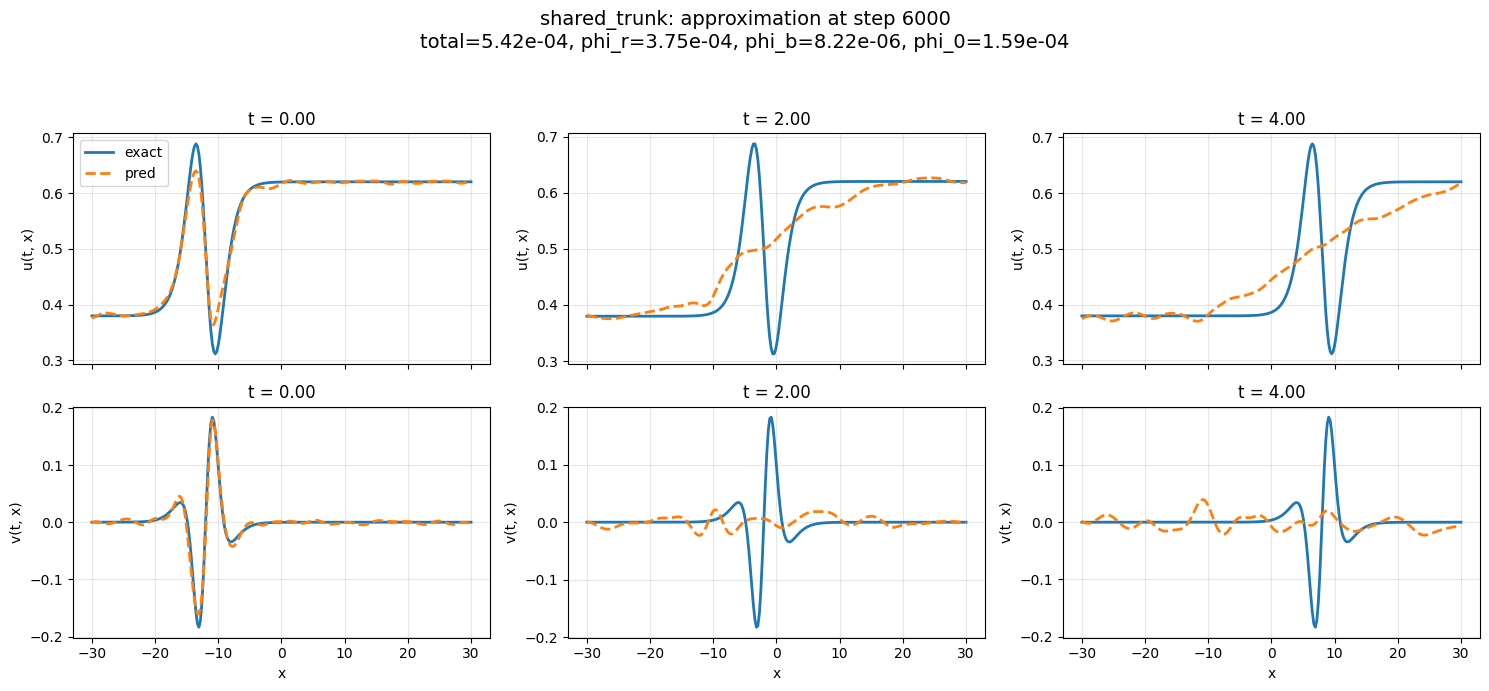

[shared_trunk] step=06100 total=7.215202e-04 (~305.1 residual epochs)
[shared_trunk] step=06200 total=5.375096e-04 (~310.1 residual epochs)
[shared_trunk] step=06300 total=5.186601e-04 (~315.1 residual epochs)
[shared_trunk] step=06400 total=5.086956e-04 (~320.1 residual epochs)
[shared_trunk] step=06500 total=5.168603e-04 (~325.1 residual epochs)
[shared_trunk] step=06600 total=5.660650e-04 (~330.1 residual epochs)
[shared_trunk] step=06700 total=4.854954e-04 (~335.1 residual epochs)
[shared_trunk] step=06800 total=5.276097e-04 (~340.1 residual epochs)
[shared_trunk] step=06900 total=4.991853e-04 (~345.1 residual epochs)
[shared_trunk] step=07000 total=4.291366e-04 (~350.1 residual epochs)


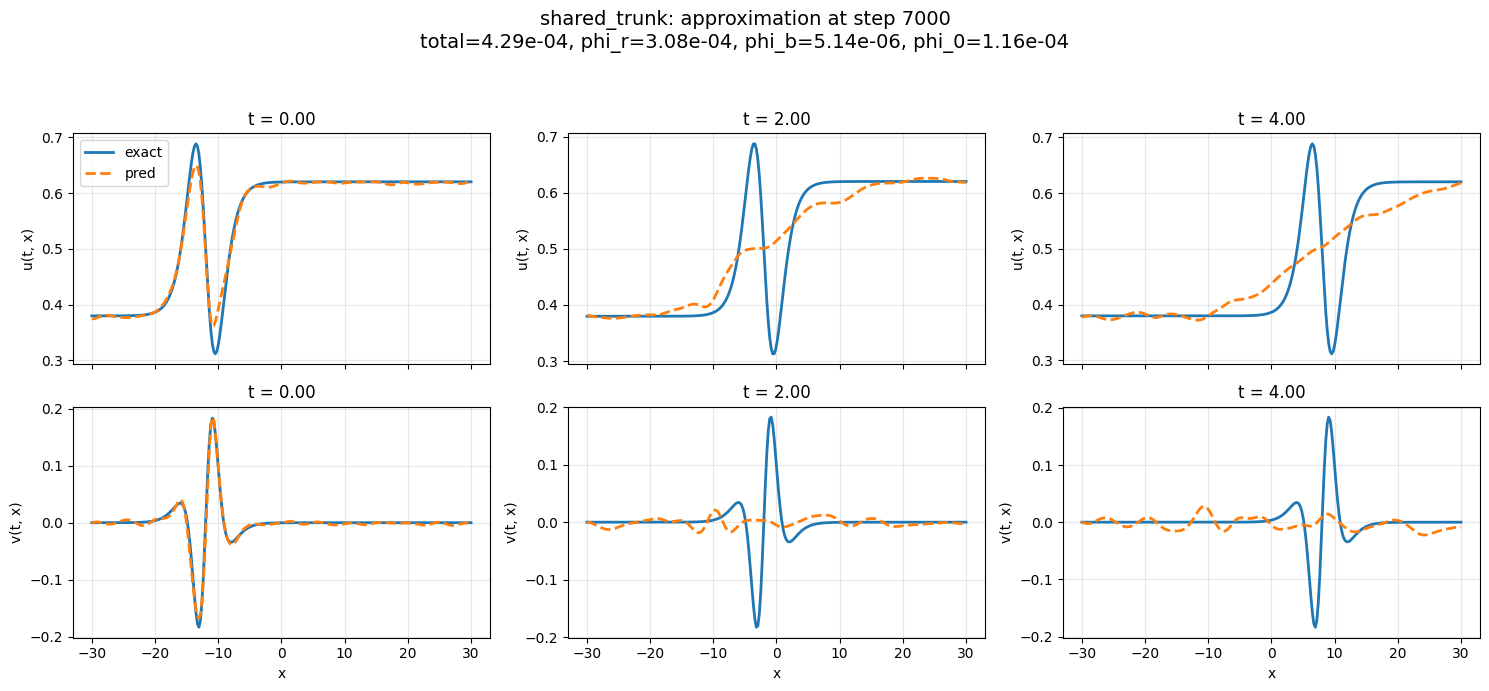

[shared_trunk] step=07100 total=4.948215e-04 (~355.1 residual epochs)
[shared_trunk] step=07200 total=4.719996e-04 (~360.1 residual epochs)
[shared_trunk] step=07300 total=4.528537e-04 (~365.1 residual epochs)
[shared_trunk] step=07400 total=4.257067e-04 (~370.1 residual epochs)
[shared_trunk] step=07500 total=4.016759e-04 (~375.1 residual epochs)
[shared_trunk] step=07600 total=4.914997e-04 (~380.1 residual epochs)
[shared_trunk] step=07700 total=3.858590e-04 (~385.1 residual epochs)
[shared_trunk] step=07800 total=3.668985e-04 (~390.1 residual epochs)
[shared_trunk] step=07900 total=4.172714e-04 (~395.1 residual epochs)
[shared_trunk] step=08000 total=4.046081e-04 (~400.1 residual epochs)


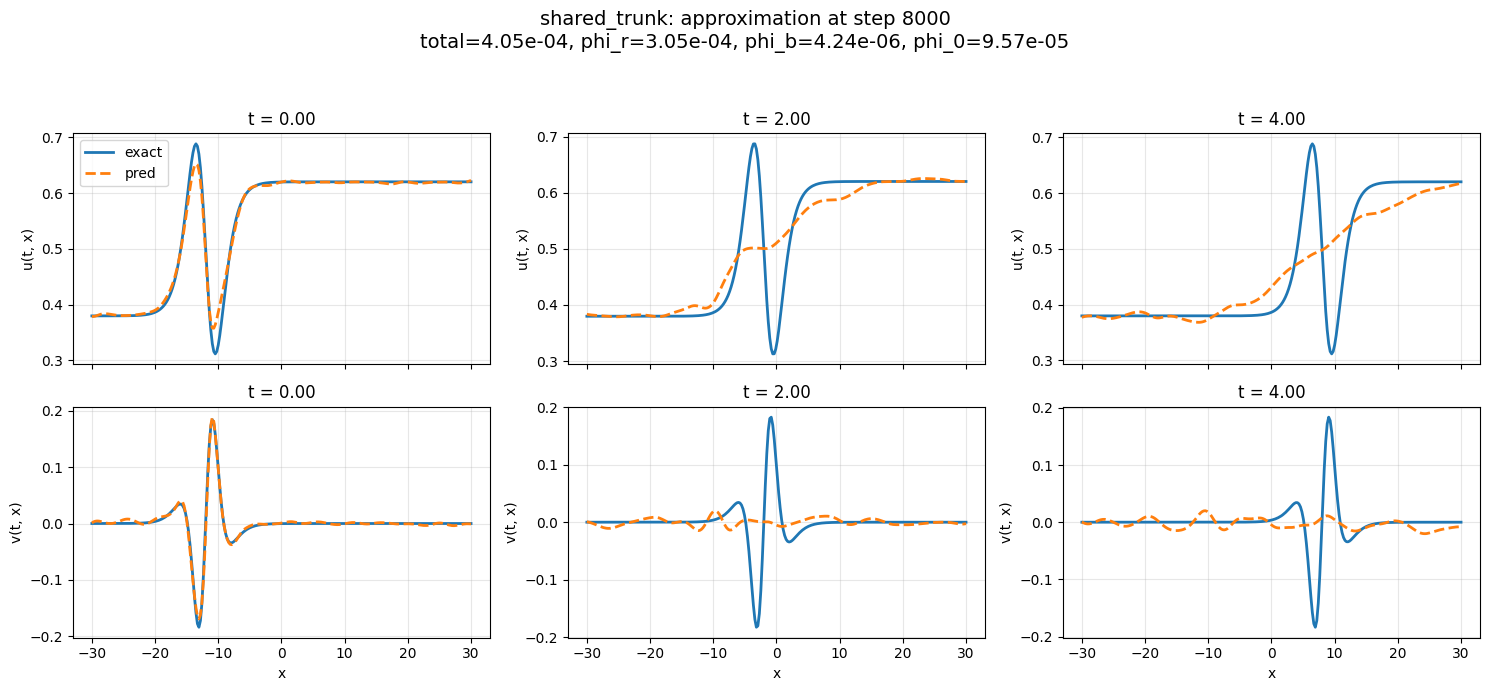

[shared_trunk] step=08100 total=3.696749e-04 (~405.1 residual epochs)
[shared_trunk] step=08200 total=3.741048e-04 (~410.1 residual epochs)
[shared_trunk] step=08300 total=4.101803e-04 (~415.1 residual epochs)
[shared_trunk] step=08400 total=4.410832e-04 (~420.1 residual epochs)
[shared_trunk] step=08500 total=3.951367e-04 (~425.1 residual epochs)
[shared_trunk] step=08600 total=3.727476e-04 (~430.1 residual epochs)
[shared_trunk] step=08700 total=3.687832e-04 (~435.1 residual epochs)
[shared_trunk] step=08800 total=4.188668e-04 (~440.1 residual epochs)
[shared_trunk] step=08900 total=3.958184e-04 (~445.1 residual epochs)
[shared_trunk] step=09000 total=4.017518e-04 (~450.1 residual epochs)


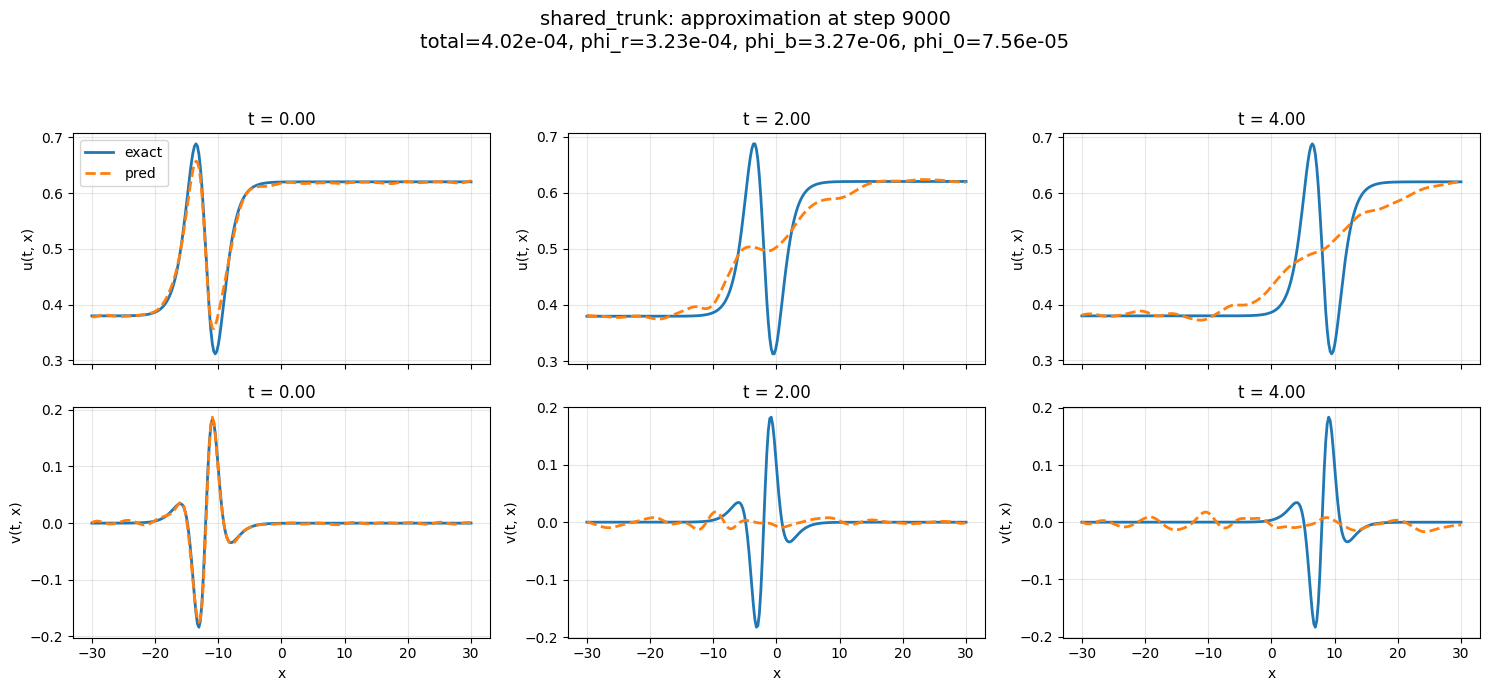

[shared_trunk] step=09100 total=4.309411e-04 (~455.1 residual epochs)
[shared_trunk] step=09200 total=3.209685e-04 (~460.1 residual epochs)
[shared_trunk] step=09300 total=3.731509e-04 (~465.1 residual epochs)
[shared_trunk] step=09400 total=4.279194e-04 (~470.1 residual epochs)
[shared_trunk] step=09500 total=3.501663e-04 (~475.1 residual epochs)
[shared_trunk] step=09600 total=3.721227e-04 (~480.1 residual epochs)
[shared_trunk] step=09700 total=3.425078e-04 (~485.1 residual epochs)
[shared_trunk] step=09800 total=4.516366e-04 (~490.1 residual epochs)
[shared_trunk] step=09900 total=3.660107e-04 (~495.1 residual epochs)
[shared_trunk] step=10000 total=3.184335e-04 (~500.1 residual epochs)


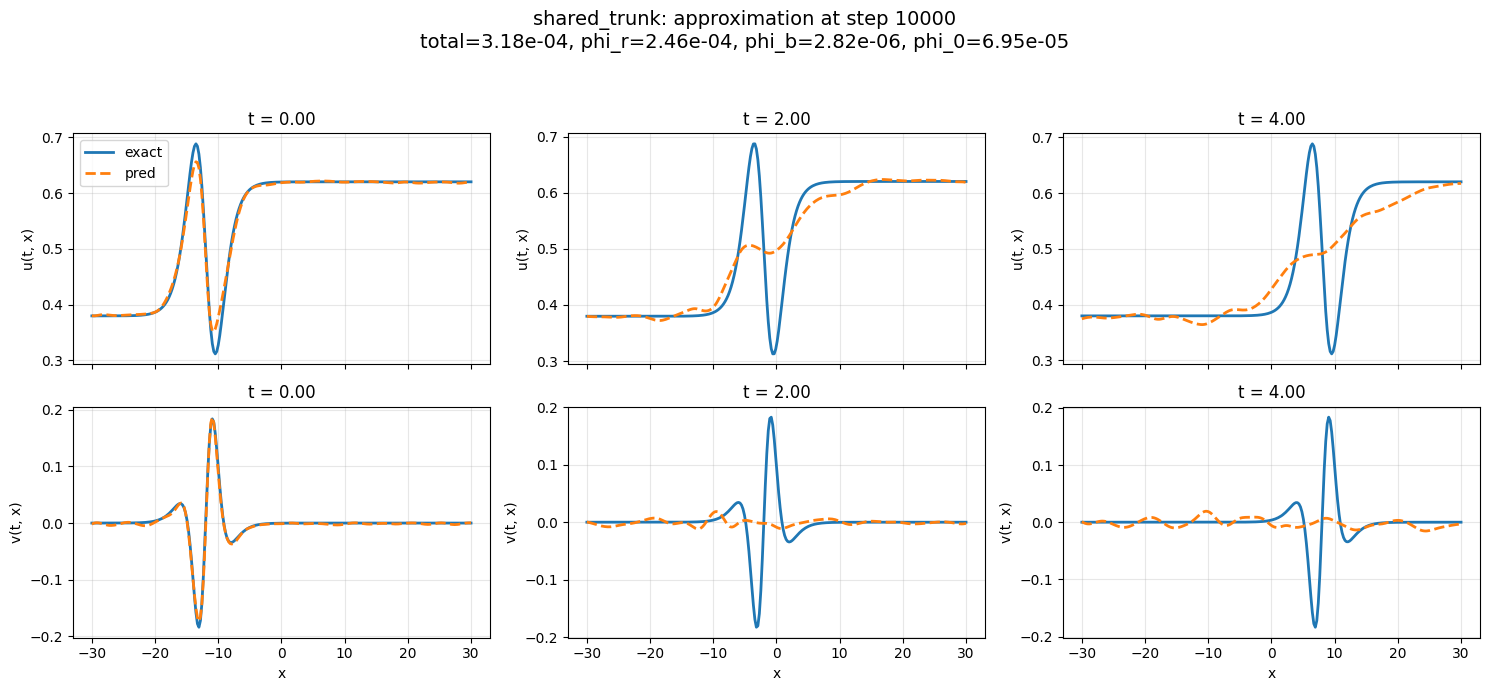

[shared_trunk] step=10100 total=3.060675e-04 (~505.1 residual epochs)
[shared_trunk] step=10200 total=3.337990e-04 (~510.1 residual epochs)
[shared_trunk] step=10300 total=3.623969e-04 (~515.0 residual epochs)
[shared_trunk] step=10400 total=2.748381e-04 (~520.0 residual epochs)
[shared_trunk] step=10500 total=3.791531e-04 (~525.0 residual epochs)
[shared_trunk] step=10600 total=3.235319e-04 (~530.0 residual epochs)
[shared_trunk] step=10700 total=3.318935e-04 (~535.0 residual epochs)
[shared_trunk] step=10800 total=3.125853e-04 (~540.0 residual epochs)
[shared_trunk] step=10900 total=3.782672e-04 (~545.0 residual epochs)
[shared_trunk] step=11000 total=3.380702e-04 (~550.0 residual epochs)


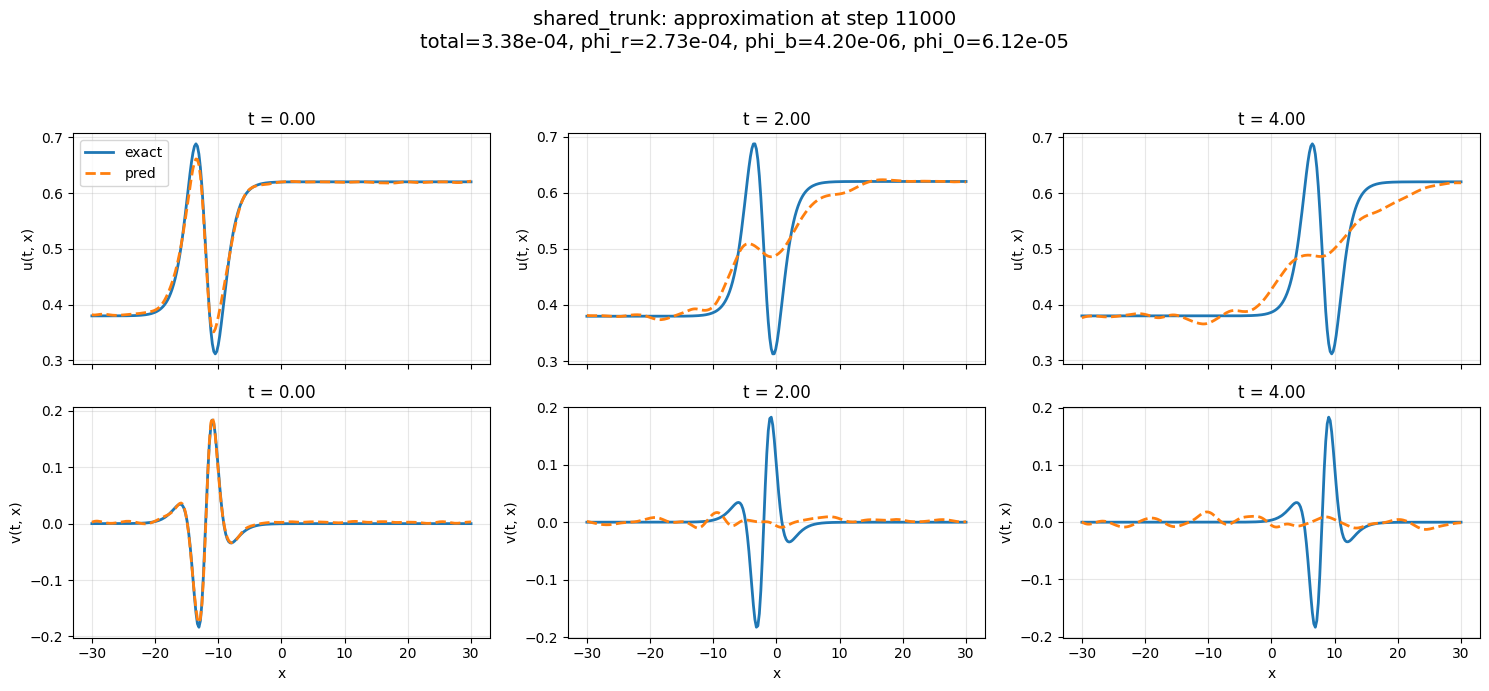

[shared_trunk] step=11100 total=4.129259e-04 (~555.0 residual epochs)
[shared_trunk] step=11200 total=3.330316e-04 (~560.0 residual epochs)
[shared_trunk] step=11300 total=3.956802e-04 (~565.0 residual epochs)
[shared_trunk] step=11400 total=2.475202e-04 (~570.0 residual epochs)
[shared_trunk] step=11500 total=3.640341e-04 (~575.0 residual epochs)
[shared_trunk] step=11600 total=3.033442e-04 (~580.0 residual epochs)
[shared_trunk] step=11700 total=2.663500e-04 (~585.0 residual epochs)
[shared_trunk] step=11800 total=2.538268e-04 (~590.0 residual epochs)
[shared_trunk] step=11900 total=3.210530e-04 (~595.0 residual epochs)
[shared_trunk] step=12000 total=3.059632e-04 (~600.0 residual epochs)


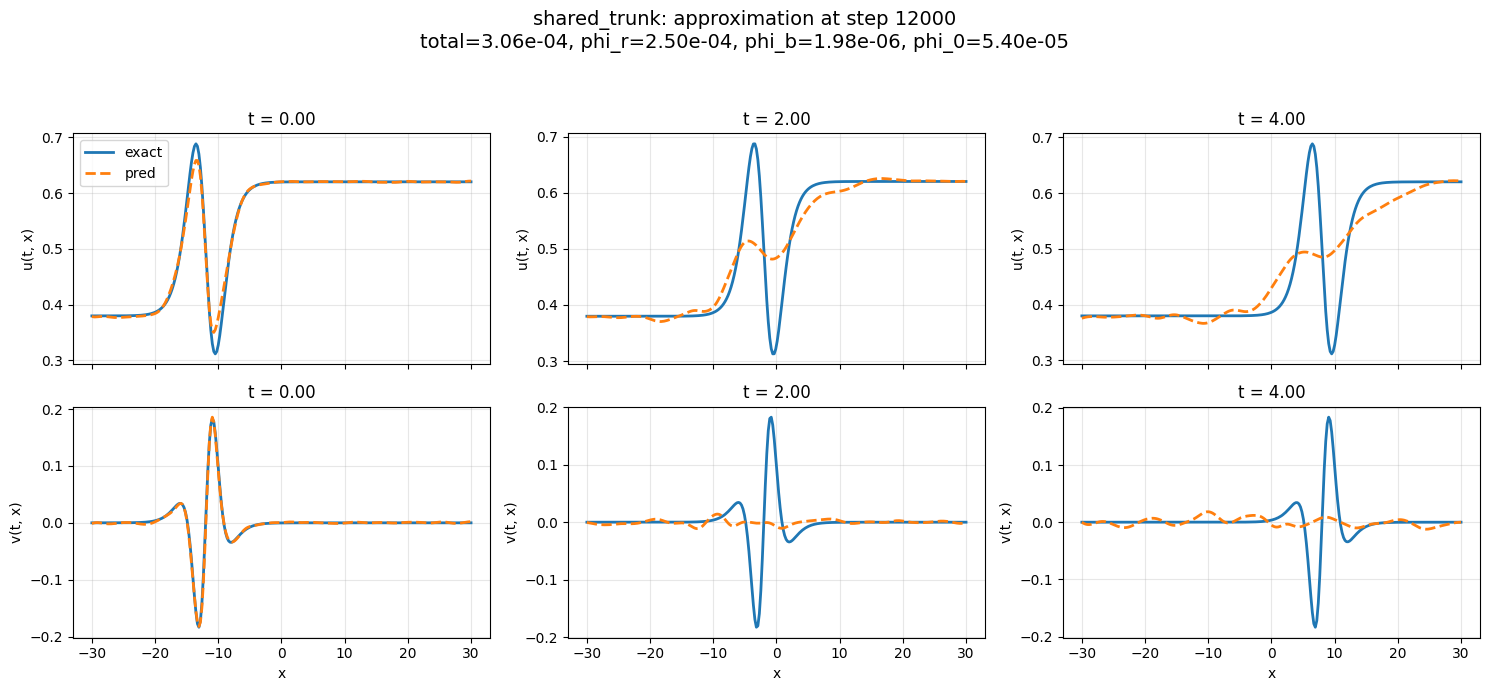

[shared_trunk] step=12100 total=3.124310e-04 (~605.0 residual epochs)
[shared_trunk] step=12200 total=3.334268e-04 (~610.0 residual epochs)
[shared_trunk] step=12300 total=2.516024e-04 (~615.0 residual epochs)
[shared_trunk] step=12400 total=3.049773e-04 (~620.0 residual epochs)
[shared_trunk] step=12500 total=2.621809e-04 (~625.0 residual epochs)
[shared_trunk] step=12600 total=3.641386e-04 (~630.0 residual epochs)
[shared_trunk] step=12700 total=2.915608e-04 (~635.0 residual epochs)
[shared_trunk] step=12800 total=2.808491e-04 (~640.0 residual epochs)
[shared_trunk] step=12900 total=3.185623e-04 (~645.0 residual epochs)
[shared_trunk] step=13000 total=2.951041e-04 (~650.0 residual epochs)


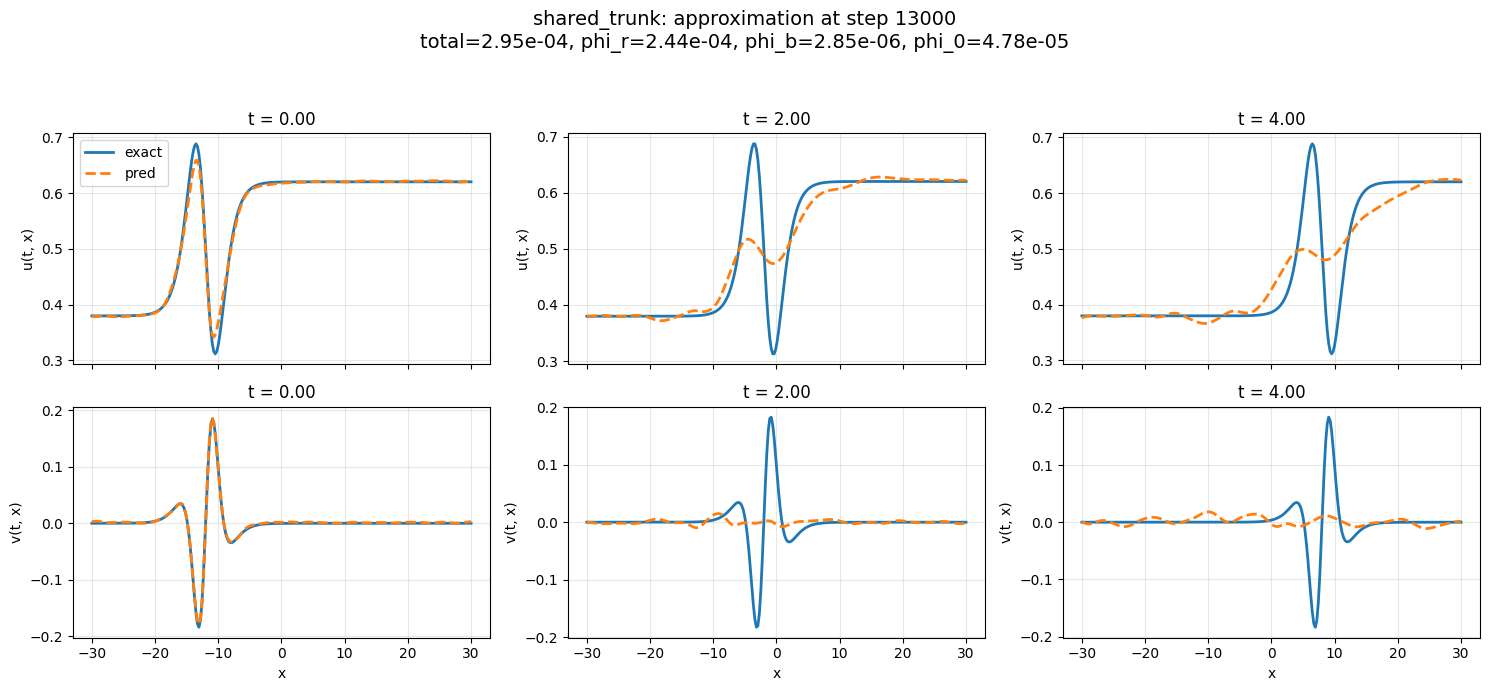

[shared_trunk] elapsed: 118.25 sec


In [17]:
with tf.device(TRAINING_DEVICE):
    history_two_output = run_training(
        two_output_model,
        two_output_optim,
        'two_output',
        X_r,
        X_0,
        u_0,
        v_0,
        X_lb,
        u_lb,
        v_lb,
        X_ub,
        u_ub,
        v_ub,
        num_steps=NUM_STEPS,
        print_every=PRINT_EVERY,
        plot_every=PLOT_EVERY,
    )
    history_two_models = run_training(
        two_models,
        two_models_optim,
        'two_models',
        X_r,
        X_0,
        u_0,
        v_0,
        X_lb,
        u_lb,
        v_lb,
        X_ub,
        u_ub,
        v_ub,
        num_steps=NUM_STEPS,
        print_every=PRINT_EVERY,
        plot_every=PLOT_EVERY,
    )
    history_shared_trunk = run_training(
        shared_trunk_model,
        shared_trunk_optim,
        'shared_trunk',
        X_r,
        X_0,
        u_0,
        v_0,
        X_lb,
        u_lb,
        v_lb,
        X_ub,
        u_ub,
        v_ub,
        num_steps=NUM_STEPS,
        print_every=PRINT_EVERY,
        plot_every=PLOT_EVERY,
    )


## 15. Сравнение графиков потерь

In [18]:
def load_history_from_notebook(nb_path='start.ipynb'):
    nb_path = Path(nb_path)
    with nb_path.open('r', encoding='utf-8') as f:
        nb = json.load(f)

    pattern = re.compile(
        r"It\s+(\d+):\s+total=([0-9.eE+-]+),\s+phi_r=([0-9.eE+-]+),\s+phi_b=([0-9.eE+-]+),\s+phi_0=([0-9.eE+-]+)"
    )

    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
    }

    for cell in nb.get('cells', []):
        for output in cell.get('outputs', []):
            if output.get('output_type') != 'stream':
                continue

            text = output.get('text', '')
            if isinstance(text, list):
                text = ''.join(text)

            for match in pattern.finditer(text):
                history['step'].append(int(match.group(1)))
                history['total'].append(float(match.group(2)))
                history['phi_r'].append(float(match.group(3)))
                history['phi_b'].append(float(match.group(4)))
                history['phi_0'].append(float(match.group(5)))

    if not history['step']:
        raise ValueError(f'?? ??????? ??????? history ?? {nb_path}')

    return history


def plot_loss_curves_like_start(history, label):
    steps = np.array(history['step'])
    eps = 1e-12

    plt.figure(figsize=(8, 4))
    plt.semilogy(steps, np.array(history['total']) + eps, lw=1.4, label='total loss')
    plt.xlabel('iterations')
    plt.ylabel('loss (log scale)')
    plt.title(f'{label}: total loss')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.semilogy(steps, np.array(history['phi_r']) + eps, label='L_r (PDE)')
    plt.semilogy(steps, np.array(history['phi_0']) + eps, label='L_0 (IC)')
    plt.semilogy(steps, np.array(history['phi_b']) + eps, label='L_b (exact BC)')
    plt.xlabel('iterations')
    plt.ylabel('loss (log scale)')
    plt.title(f'{label}: loss components')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_histories(histories, stage1_history=None, stage1_label='stage1'):
    plt.figure(figsize=(9, 4))

    if stage1_history is not None:
        plt.semilogy(stage1_history['step'], stage1_history['total'], '--', lw=2, label=stage1_label)

    for label, history in histories.items():
        plt.semilogy(history['step'], history['total'], label=label)

    plt.xlabel('iteration')
    plt.ylabel('total loss')
    plt.title('Сравнение сходимости: этап 1 и три подхода этапа 2')
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_history(history, label):
    total = np.array(history['total'])
    steps = np.array(history['step'])
    best_idx = int(np.argmin(total))

    return {
        'label': label,
        'best_step': int(steps[best_idx]),
        'best_total': float(total[best_idx]),
        'final_total': float(total[-1]),
    }


def print_history_summary(histories, stage1_history=None, stage1_label='stage1'):
    rows = []
    if stage1_history is not None:
        rows.append(summarize_history(stage1_history, stage1_label))

    for label, history in histories.items():
        rows.append(summarize_history(history, label))

    for row in rows:
        print(
            f"{row['label']}: best_step={row['best_step']}, "
            f"best_total={row['best_total']:.6e}, final_total={row['final_total']:.6e}"
        )


# # ?????? ?????????????:
# stage1_history = load_history_from_notebook('start.ipynb')
# plot_histories({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')
# print_history_summary({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')

SAVE_WEIGHT_MATRICES = False
WEIGHT_MATRICES_DIR = Path('saved_weight_matrices')


def ensure_model_is_built(model):
    dummy_X = tf.zeros((1, 2), dtype=tf.dtypes.as_dtype(DTYPE))
    model(dummy_X, training=False)
    return model


def iter_weight_tensors(model, model_label):
    ensure_model_is_built(model)
    for layer in model.layers:
        arrays = layer.get_weights()
        if not arrays:
            continue

        param_names = []
        for idx, weight_var in enumerate(layer.weights[:len(arrays)]):
            param_names.append(weight_var.name.split(':')[0].split('/')[-1])

        for idx, array in enumerate(arrays):
            param_name = param_names[idx] if idx < len(param_names) else f'param_{idx}'
            yield {
                'name': f'{model_label}/{layer.name}/{param_name}',
                'array': np.array(array),
            }


def collect_weight_tensors(model_like, variant_name):
    if variant_name == 'two_models':
        model_map = {
            'model_u': model_like['u'],
            'model_v': model_like['v'],
        }
    else:
        model_map = {variant_name: model_like}

    tensors = []
    for model_label, model in model_map.items():
        tensors.extend(iter_weight_tensors(model, model_label))
    return tensors


def sanitize_weight_name(name):
    return re.sub(r'[^0-9A-Za-z_.-]+', '_', name)


def save_weight_matrices(model_registry, output_dir=WEIGHT_MATRICES_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    manifests = {}

    for variant_name, model_like in model_registry.items():
        variant_dir = output_dir / variant_name
        variant_dir.mkdir(parents=True, exist_ok=True)

        entries = []
        for idx, tensor in enumerate(collect_weight_tensors(model_like, variant_name)):
            file_path = variant_dir / f"{idx:02d}_{sanitize_weight_name(tensor['name'])}.npy"
            np.save(file_path, tensor['array'])
            entries.append({
                'name': tensor['name'],
                'shape': list(tensor['array'].shape),
                'path': str(file_path),
            })

        manifest_path = variant_dir / 'manifest.json'
        with manifest_path.open('w', encoding='utf-8') as fh:
            json.dump(entries, fh, ensure_ascii=False, indent=2)

        manifests[variant_name] = entries
        print(f'[{variant_name}] saved {len(entries)} weight tensors -> {variant_dir}')

    return manifests


def print_saved_weight_matrices(manifests, max_items_per_variant=None):
    old_options = np.get_printoptions()
    np.set_printoptions(precision=6, suppress=True, linewidth=120, threshold=200)
    try:
        for variant_name, entries in manifests.items():
            print(f'\n===== {variant_name} =====')
            visible_entries = entries if max_items_per_variant is None else entries[:max_items_per_variant]
            for entry in visible_entries:
                array = np.load(entry['path'])
                print(f"{entry['name']} shape={tuple(entry['shape'])}")
                print(array)
                print()

            if max_items_per_variant is not None and len(entries) > max_items_per_variant:
                hidden_count = len(entries) - max_items_per_variant
                print(f'... skipped {hidden_count} tensors for {variant_name}')
    finally:
        np.set_printoptions(**old_options)


## 16. Сравнение с этапом 1

По ТЗ нужно сравнить график сходимости этапа 2 с результатами этапа 1.


1. функция `load_history_from_notebook('start.ipynb')` читает сохраненный лог обучения из ноутбука первого этапа;
2. `plot_histories(..., stage1_history=...)` накладывает кривую этапа 1 на графики этапа 2;
3. `print_history_summary(...)` печатает краткую сводку по лучшему и финальному лоссу.

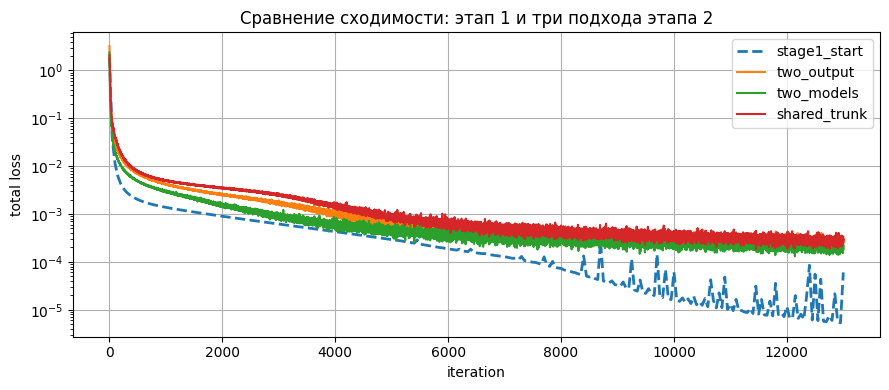

stage1_start: best_step=12950, best_total=5.312287e-06, final_total=6.025649e-05
two_output: best_step=12142, best_total=1.523159e-04, final_total=2.488827e-04
two_models: best_step=12142, best_total=1.306639e-04, final_total=2.134125e-04
shared_trunk: best_step=11454, best_total=1.854581e-04, final_total=2.951041e-04


In [20]:


stage1_history = load_history_from_notebook('start.ipynb')
plot_histories({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')
print_history_summary({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')


## 17. Матрицы весов

Сохраняем матрицы весов каждой обученной модели в `.npy` только если включён флаг `SAVE_WEIGHT_MATRICES`.


In [21]:
required_models = ['two_output_model', 'two_models', 'shared_trunk_model']
missing_models = [name for name in required_models if name not in globals()]
if missing_models:
    raise RuntimeError(f'Run the model initialization/training cells first. Missing: {missing_models}')

trained_models = {
    'two_output': two_output_model,
    'two_models': two_models,
    'shared_trunk': shared_trunk_model,
}

if SAVE_WEIGHT_MATRICES:
    weight_manifests = save_weight_matrices(trained_models)
    print_saved_weight_matrices(weight_manifests)
else:
    print('SAVE_WEIGHT_MATRICES = False, skipping weight export.')


SAVE_WEIGHT_MATRICES = False, skipping weight export.


## 17. ??????????? ?????? ? ???????? ?????????????


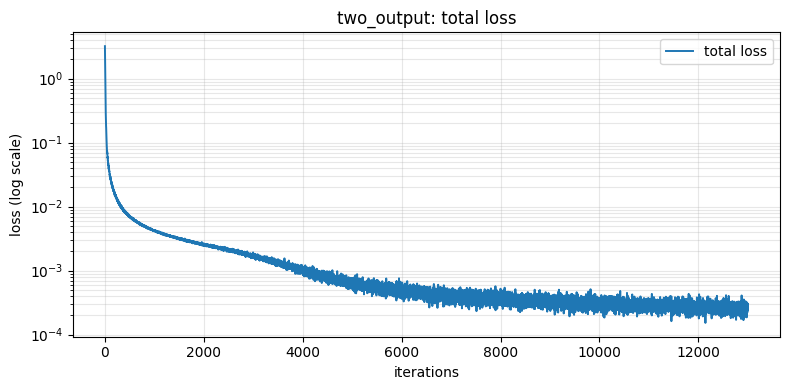

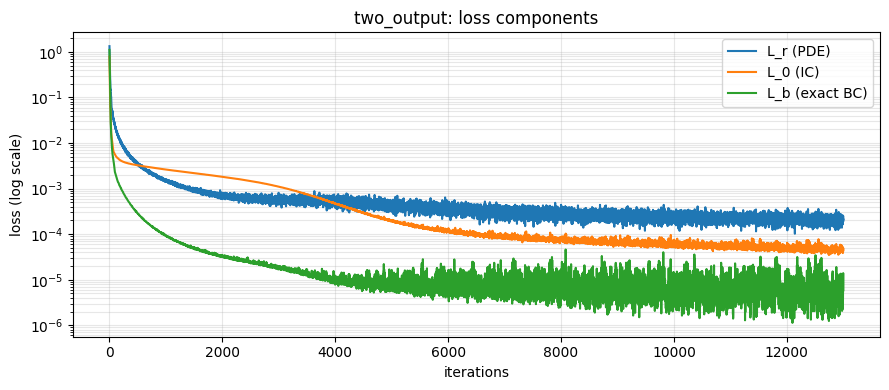

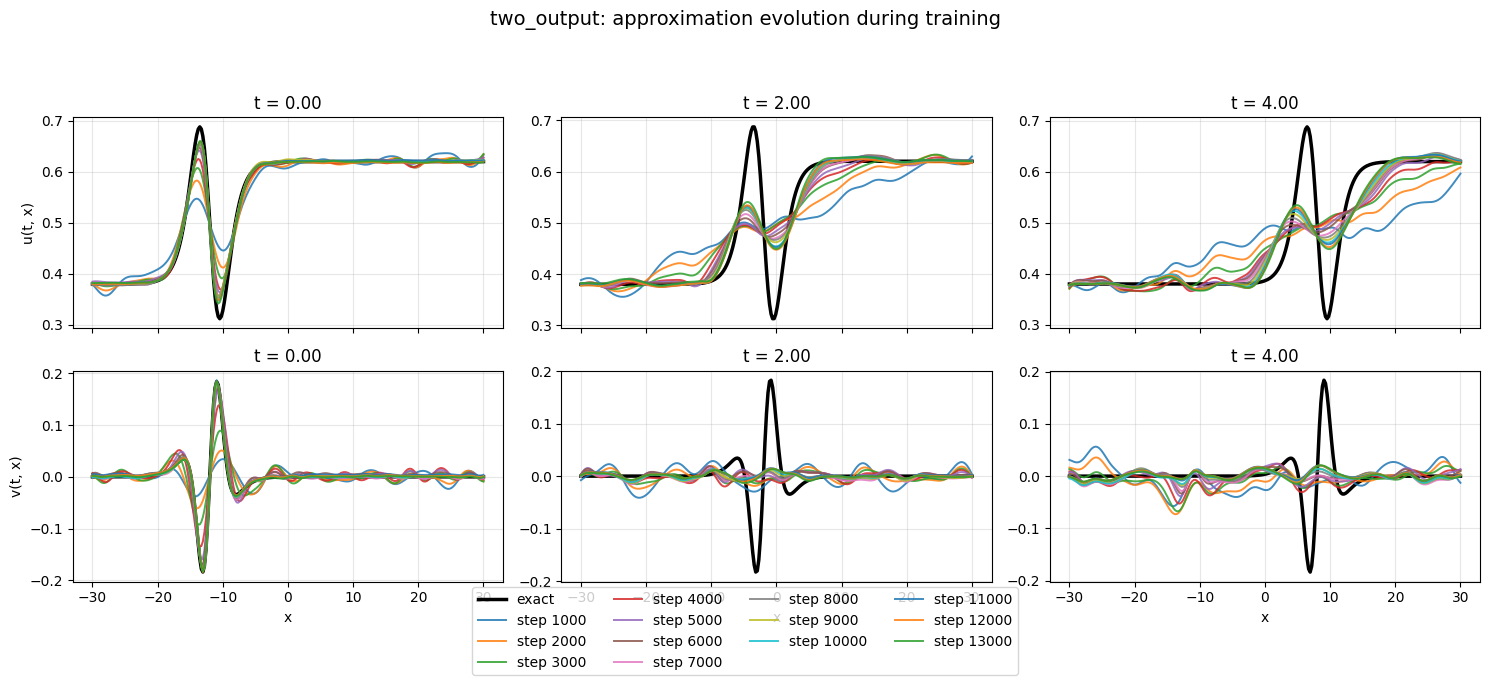

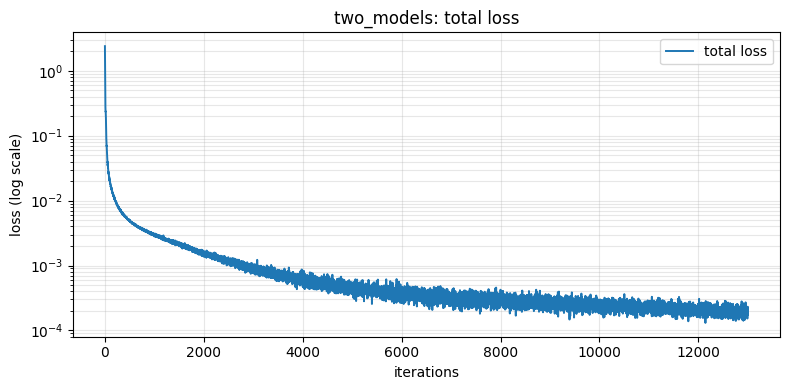

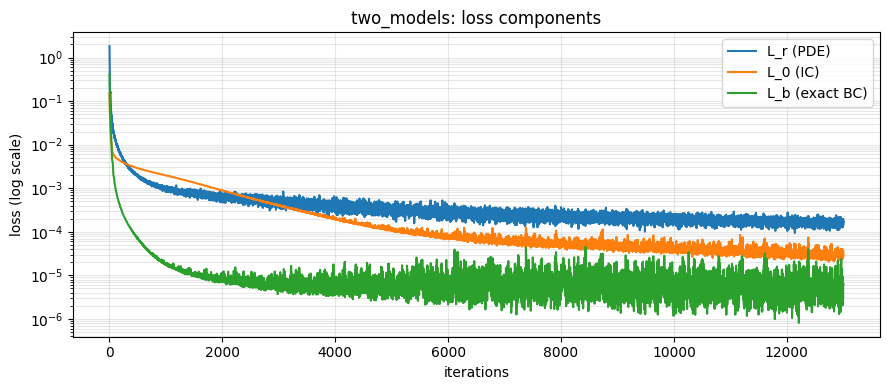

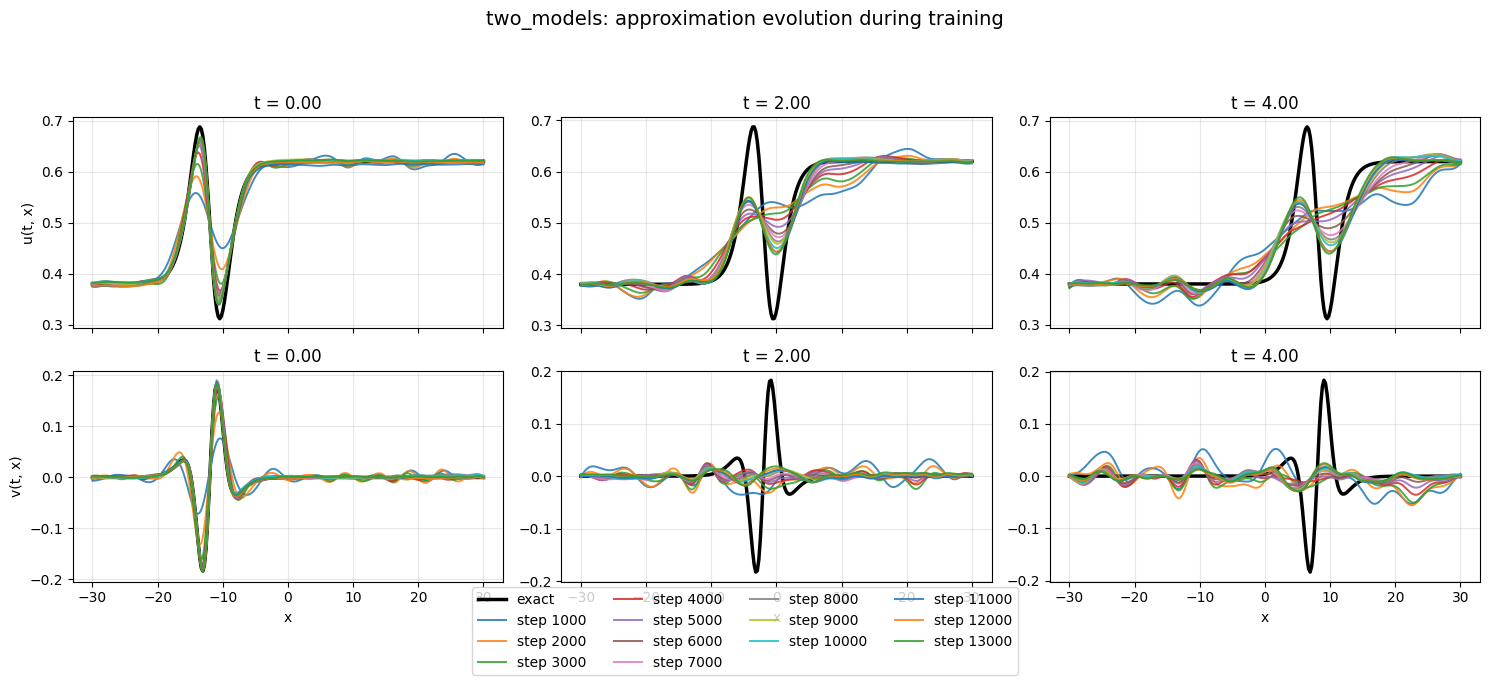

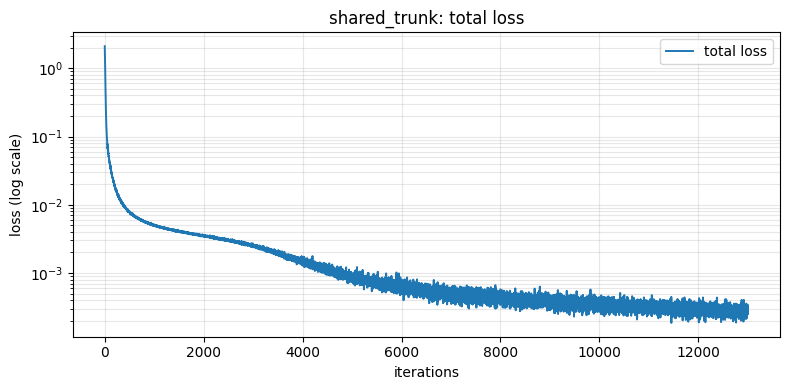

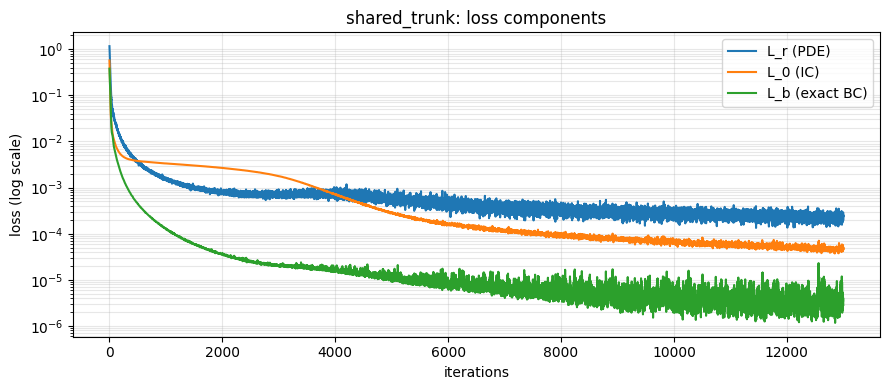

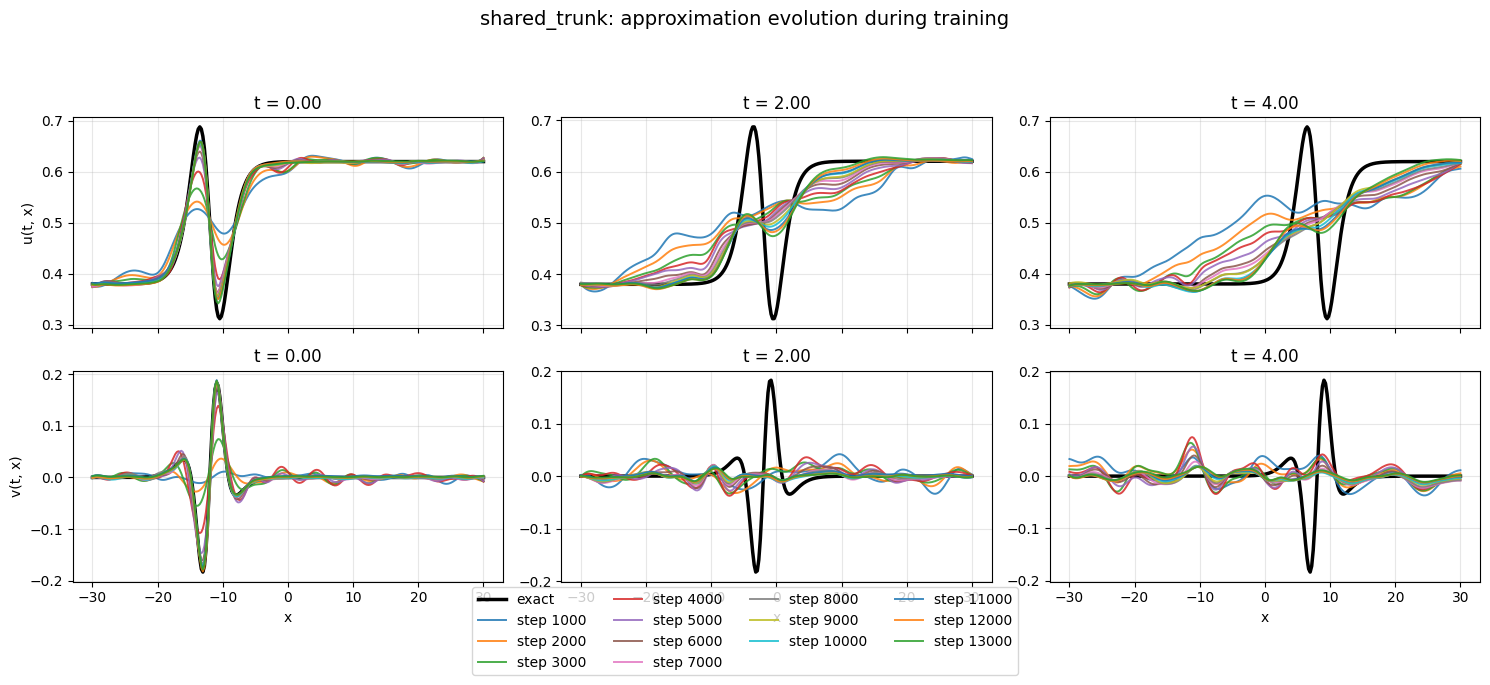

In [22]:
stage_2_histories = {
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}

for variant_name, variant_history in stage_2_histories.items():
    plot_loss_curves_like_start(variant_history, variant_name)
    plot_approximation_evolution(variant_history, variant_name)
